In [59]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold

from opfython.models import SupervisedOPF
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC as SupportVectorMachineClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.inspection import permutation_importance

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import ParameterGrid

from imblearn.under_sampling import NearMiss

from scipy.stats import wilcoxon
import scipy.stats as st

import logging
import warnings

In [60]:
df = pd.read_csv('NPHA-doctor-visits.csv')

In [61]:
df

,Number of Doctors Visited,Age,Phyiscal Health,Mental Health,Dental Health,Employment,Stress Keeps Patient from Sleeping,Medication Keeps Patient from Sleeping,Pain Keeps Patient from Sleeping,Bathroom Needs Keeps Patient from Sleeping,Uknown Keeps Patient from Sleeping,Trouble Sleeping,Prescription Sleep Medication,Race,Gender
0,3,2,4,3,3,3,0,0,0,0,1,2,3,1,2
1,2,2,4,2,3,3,1,0,0,1,0,3,3,1,1
2,3,2,3,2,3,3,0,0,0,0,1,3,3,4,1
3,1,2,3,2,3,3,0,0,0,1,0,3,3,4,2
4,3,2,3,3,3,3,1,0,0,0,0,2,3,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,2,2,2,2,2,3,0,0,0,1,0,3,3,1,1
710,3,2,2,2,2,2,1,0,0,0,1,2,3,1,2
711,3,2,4,2,3,3,0,0,0,0,0,3,3,1,1
712,3,2,3,1,3,3,1,0,1,1,1,3,3,1,2


In [62]:
df.shape

(714, 15)

In [63]:
df.isna().sum()

Number of Doctors Visited                     0
Age                                           0
Phyiscal Health                               0
Mental Health                                 0
Dental Health                                 0
Employment                                    0
Stress Keeps Patient from Sleeping            0
Medication Keeps Patient from Sleeping        0
Pain Keeps Patient from Sleeping              0
Bathroom Needs Keeps Patient from Sleeping    0
Uknown Keeps Patient from Sleeping            0
Trouble Sleeping                              0
Prescription Sleep Medication                 0
Race                                          0
Gender                                        0
dtype: int64

In [64]:
df

,Number of Doctors Visited,Age,Phyiscal Health,Mental Health,Dental Health,Employment,Stress Keeps Patient from Sleeping,Medication Keeps Patient from Sleeping,Pain Keeps Patient from Sleeping,Bathroom Needs Keeps Patient from Sleeping,Uknown Keeps Patient from Sleeping,Trouble Sleeping,Prescription Sleep Medication,Race,Gender
0,3,2,4,3,3,3,0,0,0,0,1,2,3,1,2
1,2,2,4,2,3,3,1,0,0,1,0,3,3,1,1
2,3,2,3,2,3,3,0,0,0,0,1,3,3,4,1
3,1,2,3,2,3,3,0,0,0,1,0,3,3,4,2
4,3,2,3,3,3,3,1,0,0,0,0,2,3,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,2,2,2,2,2,3,0,0,0,1,0,3,3,1,1
710,3,2,2,2,2,2,1,0,0,0,1,2,3,1,2
711,3,2,4,2,3,3,0,0,0,0,0,3,3,1,1
712,3,2,3,1,3,3,1,0,1,1,1,3,3,1,2


In [65]:
#histograma das features

# features = df.select_dtypes(include=['number']).columns

# for feature in features:
#     plt.figure(figsize=(8, 6))
#     sns.histplot(data=df, x=feature, hue='Number of Doctors Visited', kde=False, bins=50, palette="pastel")

#     plt.xlabel(feature)
#     plt.ylabel("Contagem")
#     plt.title(f"Distribuição da feature: {feature}")
#     plt.legend(title="Class")
#     plt.show()

In [66]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 714 entries, 0 to 713
Data columns (total 15 columns):
 #   Column                                      Non-Null Count  Dtype
---  ------                                      --------------  -----
 0   Number of Doctors Visited                   714 non-null    int64
 1   Age                                         714 non-null    int64
 2   Phyiscal Health                             714 non-null    int64
 3   Mental Health                               714 non-null    int64
 4   Dental Health                               714 non-null    int64
 5   Employment                                  714 non-null    int64
 6   Stress Keeps Patient from Sleeping          714 non-null    int64
 7   Medication Keeps Patient from Sleeping      714 non-null    int64
 8   Pain Keeps Patient from Sleeping            714 non-null    int64
 9   Bathroom Needs Keeps Patient from Sleeping  714 non-null    int64
 10  Uknown Keeps Patient from Sleeping          714 n

In [67]:
df.describe()

,Number of Doctors Visited,Age,Phyiscal Health,Mental Health,Dental Health,Employment,Stress Keeps Patient from Sleeping,Medication Keeps Patient from Sleeping,Pain Keeps Patient from Sleeping,Bathroom Needs Keeps Patient from Sleeping,Uknown Keeps Patient from Sleeping,Trouble Sleeping,Prescription Sleep Medication,Race,Gender
count,714.000000,714.0,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.00000
mean,2.112045,2.0,2.794118,1.988796,3.009804,2.806723,0.247899,0.056022,0.218487,0.504202,0.417367,2.407563,2.829132,1.425770,1.55042
std,0.683441,0.0,0.900939,0.939928,1.361117,0.586582,0.432096,0.230126,0.413510,0.500333,0.493470,0.670349,0.546767,1.003896,0.49780
min,1.000000,2.0,-1.000000,-1.000000,-1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,1.000000,1.00000
25%,2.000000,2.0,2.000000,1.000000,2.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,3.000000,1.000000,1.00000
50%,2.000000,2.0,3.000000,2.000000,3.000000,3.000000,0.000000,0.000000,0.000000,1.000000,0.000000,3.000000,3.000000,1.000000,2.00000
75%,3.000000,2.0,3.000000,3.000000,4.000000,3.000000,0.000000,0.000000,0.000000,1.000000,1.000000,3.000000,3.000000,1.000000,2.00000
max,3.000000,2.0,5.000000,5.000000,6.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,3.000000,5.000000,2.00000


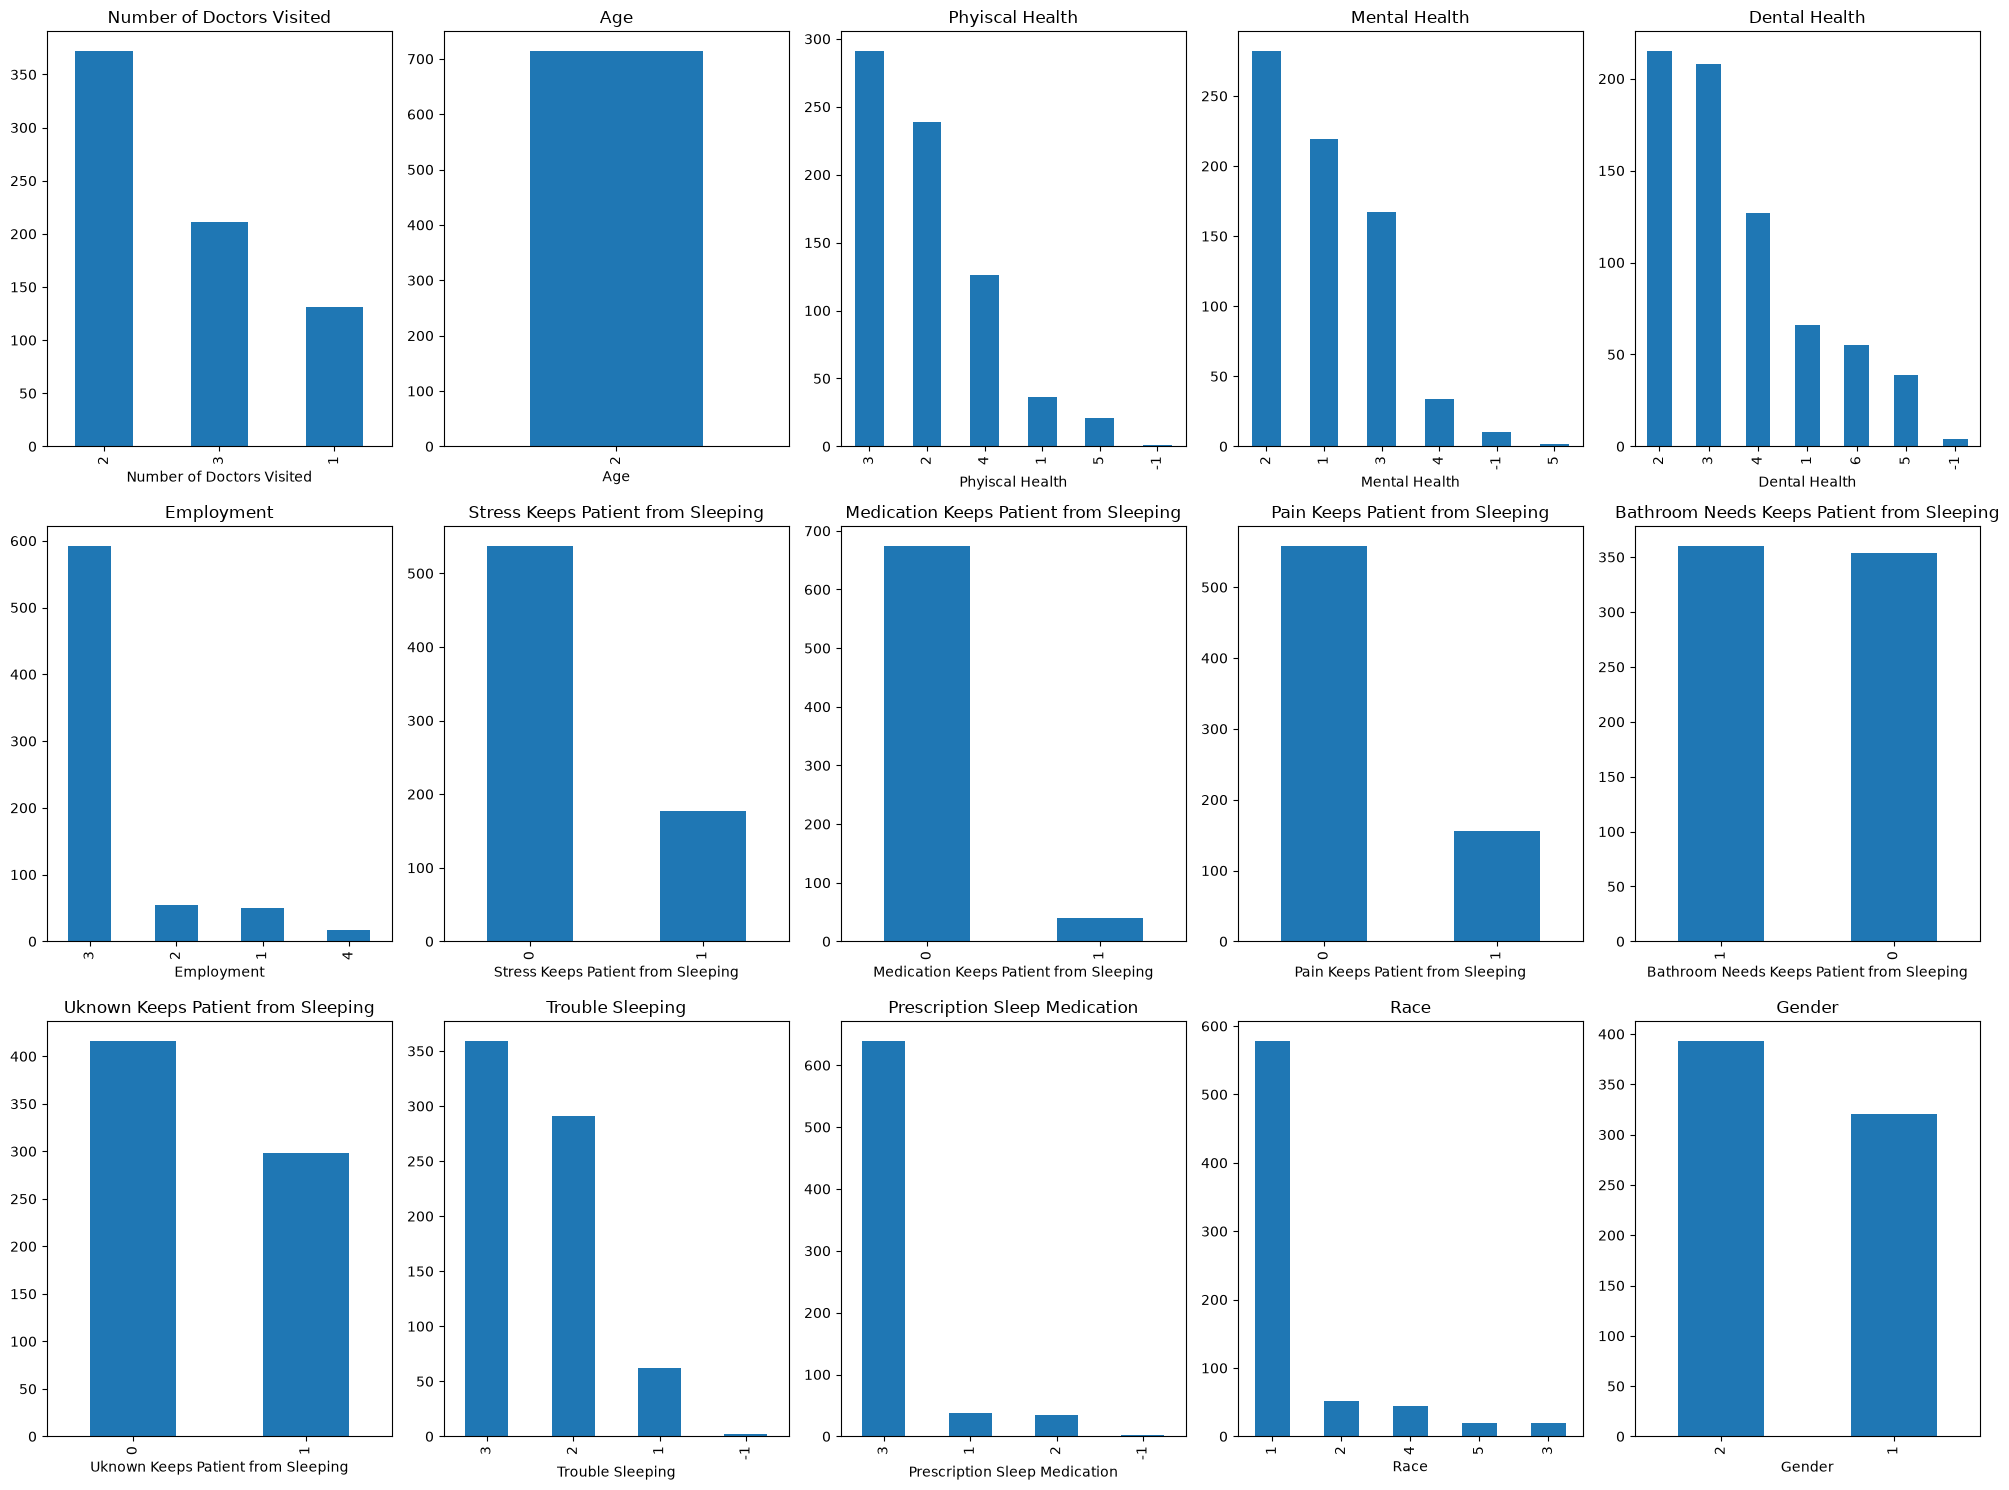

In [68]:
# visualizing the distribution of the features
fig, axes = plt.subplots(3, 5, figsize=(20, 15))
axes = axes.ravel()

for i, column in enumerate(df.columns):
    df[column].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(column)

plt.tight_layout()
plt.show()

In [69]:
df['Number of Doctors Visited'].describe()

count    714.000000
mean       2.112045
std        0.683441
min        1.000000
25%        2.000000
50%        2.000000
75%        3.000000
max        3.000000
Name: Number of Doctors Visited, dtype: float64

In [70]:
df['Age'].describe()

count    714.0
mean       2.0
std        0.0
min        2.0
25%        2.0
50%        2.0
75%        2.0
max        2.0
Name: Age, dtype: float64

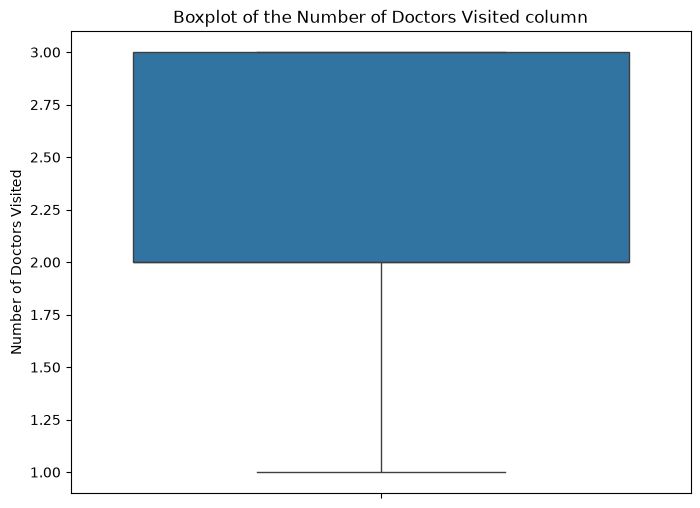

In [71]:
plt.figure(figsize=(8, 6))
sns.boxplot(y='Number of Doctors Visited', data=df)
plt.title("Boxplot of the Number of Doctors Visited column")
plt.show()

In [72]:
Q1_UP = df['Number of Doctors Visited'].quantile(0.25)
Q2_UP = df['Number of Doctors Visited'].quantile(0.5)
Q3_UP = df['Number of Doctors Visited'].quantile(0.75)

lower_limit_UP = Q1_UP - 1.5 * (Q3_UP - Q1_UP)
upper_limit_UP = Q3_UP + 1.5 * (Q3_UP - Q1_UP)

print(f"Feature: Number of Doctors Visited")
print(f"- Q1: {Q1_UP:.2f}")
print(f"- Q2 (Mediana): {Q2_UP:.2f}")
print(f"- Q3: {Q3_UP:.2f}")
print(f"- Limite Inferior: {lower_limit_UP:.2f}")
print(f"- Limite Superior: {upper_limit_UP:.2f}")

Feature: Number of Doctors Visited
- Q1: 2.00
- Q2 (Mediana): 2.00
- Q3: 3.00
- Limite Inferior: 0.50
- Limite Superior: 4.50


Existe um viés na Classe 2. Portanto seria bom utilizar tecnica de  subamostragem para a classe super-representada.

In [73]:
# Calculate the class distribution
class_distribution = df['Number of Doctors Visited'].value_counts()
print(class_distribution)

Number of Doctors Visited
2    372
3    211
1    131
Name: count, dtype: int64


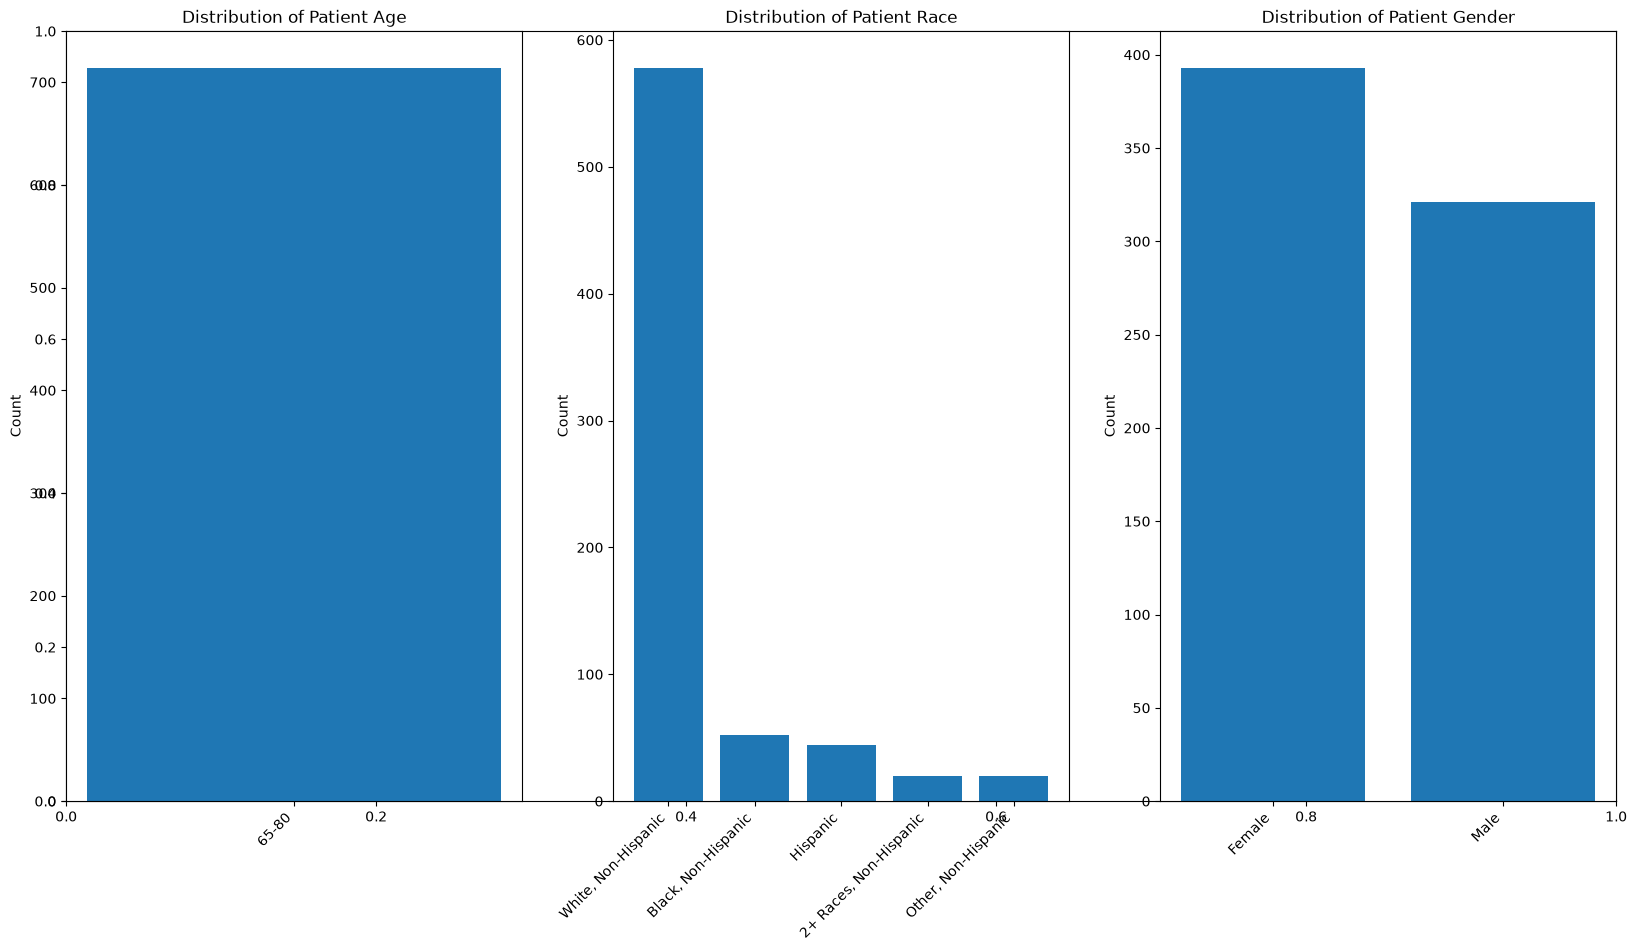

In [74]:
df_ = df.copy()

age_dict = { 1: "50-64", 2: "65-80" }
df_['Age'] = df_['Age'].map(age_dict)

race_dict = { 1: "White, Non-Hispanic", 2: "Black, Non-Hispanic", 3: "Other, Non-Hispanic", 4: "Hispanic", 5: "2+ Races, Non-Hispanic" }
df_['Race'] = df_['Race'].map(race_dict)

gender_dict = { 1: "Male", 2: "Female" }
df_['Gender'] = df_['Gender'].map(gender_dict)

plt.subplots(figsize=(20, 10))
for i, col in enumerate(['Age', 'Race' , 'Gender']):
    plt.subplot(1, 3, i + 1)

    x = df_[col].value_counts()
    plt.bar(x.index, x.values)
    plt.title('Distribution of Patient ' + col)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Count')

plt.show()

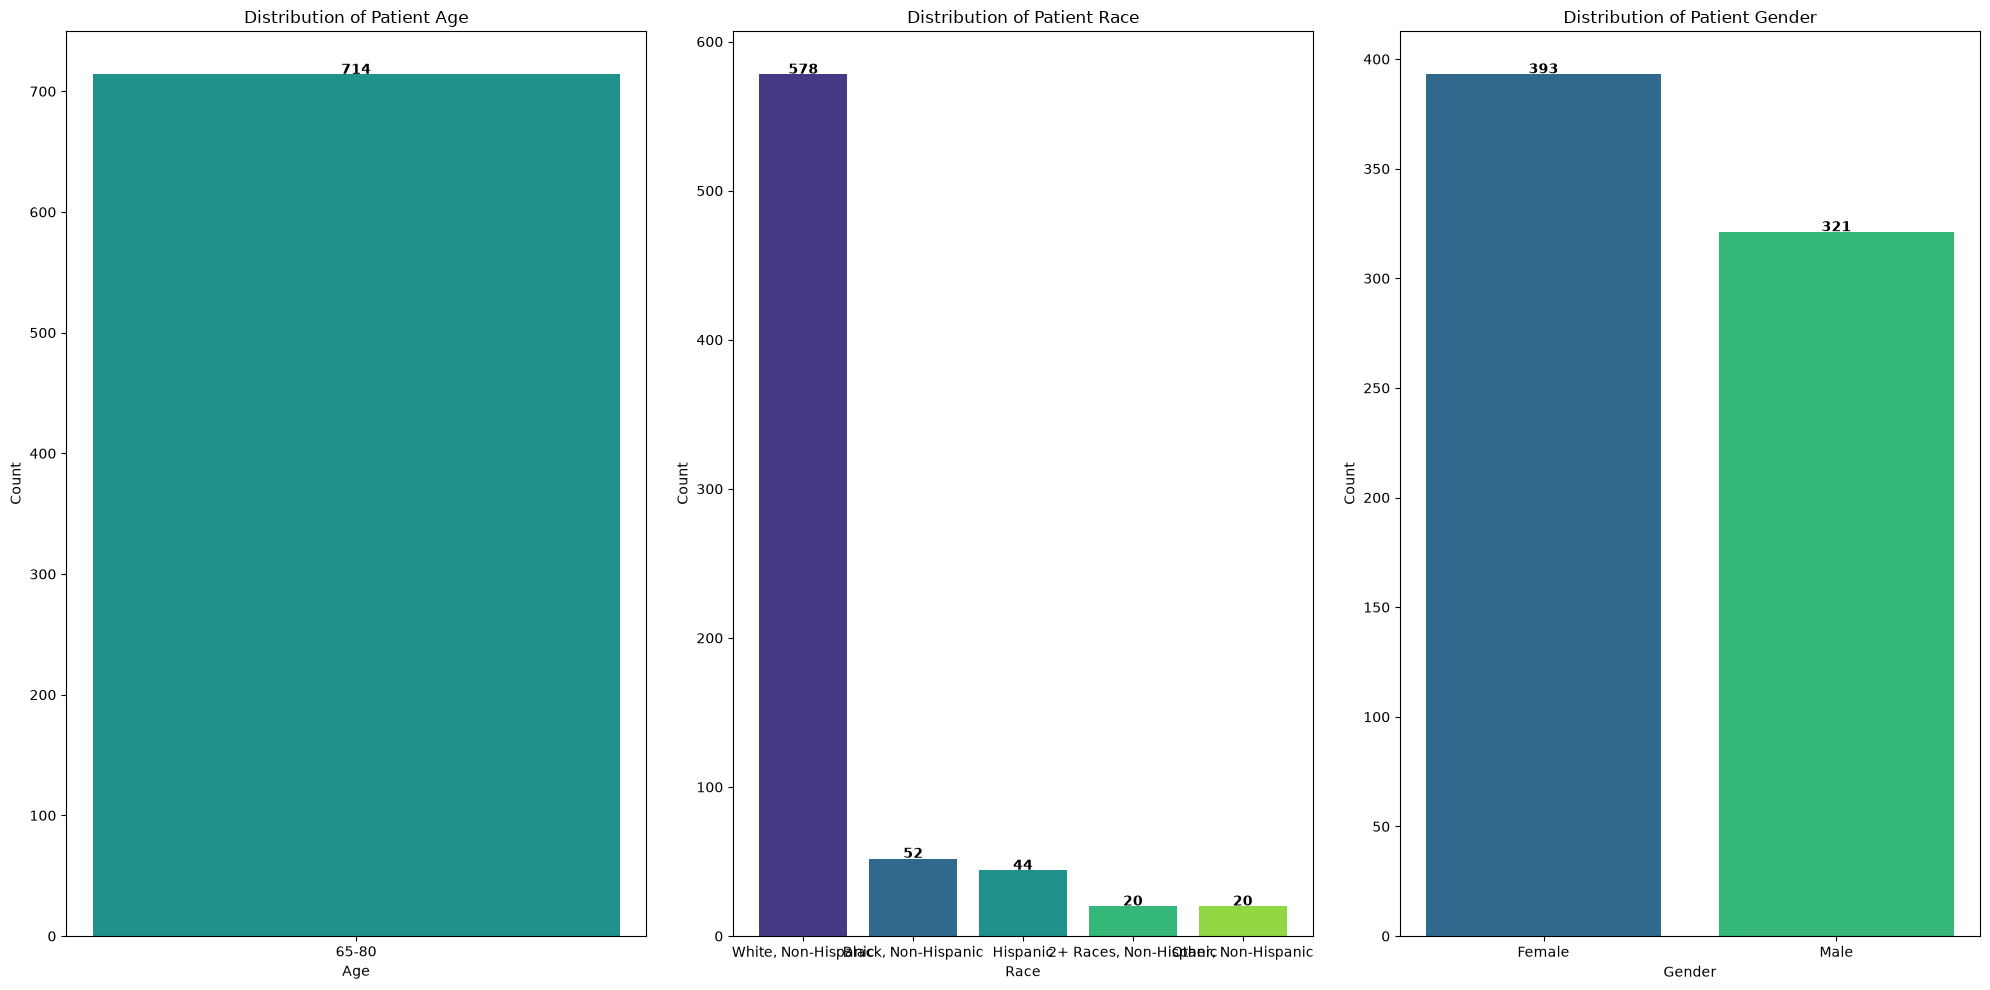

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(20, 10))
for i, col in enumerate(['Age', 'Race', 'Gender']):
    x = df_[col].value_counts()
    axes[i].bar(x.index.astype(str), x.values, color=sns.color_palette("viridis", len(x)))
    axes[i].set_title('Distribution of Patient ' + col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    # Adicionar valores em cima das barras
    for j, v in enumerate(x.values):
        axes[i].text(j, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


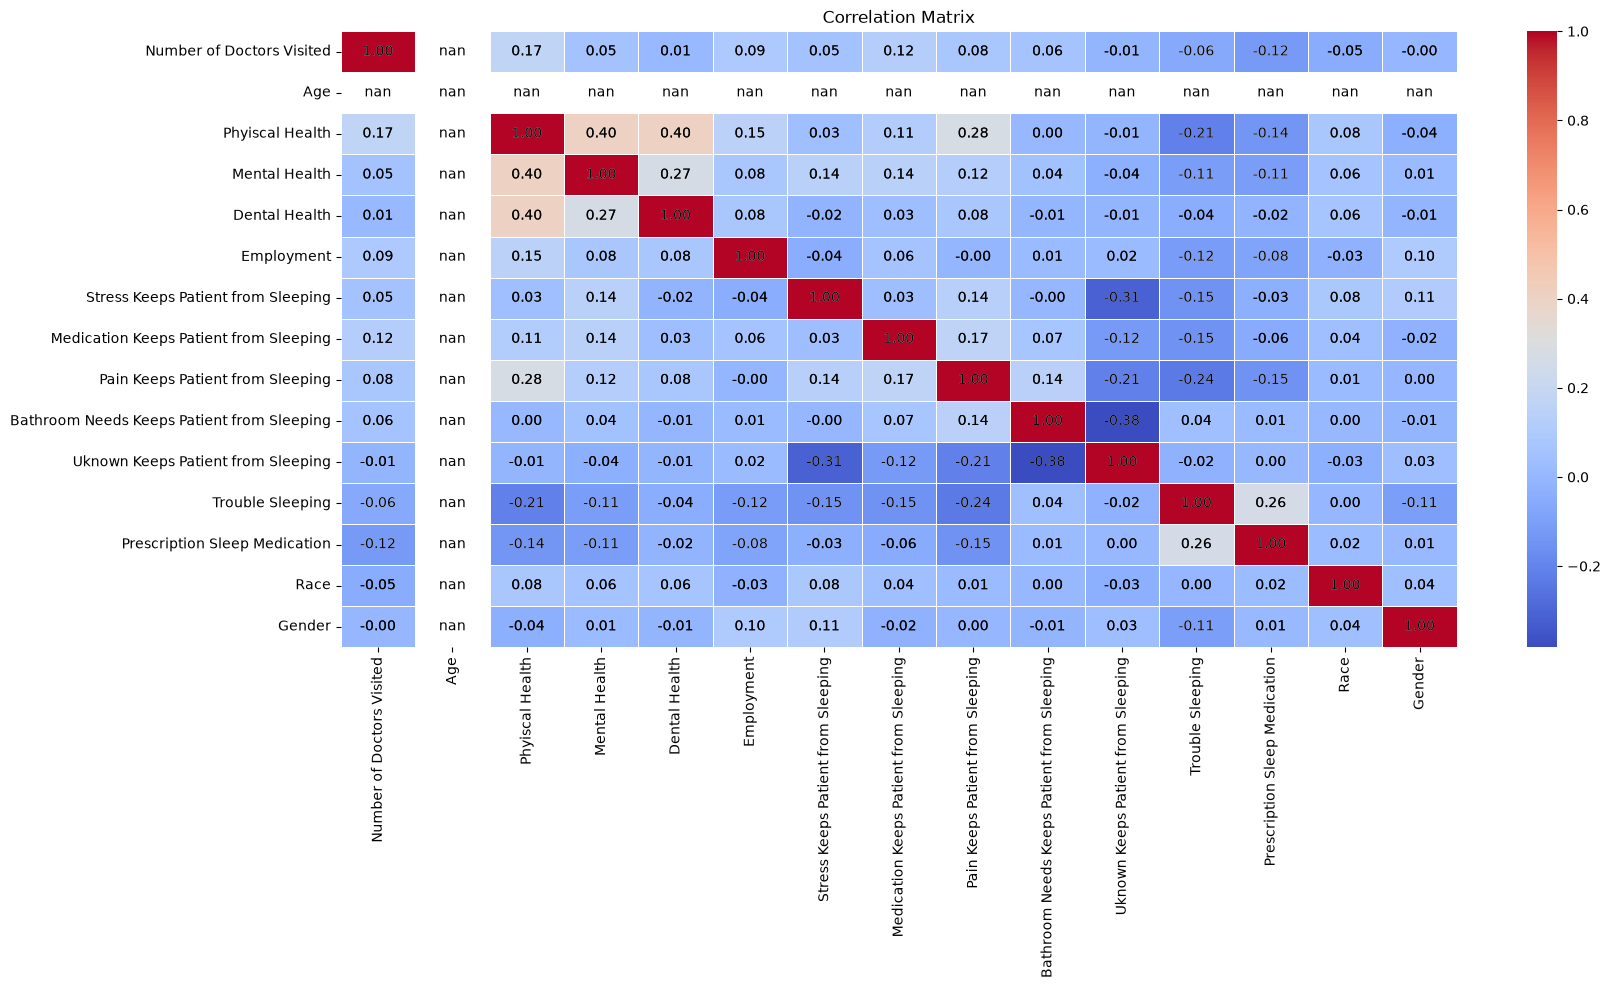

In [76]:
# Calculate the correlation matrix
corr_matrix = df.corr()

# Create a heatmap
plt.figure(figsize=(18, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5)

# Add annotations to the heatmap
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        text = f"{corr_matrix.iloc[i, j]:.2f}"
        plt.text(j + 0.5, i + 0.5, text, ha='center', va='center', color='black')

plt.title("Correlation Matrix")
plt.show()

In [77]:
# Substitui todos os valores 3 por 2 na coluna alvo
df['Number of Doctors Visited'] = df['Number of Doctors Visited'].replace(3, 2)

Fazendo One-Hote-Encoding em todas as features por serem categoricas

In [78]:
categorical_features = df.columns.tolist()
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=False)
df_encoded

,Number of Doctors Visited_1,Number of Doctors Visited_2,Age_2,Phyiscal Health_-1,Phyiscal Health_1,Phyiscal Health_2,Phyiscal Health_3,Phyiscal Health_4,Phyiscal Health_5,Mental Health_-1,...,Prescription Sleep Medication_1,Prescription Sleep Medication_2,Prescription Sleep Medication_3,Race_1,Race_2,Race_3,Race_4,Race_5,Gender_1,Gender_2
0,False,True,True,False,False,False,False,True,False,False,...,False,False,True,True,False,False,False,False,False,True
1,False,True,True,False,False,False,False,True,False,False,...,False,False,True,True,False,False,False,False,True,False
2,False,True,True,False,False,False,True,False,False,False,...,False,False,True,False,False,False,True,False,True,False
3,True,False,True,False,False,False,True,False,False,False,...,False,False,True,False,False,False,True,False,False,True
4,False,True,True,False,False,False,True,False,False,False,...,False,False,True,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,False,True,True,False,False,True,False,False,False,False,...,False,False,True,True,False,False,False,False,True,False
710,False,True,True,False,False,True,False,False,False,False,...,False,False,True,True,False,False,False,False,False,True
711,False,True,True,False,False,False,False,True,False,False,...,False,False,True,True,False,False,False,False,True,False
712,False,True,True,False,False,False,True,False,False,False,...,False,False,True,True,False,False,False,False,False,True


In [79]:
df_encoded = df_encoded.reset_index(drop=True)

In [80]:
X = df_encoded.drop(columns=['Number of Doctors Visited_1', 'Number of Doctors Visited_2'])
y = df_encoded[['Number of Doctors Visited_1', 'Number of Doctors Visited_2']]

In [81]:
X

,Age_2,Phyiscal Health_-1,Phyiscal Health_1,Phyiscal Health_2,Phyiscal Health_3,Phyiscal Health_4,Phyiscal Health_5,Mental Health_-1,Mental Health_1,Mental Health_2,...,Prescription Sleep Medication_1,Prescription Sleep Medication_2,Prescription Sleep Medication_3,Race_1,Race_2,Race_3,Race_4,Race_5,Gender_1,Gender_2
0,True,False,False,False,False,True,False,False,False,False,...,False,False,True,True,False,False,False,False,False,True
1,True,False,False,False,False,True,False,False,False,True,...,False,False,True,True,False,False,False,False,True,False
2,True,False,False,False,True,False,False,False,False,True,...,False,False,True,False,False,False,True,False,True,False
3,True,False,False,False,True,False,False,False,False,True,...,False,False,True,False,False,False,True,False,False,True
4,True,False,False,False,True,False,False,False,False,False,...,False,False,True,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,True,False,False,True,False,False,False,False,False,True,...,False,False,True,True,False,False,False,False,True,False
710,True,False,False,True,False,False,False,False,False,True,...,False,False,True,True,False,False,False,False,False,True
711,True,False,False,False,False,True,False,False,False,True,...,False,False,True,True,False,False,False,False,True,False
712,True,False,False,False,True,False,False,False,True,False,...,False,False,True,True,False,False,False,False,False,True


In [82]:
y

,Number of Doctors Visited_1,Number of Doctors Visited_2
0,False,True
1,False,True
2,False,True
3,True,False
4,False,True
...,...,...
709,False,True
710,False,True
711,False,True
712,False,True


In [83]:
# feature_importances = pd.DataFrame(model.feature_importances_,
#                                    index = X.columns,
#                                    columns=['importance']).sort_values('importance', ascending=False)

# # Plotting
# plt.figure(figsize=(10, 6))
# feature_importances.plot(kind='barh')

In [84]:
y

,Number of Doctors Visited_1,Number of Doctors Visited_2
0,False,True
1,False,True
2,False,True
3,True,False
4,False,True
...,...,...
709,False,True
710,False,True
711,False,True
712,False,True


In [85]:
# colunas_lixo = [
#     'Race_5', 'Uknown Keeps Patient from Sleeping_0', 'Prescription Sleep Medication_2',
#     'Phyiscal Health_1', 'Mental Health_-1', 'Race_4', 'Dental Health_1',
#     'Prescription Sleep Medication_-1', 'Dental Health_-1', 'Mental Health_5',
#     'Phyiscal Health_-1', 'Age_2', 'Gender_1', 'Phyiscal Health_3', 'Phyiscal Health_5', 'Dental Health_3',
#     'Race_2', 'Trouble Sleeping_3', 'Mental Health_3', 'Gender_2',
#     'Employment_1', 'Trouble Sleeping_2', 'Dental Health_6', 'Trouble Sleeping_-1'
# ]

In [86]:
# X = X.drop(columns=colunas_lixo)

In [87]:
print(f"Dimensões atuais: {X.shape}")

Dimensões atuais: (714, 49)


In [88]:
X_resampled = X.values
y_resampled = y.values

In [89]:
y = np.argmax(y_resampled, axis=1)

y = pd.Series(y)
class_distribution = y.value_counts()
print("Class distribution after NearMiss undersampling:")
print(class_distribution)

Class distribution after NearMiss undersampling:
1    583
0    131
Name: count, dtype: int64


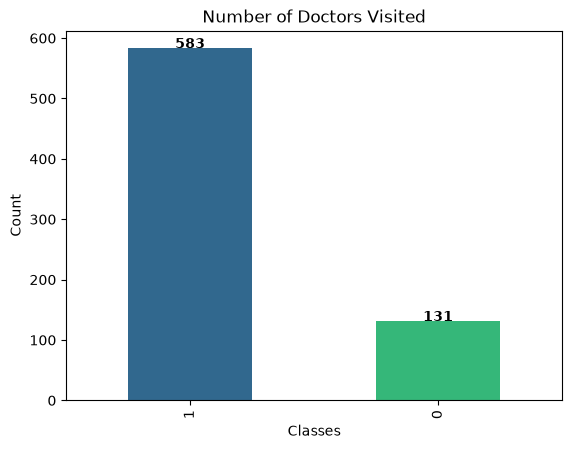

In [90]:
ax = y.value_counts().plot(kind='bar', title='Number of Doctors Visited', color=sns.color_palette("viridis", len(y.value_counts())))
ax.set_xlabel('Classes')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 0.5, str(int(p.get_height())), ha='center', fontweight='bold')
plt.show()


In [91]:
scaler = StandardScaler()
X_escalonado = scaler.fit_transform(X)

In [92]:
pca = PCA(n_components=2)
componentes_principais = pca.fit_transform(X_escalonado)
df_pca = pd.DataFrame(data=componentes_principais, columns=['PC1', 'PC2'])
df_pca['Classe_Alvo'] = y

<Axes: xlabel='PC1', ylabel='PC2'>

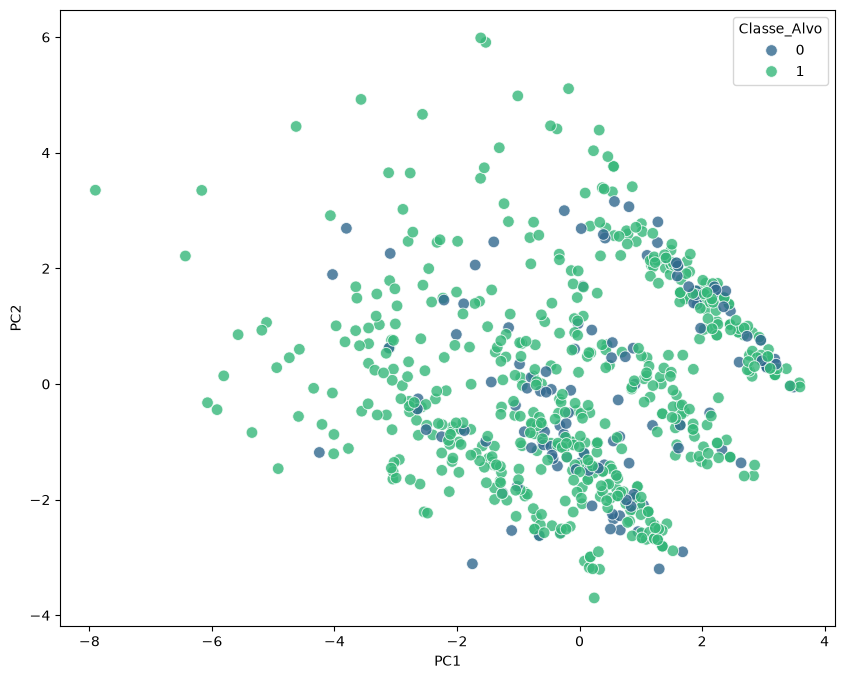

In [93]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Classe_Alvo', 
    palette='viridis',
    data=df_pca, 
    alpha=0.8,
    s=70
)

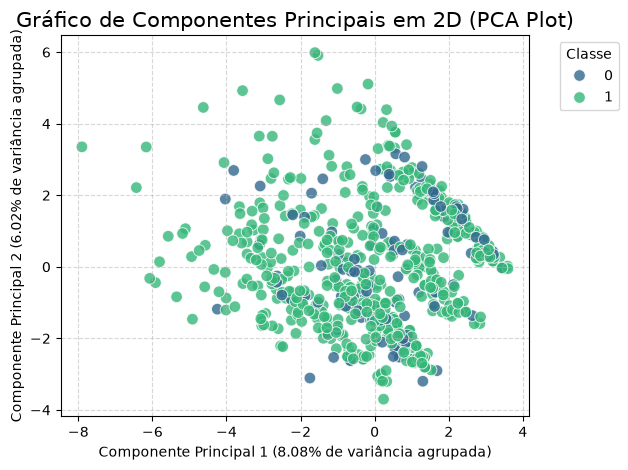

In [94]:
sns.scatterplot(x='PC1', y='PC2', hue='Classe_Alvo', palette='viridis', data=df_pca, alpha=0.8, s=70)
expl_1 = pca.explained_variance_ratio_[0]*100
expl_2 = pca.explained_variance_ratio_[1]*100
plt.title('Gráfico de Componentes Principais em 2D (PCA Plot)', fontsize=15)
plt.xlabel(f"Componente Principal 1 ({expl_1:.2f}% de variância agrupada)")
plt.ylabel(f"Componente Principal 2 ({expl_2:.2f}% de variância agrupada)")
plt.legend(title='Classe', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

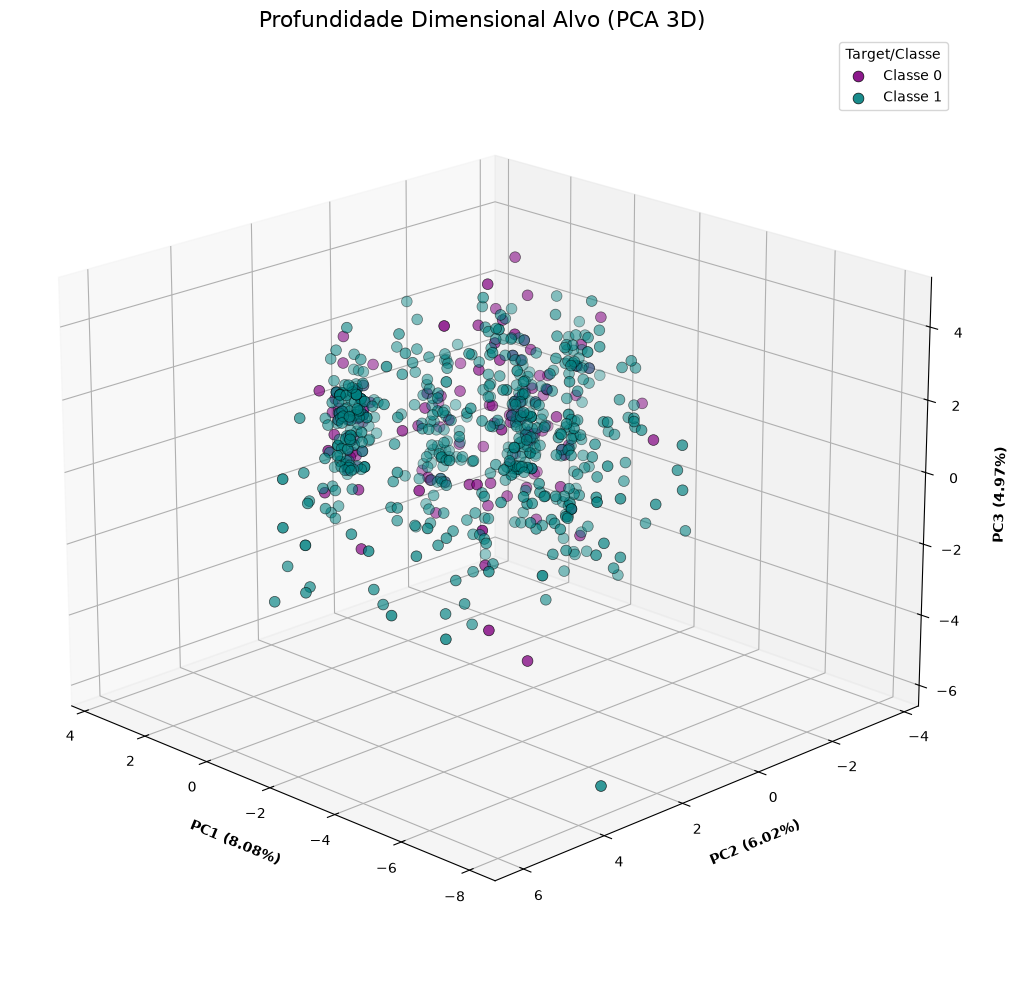

In [95]:
pca_3d = PCA(n_components=3)
comps_3d = pca_3d.fit_transform(X_escalonado)
    
df_pca3 = pd.DataFrame(data=comps_3d, columns=['PC1', 'PC2', 'PC3'])
df_pca3['Classe_Alvo'] = y
    
# Matplotlib puro pro 3D 
fig3d = plt.figure(figsize=(12, 10))
ax = fig3d.add_subplot(111, projection='3d')

cores = ['purple', 'teal', 'gold'] 
classes_unicas = sorted(list(df_pca3['Classe_Alvo'].unique()))
    
# Plota classe por classe
for cls, cor in zip(classes_unicas, cores):
    subset = df_pca3[df_pca3['Classe_Alvo'] == cls]
    ax.scatter(subset['PC1'], subset['PC2'], subset['PC3'], 
                color=cor, label=f'Classe {cls}', s=60, alpha=0.9, edgecolor='black', linewidth=0.5)

e1_3d = pca_3d.explained_variance_ratio_[0]*100
e2_3d = pca_3d.explained_variance_ratio_[1]*100
e3_3d = pca_3d.explained_variance_ratio_[2]*100

ax.set_xlabel(f"PC1 ({e1_3d:.2f}%)", fontweight='bold', labelpad=10)
ax.set_ylabel(f"PC2 ({e2_3d:.2f}%)", fontweight='bold', labelpad=10)
ax.set_zlabel(f"PC3 ({e3_3d:.2f}%)", fontweight='bold', labelpad=10)
plt.title('Profundidade Dimensional Alvo (PCA 3D)', fontsize=16)
plt.legend(title='Target/Classe', loc='best')

# Opcional (rotacionar ângulo)
ax.view_init(elev=20, azim=135)
plt.tight_layout()
plt.show()


In [96]:
df = pd.DataFrame(X, columns=X.columns)

In [97]:
df_encoded.shape

(714, 51)

In [98]:
df

,Age_2,Phyiscal Health_-1,Phyiscal Health_1,Phyiscal Health_2,Phyiscal Health_3,Phyiscal Health_4,Phyiscal Health_5,Mental Health_-1,Mental Health_1,Mental Health_2,...,Prescription Sleep Medication_1,Prescription Sleep Medication_2,Prescription Sleep Medication_3,Race_1,Race_2,Race_3,Race_4,Race_5,Gender_1,Gender_2
0,True,False,False,False,False,True,False,False,False,False,...,False,False,True,True,False,False,False,False,False,True
1,True,False,False,False,False,True,False,False,False,True,...,False,False,True,True,False,False,False,False,True,False
2,True,False,False,False,True,False,False,False,False,True,...,False,False,True,False,False,False,True,False,True,False
3,True,False,False,False,True,False,False,False,False,True,...,False,False,True,False,False,False,True,False,False,True
4,True,False,False,False,True,False,False,False,False,False,...,False,False,True,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,True,False,False,True,False,False,False,False,False,True,...,False,False,True,True,False,False,False,False,True,False
710,True,False,False,True,False,False,False,False,False,True,...,False,False,True,True,False,False,False,False,False,True
711,True,False,False,False,False,True,False,False,False,True,...,False,False,True,True,False,False,False,False,True,False
712,True,False,False,False,True,False,False,False,True,False,...,False,False,True,True,False,False,False,False,False,True


In [99]:
x = df

In [100]:
x

,Age_2,Phyiscal Health_-1,Phyiscal Health_1,Phyiscal Health_2,Phyiscal Health_3,Phyiscal Health_4,Phyiscal Health_5,Mental Health_-1,Mental Health_1,Mental Health_2,...,Prescription Sleep Medication_1,Prescription Sleep Medication_2,Prescription Sleep Medication_3,Race_1,Race_2,Race_3,Race_4,Race_5,Gender_1,Gender_2
0,True,False,False,False,False,True,False,False,False,False,...,False,False,True,True,False,False,False,False,False,True
1,True,False,False,False,False,True,False,False,False,True,...,False,False,True,True,False,False,False,False,True,False
2,True,False,False,False,True,False,False,False,False,True,...,False,False,True,False,False,False,True,False,True,False
3,True,False,False,False,True,False,False,False,False,True,...,False,False,True,False,False,False,True,False,False,True
4,True,False,False,False,True,False,False,False,False,False,...,False,False,True,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,True,False,False,True,False,False,False,False,False,True,...,False,False,True,True,False,False,False,False,True,False
710,True,False,False,True,False,False,False,False,False,True,...,False,False,True,True,False,False,False,False,False,True
711,True,False,False,False,False,True,False,False,False,True,...,False,False,True,True,False,False,False,False,True,False
712,True,False,False,False,True,False,False,False,True,False,...,False,False,True,True,False,False,False,False,False,True


In [101]:
nomes_features = x.columns.to_numpy()
print(nomes_features)

['Age_2' 'Phyiscal Health_-1' 'Phyiscal Health_1' 'Phyiscal Health_2'
 'Phyiscal Health_3' 'Phyiscal Health_4' 'Phyiscal Health_5'
 'Mental Health_-1' 'Mental Health_1' 'Mental Health_2' 'Mental Health_3'
 'Mental Health_4' 'Mental Health_5' 'Dental Health_-1' 'Dental Health_1'
 'Dental Health_2' 'Dental Health_3' 'Dental Health_4' 'Dental Health_5'
 'Dental Health_6' 'Employment_1' 'Employment_2' 'Employment_3'
 'Employment_4' 'Stress Keeps Patient from Sleeping_0'
 'Stress Keeps Patient from Sleeping_1'
 'Medication Keeps Patient from Sleeping_0'
 'Medication Keeps Patient from Sleeping_1'
 'Pain Keeps Patient from Sleeping_0' 'Pain Keeps Patient from Sleeping_1'
 'Bathroom Needs Keeps Patient from Sleeping_0'
 'Bathroom Needs Keeps Patient from Sleeping_1'
 'Uknown Keeps Patient from Sleeping_0'
 'Uknown Keeps Patient from Sleeping_1' 'Trouble Sleeping_-1'
 'Trouble Sleeping_1' 'Trouble Sleeping_2' 'Trouble Sleeping_3'
 'Prescription Sleep Medication_-1' 'Prescription Sleep Medicati

In [102]:
x = x.values

In [103]:
x

array([[ True, False, False, ..., False, False,  True],
       [ True, False, False, ..., False,  True, False],
       [ True, False, False, ..., False,  True, False],
       ...,
       [ True, False, False, ..., False,  True, False],
       [ True, False, False, ..., False, False,  True],
       [ True, False, False, ..., False,  True, False]], shape=(714, 49))

In [104]:
param_grid_KNN = {
    'n_neighbors': [10, 20, 30, 40],
    'metric': ['euclidean', 'manhattan', 'minkowski', 'cosine'],
}

In [105]:
param_grid_DT = {
    'max_depth': [3, 5, 7],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf': [5, 10],
}

In [106]:
param_grid_RF = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'min_samples_leaf': [2, 5, 10],
}

In [107]:
param_grid_SVM = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf'],
    'gamma': ['scale', 0.1],
    'probability': [True]
}

In [108]:
param_grid_MLP = {
    'hidden_layer_sizes': [(32, 16), (64,)], 
     'alpha': [0.01, 0.1, 1.0],
     'learning_rate_init': [0.001], 
     'activation': ['relu', 'tanh'], 
     'solver': ['adam'], 
     'max_iter': [2000],
     'early_stopping': [True], 
     'random_state': [42],
}

In [109]:
param_grid_LR = {
    'C': [0.01, 0.1, 1, 10],
     'solver': ['saga'],
     'penalty': ['l1', 'l2'],
}

In [110]:
param_grid_XGB = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.05, 0.1], 
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'reg_alpha': [0.1, 1.0],
}

In [111]:
param_grid_NB = {
    'var_smoothing': [1e-11, 1e-10, 1e-9, 1e-8, 1e-7]
}

In [112]:
param_grid_NC = {
    'metric': ['euclidean', 'manhattan'],
    'shrink_threshold': [None, 0.1, 0.5, 1.0]
}

In [113]:
param_grid_OPF = {
    'distance':['euclidean', 'squared_euclidean', 'log_squared_euclidean', 
                'manhattan', 'canberra', 'chebyshev']
}

In [114]:
# FASE 1 - AVALIAÇÃO CORRIGIDA (Gate 1; não comparável aos resultados legados)
# Dados, encoding, scaler, seleção e avaliação isolados dos resultados legados.
from copy import deepcopy
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, ParameterGrid
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (average_precision_score, balanced_accuracy_score,
                             confusion_matrix, f1_score, matthews_corrcoef,
                             precision_score, recall_score, roc_auc_score)
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC as SupportVectorMachineClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from opfython.models import SupervisedOPF

SEED = 42
TARGET_FASE1 = 'Number of Doctors Visited'
DATA_PATH_FASE1 = 'NPHA-doctor-visits.csv'

df_raw_fase1 = pd.read_csv(DATA_PATH_FASE1)
if TARGET_FASE1 not in df_raw_fase1.columns:
    raise KeyError(f'Coluna target ausente: {TARGET_FASE1}')
valores_target = set(df_raw_fase1[TARGET_FASE1].dropna().unique())
if not valores_target.issubset({1, 2, 3}) or valores_target != {1, 2, 3}:
    raise ValueError(f'Códigos target inválidos: {valores_target}; esperado {{1, 2, 3}}')

X_raw = df_raw_fase1.drop(columns=[TARGET_FASE1]).copy()
y_raw = df_raw_fase1[TARGET_FASE1].copy()
y = y_raw.map({1: 0, 2: 1, 3: 1}).to_numpy(dtype=int)
if X_raw.shape[1] != df_raw_fase1.shape[1] - 1:
    raise AssertionError('Target ainda está presente em X_raw')
if set(y) != {0, 1}:
    raise AssertionError(f'Classes codificadas inesperadas: {set(y)}')
contagens_target = pd.Series(y).value_counts().sort_index()
if contagens_target.to_dict() != {0: 131, 1: 583}:
    raise AssertionError(f'Contagens inesperadas: {contagens_target.to_dict()}')
percentuais_target = pd.Series(y).value_counts(normalize=True).sort_index() * 100
print('Distribuição target:')
print(pd.DataFrame({'contagem': contagens_target, 'percentual': percentuais_target.round(2)}))
print('Mapeamento: 0 = 0–1 consulta; 1 = 2+ consultas')

SEED = 42
outer_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
feature_columns_fase1 = X_raw.columns.tolist()

# Grids congelados: nenhuma configuração depende de células globais ou de dados externos.
param_grids_fase1 = {
    'KNN': {'n_neighbors': [10, 20, 30, 40], 'metric': ['euclidean', 'manhattan', 'minkowski', 'cosine']},
    'DT': {'max_depth': [3, 5, 7], 'min_samples_split': [10, 20, 30], 'min_samples_leaf': [5, 10]},
    'RF': {'n_estimators': [100, 300], 'max_depth': [3, 7], 'min_samples_leaf': [2, 10]},
    'SVM': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'gamma': ['scale', 0.1], 'probability': [True]},
    'MLP': {'hidden_layer_sizes': [(32, 16), (64,)], 'alpha': [0.01, 0.1, 1.0], 'learning_rate_init': [0.001], 'activation': ['relu', 'tanh'], 'solver': ['adam'], 'max_iter': [2000], 'early_stopping': [True], 'random_state': [SEED]},
    'LR': {'C': [0.01, 0.1, 1, 10], 'solver': ['saga'], 'penalty': ['l1', 'l2']},
    'XGB': {'n_estimators': [100], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1], 'subsample': [0.8], 'colsample_bytree': [0.8], 'reg_alpha': [0.1]},
    'NB': {'var_smoothing': [1e-11, 1e-10, 1e-9, 1e-8, 1e-7]},
    'NC': {'metric': ['euclidean', 'manhattan'], 'shrink_threshold': [None, 0.1, 0.5, 1.0]},
    'OPF': {'distance': ['euclidean', 'manhattan', 'chebyshev']},
}
param_grids_fase1 = deepcopy(param_grids_fase1)
# Organização: outer split -> listas por modelo -> ParameterGrid interno -> refit/OOF.
model_names_fase1 = list(param_grids_fase1)
combinacoes_fase1 = {nome: len(list(ParameterGrid(grid))) for nome, grid in param_grids_fase1.items()}
print('Combinações por modelo:', combinacoes_fase1)

class OPFAdapterFase1:
    def __init__(self, distance):
        self.distance = distance
        self.modelo = SupervisedOPF(distance=distance)
    def get_params(self, deep=True):
        return {'distance': self.distance}
    def fit(self, X_fit, y_fit):
        X_fit = X_fit.toarray() if hasattr(X_fit, 'toarray') else np.asarray(X_fit)
        X_fit = np.asarray(X_fit, dtype=float)
        if X_fit.ndim != 2: raise ValueError('OPF requer features densas 2D')
        self.modelo.fit(X_fit, np.asarray(y_fit, dtype=np.int32).reshape(-1))
        return self
    def predict(self, X_eval):
        X_eval = X_eval.toarray() if hasattr(X_eval, 'toarray') else np.asarray(X_eval)
        X_eval = np.asarray(X_eval, dtype=float)
        if X_eval.ndim != 2: raise ValueError('OPF requer features densas 2D')
        return np.asarray(self.modelo.predict(X_eval)).reshape(-1)

def construir_estimador_fase1(nome, params):
    params = dict(params)
    if nome == 'KNN': return KNeighborsClassifier(**params)
    if nome == 'DT': return DecisionTreeClassifier(random_state=SEED, **params)
    if nome == 'RF': return RandomForestClassifier(random_state=SEED, n_jobs=-1, **params)
    if nome == 'SVM': return SupportVectorMachineClassifier(random_state=SEED, **params)
    if nome == 'MLP': return MLPClassifier(**params)
    if nome == 'LR': return LogisticRegression(max_iter=1000, random_state=SEED, **params)
    if nome == 'XGB': return XGBClassifier(random_state=SEED, n_jobs=-1, eval_metric='logloss', **params)
    if nome == 'NB': return GaussianNB(**params)
    if nome == 'NC': return NearestCentroid(**params)
    if nome == 'OPF': return OPFAdapterFase1(**params)
    raise ValueError(f'Modelo desconhecido: {nome}')

def validar_params_fase1(modelo, params):
    if not hasattr(modelo, 'get_params'):
        raise TypeError(f'{type(modelo).__name__} não expõe get_params')
    aceitos = set(modelo.get_params(deep=True))
    incompatíveis = set(params) - aceitos
    if incompatíveis:
        raise ValueError(f'Parâmetros incompatíveis: {sorted(incompatíveis)}')

def preparar_features_fase1(X_fit, X_eval):
    encoder = ColumnTransformer([('onehot', OneHotEncoder(handle_unknown='ignore'), feature_columns_fase1)], remainder='drop')
    X_fit_encoded = encoder.fit_transform(X_fit)
    X_eval_encoded = encoder.transform(X_eval)
    scaler = StandardScaler(with_mean=False)
    X_fit_scaled = scaler.fit_transform(X_fit_encoded)
    X_eval_scaled = scaler.transform(X_eval_encoded)
    return X_fit_scaled, X_eval_scaled

def entrada_modelo_fase1(modelo, X):
    if isinstance(modelo, GaussianNB):
        return X.toarray() if hasattr(X, 'toarray') else np.asarray(X)
    return X

def ajustar_estimador_fase1(modelo, X_fit, y_fit, params):
    validar_params_fase1(modelo, params)
    modelo.fit(entrada_modelo_fase1(modelo, X_fit), y_fit)
    return modelo

def prever_fase1(modelo, X_eval):
    return np.asarray(modelo.predict(entrada_modelo_fase1(modelo, X_eval))).reshape(-1)

score_capabilities_fase1 = {
    'Dummy': 'predict_proba', 'KNN': 'predict_proba', 'DT': 'predict_proba', 'RF': 'predict_proba',
    'SVM': 'decision_function', 'MLP': 'predict_proba', 'LR': 'predict_proba', 'XGB': 'predict_proba',
    'NB': 'predict_proba', 'NC': None, 'OPF': None,
}
score_motivos_fase1 = {nome: [] for nome in score_capabilities_fase1}
def obter_score_fase1(modelo, nome, X_eval):
    capacidade = score_capabilities_fase1[nome]
    if capacidade is None:
        motivo = f'{nome}: sem capacidade de score probabilístico/decision_function'
        score_motivos_fase1[nome].append(motivo)
        return None
    if capacidade == 'predict_proba':
        proba = np.asarray(modelo.predict_proba(entrada_modelo_fase1(modelo, X_eval)))
        classes = np.asarray(modelo.classes_)
        if proba.ndim != 2 or 1 not in classes:
            raise ValueError(f'{nome}: predict_proba sem coluna válida para classe 1')
        return proba[:, list(classes).index(1)]
    if capacidade == 'decision_function':
        score = np.asarray(modelo.decision_function(entrada_modelo_fase1(modelo, X_eval)))
        if score.ndim == 2:
            classes = np.asarray(modelo.classes_)
            if 1 not in classes: raise ValueError(f'{nome}: decision_function sem classe 1')
            return score[:, list(classes).index(1)]
        return score
    raise ValueError(f'Capacidade de score não mapeada: {capacidade}')

def avaliar_fase1(y_true, y_pred, score=None):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    precision = precision_score(y_true, y_pred, labels=[0, 1], average=None, zero_division=0)
    recall = recall_score(y_true, y_pred, labels=[0, 1], average=None, zero_division=0)
    f1_classes = f1_score(y_true, y_pred, labels=[0, 1], average=None, zero_division=0)
    resultado = {'tn': cm[0,0], 'fp': cm[0,1], 'fn': cm[1,0], 'tp': cm[1,1], 'precision_classe_0': precision[0], 'precision_classe_1': precision[1], 'recall_classe_0': recall[0], 'recall_classe_1': recall[1], 'f1_classe_0': f1_classes[0], 'f1_classe_1': f1_classes[1], 'f1_macro': f1_score(y_true, y_pred, labels=[0,1], average='macro', zero_division=0), 'f1_weighted': f1_score(y_true, y_pred, labels=[0,1], average='weighted', zero_division=0), 'balanced_accuracy': balanced_accuracy_score(y_true, y_pred), 'mcc': matthews_corrcoef(y_true, y_pred), 'specificity': recall[0], 'sensitivity': recall[1], 'auroc_classe_1': np.nan, 'ap_classe_1': np.nan, 'auroc_classe_0': np.nan, 'ap_classe_0': np.nan}
    if score is not None:
        resultado.update({'auroc_classe_1': roc_auc_score(y_true, score), 'ap_classe_1': average_precision_score(y_true, score), 'auroc_classe_0': roc_auc_score(1-np.asarray(y_true), 1-score), 'ap_classe_0': average_precision_score(1-np.asarray(y_true), 1-score)})
    return resultado

param_grid_KNN = param_grids_fase1['KNN']
params_KNN = []
f1_val_KNN = []
acc_val_KNN = []

param_grid_DT = param_grids_fase1['DT']
params_DT = []
f1_val_DT = []
acc_val_DT = []

param_grid_RF = param_grids_fase1['RF']
params_RF = []
f1_val_RF = []
acc_val_RF = []

param_grid_SVM = param_grids_fase1['SVM']
params_SVM = []
f1_val_SVM = []
acc_val_SVM = []

param_grid_MLP = param_grids_fase1['MLP']
params_MLP = []
f1_val_MLP = []
acc_val_MLP = []

param_grid_LR = param_grids_fase1['LR']
params_LR = []
f1_val_LR = []
acc_val_LR = []

param_grid_XGB = param_grids_fase1['XGB']
params_XGB = []
f1_val_XGB = []
acc_val_XGB = []

param_grid_NB = param_grids_fase1['NB']
params_NB = []
f1_val_NB = []
acc_val_NB = []

param_grid_NC = param_grids_fase1['NC']
params_NC = []
f1_val_NC = []
acc_val_NC = []

param_grid_OPF = param_grids_fase1['OPF']
params_OPF = []
f1_val_OPF = []
acc_val_OPF = []

gridsearch_results_f1 = {'KNN': [], 'DT': [], 'RF': [], 'SVM': [], 'MLP': [], 'LR': [], 'XGB': [], 'NB': [], 'NC': [], 'OPF': []}
gridsearch_results_acc = {'KNN': [], 'DT': [], 'RF': [], 'SVM': [], 'MLP': [], 'LR': [], 'XGB': [], 'NB': [], 'NC': [], 'OPF': []}
metricas_fase1 = {'Dummy': [], 'KNN': [], 'DT': [], 'RF': [], 'SVM': [], 'MLP': [], 'LR': [], 'XGB': [], 'NB': [], 'NC': [], 'OPF': []}
parametros_fase1 = {'KNN': [], 'DT': [], 'RF': [], 'SVM': [], 'MLP': [], 'LR': [], 'XGB': [], 'NB': [], 'NC': [], 'OPF': []}
y_pred_oof_fase1 = {nome: np.full(len(y), -1, dtype=int) for nome in metricas_fase1}
scores_oof_fase1 = {nome: np.full(len(y), np.nan) for nome in metricas_fase1}
oof_preenchimento_fase1 = {nome: np.zeros(len(y), dtype=int) for nome in metricas_fase1}
matrizes_oof_fase1 = {nome: np.zeros((2, 2), dtype=int) for nome in metricas_fase1}
fold_oof = []

for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_raw, y), start=1):
    x_train = X_raw.iloc[train_idx]
    x_test = X_raw.iloc[test_idx]
    y_train = y[train_idx]
    y_test = y[test_idx]
    registro_fold = {'fold': fold, 'outer_train_idx': train_idx.tolist(), 'outer_test_idx': test_idx.tolist(), 'inner': []}
    for inner_train_idx, inner_val_idx in inner_cv.split(x_train, y_train):
        registro_fold['inner'].append({'train_idx': train_idx[inner_train_idx].tolist(), 'val_idx': train_idx[inner_val_idx].tolist()})

    # KNN: busca manual no inner_cv de 5 folds.
    params_KNN = []
    f1_val_KNN = []
    acc_val_KNN = []
    for params in ParameterGrid(param_grid_KNN):
        f1_interno_KNN = []
        acc_interno_KNN = []
        for inner_train_idx, inner_val_idx in inner_cv.split(x_train, y_train):
            features_inner = preparar_features_fase1(
                x_train.iloc[inner_train_idx], x_train.iloc[inner_val_idx]
            )
            X_inner_train = features_inner[0]
            X_inner_val = features_inner[1]
            knn_inner = construir_estimador_fase1('KNN', params)
            ajustar_estimador_fase1(knn_inner, X_inner_train, y_train[inner_train_idx], params)
            pred_knn_inner = prever_fase1(knn_inner, X_inner_val)
            f1_interno_KNN.append(f1_score(y_train[inner_val_idx], pred_knn_inner, labels=[0, 1], average='macro', zero_division=0))
            acc_interno_KNN.append(accuracy_score(y_train[inner_val_idx], pred_knn_inner))
        params_KNN.append(params)
        f1_val_KNN.append(np.mean(f1_interno_KNN))
        acc_val_KNN.append(np.mean(acc_interno_KNN))
    best_params_KNN = params_KNN[f1_val_KNN.index(max(f1_val_KNN))]
    gridsearch_results_f1['KNN'].append(max(f1_val_KNN))
    gridsearch_results_acc['KNN'].append(max(acc_val_KNN))
    parametros_fase1['KNN'].append({'fold': fold, **best_params_KNN, 'f1_macro_interno': max(f1_val_KNN)})

    # DT: busca manual no inner_cv de 5 folds.
    params_DT = []
    f1_val_DT = []
    acc_val_DT = []
    for params in ParameterGrid(param_grid_DT):
        f1_interno_DT = []
        acc_interno_DT = []
        for inner_train_idx, inner_val_idx in inner_cv.split(x_train, y_train):
            features_inner = preparar_features_fase1(
                x_train.iloc[inner_train_idx], x_train.iloc[inner_val_idx]
            )
            X_inner_train = features_inner[0]
            X_inner_val = features_inner[1]
            dt_inner = construir_estimador_fase1('DT', params)
            ajustar_estimador_fase1(dt_inner, X_inner_train, y_train[inner_train_idx], params)
            pred_dt_inner = prever_fase1(dt_inner, X_inner_val)
            f1_interno_DT.append(f1_score(y_train[inner_val_idx], pred_dt_inner, labels=[0, 1], average='macro', zero_division=0))
            acc_interno_DT.append(accuracy_score(y_train[inner_val_idx], pred_dt_inner))
        params_DT.append(params)
        f1_val_DT.append(np.mean(f1_interno_DT))
        acc_val_DT.append(np.mean(acc_interno_DT))
    best_params_DT = params_DT[f1_val_DT.index(max(f1_val_DT))]
    gridsearch_results_f1['DT'].append(max(f1_val_DT))
    gridsearch_results_acc['DT'].append(max(acc_val_DT))
    parametros_fase1['DT'].append({'fold': fold, **best_params_DT, 'f1_macro_interno': max(f1_val_DT)})

    # RF: busca manual no inner_cv de 5 folds.
    params_RF = []
    f1_val_RF = []
    acc_val_RF = []
    for params in ParameterGrid(param_grid_RF):
        f1_interno_RF = []
        acc_interno_RF = []
        for inner_train_idx, inner_val_idx in inner_cv.split(x_train, y_train):
            features_inner = preparar_features_fase1(
                x_train.iloc[inner_train_idx], x_train.iloc[inner_val_idx]
            )
            X_inner_train = features_inner[0]
            X_inner_val = features_inner[1]
            rf_inner = construir_estimador_fase1('RF', params)
            ajustar_estimador_fase1(rf_inner, X_inner_train, y_train[inner_train_idx], params)
            pred_rf_inner = prever_fase1(rf_inner, X_inner_val)
            f1_interno_RF.append(f1_score(y_train[inner_val_idx], pred_rf_inner, labels=[0, 1], average='macro', zero_division=0))
            acc_interno_RF.append(accuracy_score(y_train[inner_val_idx], pred_rf_inner))
        params_RF.append(params)
        f1_val_RF.append(np.mean(f1_interno_RF))
        acc_val_RF.append(np.mean(acc_interno_RF))
    best_params_RF = params_RF[f1_val_RF.index(max(f1_val_RF))]
    gridsearch_results_f1['RF'].append(max(f1_val_RF))
    gridsearch_results_acc['RF'].append(max(acc_val_RF))
    parametros_fase1['RF'].append({'fold': fold, **best_params_RF, 'f1_macro_interno': max(f1_val_RF)})

    # SVM: busca manual no inner_cv de 5 folds.
    params_SVM = []
    f1_val_SVM = []
    acc_val_SVM = []
    for params in ParameterGrid(param_grid_SVM):
        f1_interno_SVM = []
        acc_interno_SVM = []
        for inner_train_idx, inner_val_idx in inner_cv.split(x_train, y_train):
            features_inner = preparar_features_fase1(
                x_train.iloc[inner_train_idx], x_train.iloc[inner_val_idx]
            )
            X_inner_train = features_inner[0]
            X_inner_val = features_inner[1]
            svm_inner = construir_estimador_fase1('SVM', params)
            ajustar_estimador_fase1(svm_inner, X_inner_train, y_train[inner_train_idx], params)
            pred_svm_inner = prever_fase1(svm_inner, X_inner_val)
            f1_interno_SVM.append(f1_score(y_train[inner_val_idx], pred_svm_inner, labels=[0, 1], average='macro', zero_division=0))
            acc_interno_SVM.append(accuracy_score(y_train[inner_val_idx], pred_svm_inner))
        params_SVM.append(params)
        f1_val_SVM.append(np.mean(f1_interno_SVM))
        acc_val_SVM.append(np.mean(acc_interno_SVM))
    best_params_SVM = params_SVM[f1_val_SVM.index(max(f1_val_SVM))]
    gridsearch_results_f1['SVM'].append(max(f1_val_SVM))
    gridsearch_results_acc['SVM'].append(max(acc_val_SVM))
    parametros_fase1['SVM'].append({'fold': fold, **best_params_SVM, 'f1_macro_interno': max(f1_val_SVM)})

    # MLP: busca manual no inner_cv de 5 folds.
    params_MLP = []
    f1_val_MLP = []
    acc_val_MLP = []
    for params in ParameterGrid(param_grid_MLP):
        f1_interno_MLP = []
        acc_interno_MLP = []
        for inner_train_idx, inner_val_idx in inner_cv.split(x_train, y_train):
            features_inner = preparar_features_fase1(
                x_train.iloc[inner_train_idx], x_train.iloc[inner_val_idx]
            )
            X_inner_train = features_inner[0]
            X_inner_val = features_inner[1]
            mlp_inner = construir_estimador_fase1('MLP', params)
            ajustar_estimador_fase1(mlp_inner, X_inner_train, y_train[inner_train_idx], params)
            pred_mlp_inner = prever_fase1(mlp_inner, X_inner_val)
            f1_interno_MLP.append(f1_score(y_train[inner_val_idx], pred_mlp_inner, labels=[0, 1], average='macro', zero_division=0))
            acc_interno_MLP.append(accuracy_score(y_train[inner_val_idx], pred_mlp_inner))
        params_MLP.append(params)
        f1_val_MLP.append(np.mean(f1_interno_MLP))
        acc_val_MLP.append(np.mean(acc_interno_MLP))
    best_params_MLP = params_MLP[f1_val_MLP.index(max(f1_val_MLP))]
    gridsearch_results_f1['MLP'].append(max(f1_val_MLP))
    gridsearch_results_acc['MLP'].append(max(acc_val_MLP))
    parametros_fase1['MLP'].append({'fold': fold, **best_params_MLP, 'f1_macro_interno': max(f1_val_MLP)})

    # LR: busca manual no inner_cv de 5 folds.
    params_LR = []
    f1_val_LR = []
    acc_val_LR = []
    for params in ParameterGrid(param_grid_LR):
        f1_interno_LR = []
        acc_interno_LR = []
        for inner_train_idx, inner_val_idx in inner_cv.split(x_train, y_train):
            features_inner = preparar_features_fase1(
                x_train.iloc[inner_train_idx], x_train.iloc[inner_val_idx]
            )
            X_inner_train = features_inner[0]
            X_inner_val = features_inner[1]
            lr_inner = construir_estimador_fase1('LR', params)
            ajustar_estimador_fase1(lr_inner, X_inner_train, y_train[inner_train_idx], params)
            pred_lr_inner = prever_fase1(lr_inner, X_inner_val)
            f1_interno_LR.append(f1_score(y_train[inner_val_idx], pred_lr_inner, labels=[0, 1], average='macro', zero_division=0))
            acc_interno_LR.append(accuracy_score(y_train[inner_val_idx], pred_lr_inner))
        params_LR.append(params)
        f1_val_LR.append(np.mean(f1_interno_LR))
        acc_val_LR.append(np.mean(acc_interno_LR))
    best_params_LR = params_LR[f1_val_LR.index(max(f1_val_LR))]
    gridsearch_results_f1['LR'].append(max(f1_val_LR))
    gridsearch_results_acc['LR'].append(max(acc_val_LR))
    parametros_fase1['LR'].append({'fold': fold, **best_params_LR, 'f1_macro_interno': max(f1_val_LR)})

    # XGB: busca manual no inner_cv de 5 folds.
    params_XGB = []
    f1_val_XGB = []
    acc_val_XGB = []
    for params in ParameterGrid(param_grid_XGB):
        f1_interno_XGB = []
        acc_interno_XGB = []
        for inner_train_idx, inner_val_idx in inner_cv.split(x_train, y_train):
            features_inner = preparar_features_fase1(
                x_train.iloc[inner_train_idx], x_train.iloc[inner_val_idx]
            )
            X_inner_train = features_inner[0]
            X_inner_val = features_inner[1]
            xgb_inner = construir_estimador_fase1('XGB', params)
            ajustar_estimador_fase1(xgb_inner, X_inner_train, y_train[inner_train_idx], params)
            pred_xgb_inner = prever_fase1(xgb_inner, X_inner_val)
            f1_interno_XGB.append(f1_score(y_train[inner_val_idx], pred_xgb_inner, labels=[0, 1], average='macro', zero_division=0))
            acc_interno_XGB.append(accuracy_score(y_train[inner_val_idx], pred_xgb_inner))
        params_XGB.append(params)
        f1_val_XGB.append(np.mean(f1_interno_XGB))
        acc_val_XGB.append(np.mean(acc_interno_XGB))
    best_params_XGB = params_XGB[f1_val_XGB.index(max(f1_val_XGB))]
    gridsearch_results_f1['XGB'].append(max(f1_val_XGB))
    gridsearch_results_acc['XGB'].append(max(acc_val_XGB))
    parametros_fase1['XGB'].append({'fold': fold, **best_params_XGB, 'f1_macro_interno': max(f1_val_XGB)})

    # NB: busca manual no inner_cv de 5 folds.
    params_NB = []
    f1_val_NB = []
    acc_val_NB = []
    for params in ParameterGrid(param_grid_NB):
        f1_interno_NB = []
        acc_interno_NB = []
        for inner_train_idx, inner_val_idx in inner_cv.split(x_train, y_train):
            features_inner = preparar_features_fase1(
                x_train.iloc[inner_train_idx], x_train.iloc[inner_val_idx]
            )
            X_inner_train = features_inner[0]
            X_inner_val = features_inner[1]
            nb_inner = construir_estimador_fase1('NB', params)
            ajustar_estimador_fase1(nb_inner, X_inner_train, y_train[inner_train_idx], params)
            pred_nb_inner = prever_fase1(nb_inner, X_inner_val)
            f1_interno_NB.append(f1_score(y_train[inner_val_idx], pred_nb_inner, labels=[0, 1], average='macro', zero_division=0))
            acc_interno_NB.append(accuracy_score(y_train[inner_val_idx], pred_nb_inner))
        params_NB.append(params)
        f1_val_NB.append(np.mean(f1_interno_NB))
        acc_val_NB.append(np.mean(acc_interno_NB))
    best_params_NB = params_NB[f1_val_NB.index(max(f1_val_NB))]
    gridsearch_results_f1['NB'].append(max(f1_val_NB))
    gridsearch_results_acc['NB'].append(max(acc_val_NB))
    parametros_fase1['NB'].append({'fold': fold, **best_params_NB, 'f1_macro_interno': max(f1_val_NB)})

    # NC: busca manual no inner_cv de 5 folds.
    params_NC = []
    f1_val_NC = []
    acc_val_NC = []
    for params in ParameterGrid(param_grid_NC):
        f1_interno_NC = []
        acc_interno_NC = []
        for inner_train_idx, inner_val_idx in inner_cv.split(x_train, y_train):
            features_inner = preparar_features_fase1(
                x_train.iloc[inner_train_idx], x_train.iloc[inner_val_idx]
            )
            X_inner_train = features_inner[0]
            X_inner_val = features_inner[1]
            nc_inner = construir_estimador_fase1('NC', params)
            ajustar_estimador_fase1(nc_inner, X_inner_train, y_train[inner_train_idx], params)
            pred_nc_inner = prever_fase1(nc_inner, X_inner_val)
            f1_interno_NC.append(f1_score(y_train[inner_val_idx], pred_nc_inner, labels=[0, 1], average='macro', zero_division=0))
            acc_interno_NC.append(accuracy_score(y_train[inner_val_idx], pred_nc_inner))
        params_NC.append(params)
        f1_val_NC.append(np.mean(f1_interno_NC))
        acc_val_NC.append(np.mean(acc_interno_NC))
    best_params_NC = params_NC[f1_val_NC.index(max(f1_val_NC))]
    gridsearch_results_f1['NC'].append(max(f1_val_NC))
    gridsearch_results_acc['NC'].append(max(acc_val_NC))
    parametros_fase1['NC'].append({'fold': fold, **best_params_NC, 'f1_macro_interno': max(f1_val_NC)})

    # OPF: busca manual no inner_cv de 5 folds.
    params_OPF = []
    f1_val_OPF = []
    acc_val_OPF = []
    for params in ParameterGrid(param_grid_OPF):
        f1_interno_OPF = []
        acc_interno_OPF = []
        for inner_train_idx, inner_val_idx in inner_cv.split(x_train, y_train):
            features_inner = preparar_features_fase1(
                x_train.iloc[inner_train_idx], x_train.iloc[inner_val_idx]
            )
            X_inner_train = features_inner[0]
            X_inner_val = features_inner[1]
            opf_inner = construir_estimador_fase1('OPF', params)
            ajustar_estimador_fase1(opf_inner, X_inner_train, y_train[inner_train_idx], params)
            pred_opf_inner = prever_fase1(opf_inner, X_inner_val)
            f1_interno_OPF.append(f1_score(y_train[inner_val_idx], pred_opf_inner, labels=[0, 1], average='macro', zero_division=0))
            acc_interno_OPF.append(accuracy_score(y_train[inner_val_idx], pred_opf_inner))
        params_OPF.append(params)
        f1_val_OPF.append(np.mean(f1_interno_OPF))
        acc_val_OPF.append(np.mean(acc_interno_OPF))
    best_params_OPF = params_OPF[f1_val_OPF.index(max(f1_val_OPF))]
    gridsearch_results_f1['OPF'].append(max(f1_val_OPF))
    gridsearch_results_acc['OPF'].append(max(acc_val_OPF))
    parametros_fase1['OPF'].append({'fold': fold, **best_params_OPF, 'f1_macro_interno': max(f1_val_OPF)})

    # KNN: refit final explícito no treino externo.
    X_train_scaled_KNN, X_test_scaled_KNN = preparar_features_fase1(x_train, x_test)
    knn = construir_estimador_fase1('KNN', best_params_KNN)
    ajustar_estimador_fase1(knn, X_train_scaled_KNN, y_train, best_params_KNN)
    y_pred_knn = prever_fase1(knn, X_test_scaled_KNN)
    score_knn = obter_score_fase1(knn, 'KNN', X_test_scaled_KNN)
    y_pred_oof_fase1['KNN'][test_idx] = y_pred_knn
    oof_preenchimento_fase1['KNN'][test_idx] += 1
    if score_knn is not None:
        scores_oof_fase1['KNN'][test_idx] = score_knn
    metricas_fase1['KNN'].append({'fold': fold, **avaliar_fase1(y_test, y_pred_knn, score_knn)})
    print(f'\tKNN: F1 macro={metricas_fase1['KNN'][-1]['f1_macro']:.4f}')

    # DT: refit final explícito no treino externo.
    X_train_scaled_DT, X_test_scaled_DT = preparar_features_fase1(x_train, x_test)
    dt = construir_estimador_fase1('DT', best_params_DT)
    ajustar_estimador_fase1(dt, X_train_scaled_DT, y_train, best_params_DT)
    y_pred_dt = prever_fase1(dt, X_test_scaled_DT)
    score_dt = obter_score_fase1(dt, 'DT', X_test_scaled_DT)
    y_pred_oof_fase1['DT'][test_idx] = y_pred_dt
    oof_preenchimento_fase1['DT'][test_idx] += 1
    if score_dt is not None:
        scores_oof_fase1['DT'][test_idx] = score_dt
    metricas_fase1['DT'].append({'fold': fold, **avaliar_fase1(y_test, y_pred_dt, score_dt)})
    print(f'\tDT: F1 macro={metricas_fase1['DT'][-1]['f1_macro']:.4f}')

    # RF: refit final explícito no treino externo.
    X_train_scaled_RF, X_test_scaled_RF = preparar_features_fase1(x_train, x_test)
    rf = construir_estimador_fase1('RF', best_params_RF)
    ajustar_estimador_fase1(rf, X_train_scaled_RF, y_train, best_params_RF)
    y_pred_rf = prever_fase1(rf, X_test_scaled_RF)
    score_rf = obter_score_fase1(rf, 'RF', X_test_scaled_RF)
    y_pred_oof_fase1['RF'][test_idx] = y_pred_rf
    oof_preenchimento_fase1['RF'][test_idx] += 1
    if score_rf is not None:
        scores_oof_fase1['RF'][test_idx] = score_rf
    metricas_fase1['RF'].append({'fold': fold, **avaliar_fase1(y_test, y_pred_rf, score_rf)})
    print(f'\tRF: F1 macro={metricas_fase1['RF'][-1]['f1_macro']:.4f}')

    # SVM: refit final explícito no treino externo.
    X_train_scaled_SVM, X_test_scaled_SVM = preparar_features_fase1(x_train, x_test)
    svm = construir_estimador_fase1('SVM', best_params_SVM)
    ajustar_estimador_fase1(svm, X_train_scaled_SVM, y_train, best_params_SVM)
    y_pred_svm = prever_fase1(svm, X_test_scaled_SVM)
    score_svm = obter_score_fase1(svm, 'SVM', X_test_scaled_SVM)
    y_pred_oof_fase1['SVM'][test_idx] = y_pred_svm
    oof_preenchimento_fase1['SVM'][test_idx] += 1
    if score_svm is not None:
        scores_oof_fase1['SVM'][test_idx] = score_svm
    metricas_fase1['SVM'].append({'fold': fold, **avaliar_fase1(y_test, y_pred_svm, score_svm)})
    print(f'\tSVM: F1 macro={metricas_fase1['SVM'][-1]['f1_macro']:.4f}')

    # MLP: refit final explícito no treino externo.
    X_train_scaled_MLP, X_test_scaled_MLP = preparar_features_fase1(x_train, x_test)
    mlp = construir_estimador_fase1('MLP', best_params_MLP)
    ajustar_estimador_fase1(mlp, X_train_scaled_MLP, y_train, best_params_MLP)
    y_pred_mlp = prever_fase1(mlp, X_test_scaled_MLP)
    score_mlp = obter_score_fase1(mlp, 'MLP', X_test_scaled_MLP)
    y_pred_oof_fase1['MLP'][test_idx] = y_pred_mlp
    oof_preenchimento_fase1['MLP'][test_idx] += 1
    if score_mlp is not None:
        scores_oof_fase1['MLP'][test_idx] = score_mlp
    metricas_fase1['MLP'].append({'fold': fold, **avaliar_fase1(y_test, y_pred_mlp, score_mlp)})
    print(f'\tMLP: F1 macro={metricas_fase1['MLP'][-1]['f1_macro']:.4f}')

    # LR: refit final explícito no treino externo.
    X_train_scaled_LR, X_test_scaled_LR = preparar_features_fase1(x_train, x_test)
    lr = construir_estimador_fase1('LR', best_params_LR)
    ajustar_estimador_fase1(lr, X_train_scaled_LR, y_train, best_params_LR)
    y_pred_lr = prever_fase1(lr, X_test_scaled_LR)
    score_lr = obter_score_fase1(lr, 'LR', X_test_scaled_LR)
    y_pred_oof_fase1['LR'][test_idx] = y_pred_lr
    oof_preenchimento_fase1['LR'][test_idx] += 1
    if score_lr is not None:
        scores_oof_fase1['LR'][test_idx] = score_lr
    metricas_fase1['LR'].append({'fold': fold, **avaliar_fase1(y_test, y_pred_lr, score_lr)})
    print(f'\tLR: F1 macro={metricas_fase1['LR'][-1]['f1_macro']:.4f}')

    # XGB: refit final explícito no treino externo.
    X_train_scaled_XGB, X_test_scaled_XGB = preparar_features_fase1(x_train, x_test)
    xgb = construir_estimador_fase1('XGB', best_params_XGB)
    ajustar_estimador_fase1(xgb, X_train_scaled_XGB, y_train, best_params_XGB)
    y_pred_xgb = prever_fase1(xgb, X_test_scaled_XGB)
    score_xgb = obter_score_fase1(xgb, 'XGB', X_test_scaled_XGB)
    y_pred_oof_fase1['XGB'][test_idx] = y_pred_xgb
    oof_preenchimento_fase1['XGB'][test_idx] += 1
    if score_xgb is not None:
        scores_oof_fase1['XGB'][test_idx] = score_xgb
    metricas_fase1['XGB'].append({'fold': fold, **avaliar_fase1(y_test, y_pred_xgb, score_xgb)})
    print(f'\tXGB: F1 macro={metricas_fase1['XGB'][-1]['f1_macro']:.4f}')

    # NB: refit final explícito no treino externo.
    X_train_scaled_NB, X_test_scaled_NB = preparar_features_fase1(x_train, x_test)
    nb = construir_estimador_fase1('NB', best_params_NB)
    ajustar_estimador_fase1(nb, X_train_scaled_NB, y_train, best_params_NB)
    y_pred_nb = prever_fase1(nb, X_test_scaled_NB)
    score_nb = obter_score_fase1(nb, 'NB', X_test_scaled_NB)
    y_pred_oof_fase1['NB'][test_idx] = y_pred_nb
    oof_preenchimento_fase1['NB'][test_idx] += 1
    if score_nb is not None:
        scores_oof_fase1['NB'][test_idx] = score_nb
    metricas_fase1['NB'].append({'fold': fold, **avaliar_fase1(y_test, y_pred_nb, score_nb)})
    print(f'\tNB: F1 macro={metricas_fase1['NB'][-1]['f1_macro']:.4f}')

    # NC: refit final explícito no treino externo.
    X_train_scaled_NC, X_test_scaled_NC = preparar_features_fase1(x_train, x_test)
    nc = construir_estimador_fase1('NC', best_params_NC)
    ajustar_estimador_fase1(nc, X_train_scaled_NC, y_train, best_params_NC)
    y_pred_nc = prever_fase1(nc, X_test_scaled_NC)
    score_nc = obter_score_fase1(nc, 'NC', X_test_scaled_NC)
    y_pred_oof_fase1['NC'][test_idx] = y_pred_nc
    oof_preenchimento_fase1['NC'][test_idx] += 1
    if score_nc is not None:
        scores_oof_fase1['NC'][test_idx] = score_nc
    metricas_fase1['NC'].append({'fold': fold, **avaliar_fase1(y_test, y_pred_nc, score_nc)})
    print(f'\tNC: F1 macro={metricas_fase1['NC'][-1]['f1_macro']:.4f}')

    # OPF: refit final explícito no treino externo.
    X_train_scaled_OPF, X_test_scaled_OPF = preparar_features_fase1(x_train, x_test)
    opf = construir_estimador_fase1('OPF', best_params_OPF)
    ajustar_estimador_fase1(opf, X_train_scaled_OPF, y_train, best_params_OPF)
    y_pred_opf = prever_fase1(opf, X_test_scaled_OPF)
    score_opf = obter_score_fase1(opf, 'OPF', X_test_scaled_OPF)
    y_pred_oof_fase1['OPF'][test_idx] = y_pred_opf
    oof_preenchimento_fase1['OPF'][test_idx] += 1
    if score_opf is not None:
        scores_oof_fase1['OPF'][test_idx] = score_opf
    metricas_fase1['OPF'].append({'fold': fold, **avaliar_fase1(y_test, y_pred_opf, score_opf)})
    print(f'\tOPF: F1 macro={metricas_fase1['OPF'][-1]['f1_macro']:.4f}')

    # Dummy baseline explícito.
    X_train_scaled_Dummy, X_test_scaled_Dummy = preparar_features_fase1(x_train, x_test)
    dummy = DummyClassifier(strategy='most_frequent', random_state=SEED)
    ajustar_estimador_fase1(dummy, X_train_scaled_Dummy, y_train, {})
    dummy_pred = prever_fase1(dummy, X_test_scaled_Dummy)
    dummy_score = obter_score_fase1(dummy, 'Dummy', X_test_scaled_Dummy)
    y_pred_oof_fase1['Dummy'][test_idx] = dummy_pred
    oof_preenchimento_fase1['Dummy'][test_idx] += 1
    if dummy_score is not None:
        scores_oof_fase1['Dummy'][test_idx] = dummy_score
    metricas_fase1['Dummy'].append({'fold': fold, **avaliar_fase1(y_test, dummy_pred, dummy_score)})
    fold_oof.append(registro_fold)

for nome in metricas_fase1:
    if not np.all(oof_preenchimento_fase1[nome] == 1): raise AssertionError(f'OOF inválido para {nome}')
    matrizes_oof_fase1[nome] = confusion_matrix(y, y_pred_oof_fase1[nome], labels=[0,1])
tabelas_fase1_por_modelo = {nome: pd.DataFrame(registros) for nome, registros in metricas_fase1.items()}
resumo_fase1 = pd.DataFrame({nome: tabela.drop(columns=['fold']).agg(['mean','std']).stack() for nome, tabela in tabelas_fase1_por_modelo.items()})
matrizes_oof_fase1_df = {nome: pd.DataFrame(cm, index=[0,1], columns=[0,1]) for nome, cm in matrizes_oof_fase1.items()}
print('Fase 1 concluída; matrizes OOF labels=[0, 1]:')
for nome, matriz in matrizes_oof_fase1_df.items(): print(nome); print(matriz)


Distribuição target:
   contagem  percentual
0       131       18.35
1       583       81.65
Mapeamento: 0 = 0–1 consulta; 1 = 2+ consultas
Combinações por modelo: {'KNN': 16, 'DT': 18, 'RF': 8, 'SVM': 6, 'MLP': 12, 'LR': 8, 'XGB': 4, 'NB': 5, 'NC': 8, 'OPF': 3}


/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of 

2026-09-03 14:22:16,762 - opfython.models.supervised — INFO — Overriding class: OPF -> SupervisedOPF.
2026-09-03 14:22:16,763 - opfython.core.opf — INFO — Creating class: OPF.
2026-09-03 14:22:16,764 - opfython.core.opf — DEBUG — Distance: euclidean | Pre-computed distance: False.
2026-09-03 14:22:16,764 - opfython.core.opf — INFO — Class created.
2026-09-03 14:22:16,764 - opfython.models.supervised — INFO — Class overrided.
2026-09-03 14:22:16,765 - opfython.models.supervised — INFO — Fitting classifier ...
2026-09-03 14:22:16,766 - opfython.models.supervised — DEBUG — Finding prototypes ...


/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/neighbors/_nearest_centroid.py:241: UserWarning: self.within_class_std_dev_ has at least 1 zero standard deviation.Inputs within the same classes for at least 1 feature are identical.
  warnings.warn(
/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/neighbors/_nearest_centroid.py:241: UserWarning: self.within_class_std_dev_ has at least 1 zero standard deviation.Inputs within the same classes for at least 1 feature are identical.
  warnings.warn(
/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/neighbors/_nearest_centroid.py:241: UserWarning: self.within_class_std_dev_ has at least 1 zero standard deviation.Inputs within the same classes for at least 1 feature are identical.
  warnings.warn(
/home/pk/Studing/projects/ma

2026-09-03 14:22:16,848 - opfython.models.supervised — DEBUG — Prototypes: [35, 274, 280, 216, 128, 341, 206, 419, 403, 122, 335, 98, 176, 491, 303, 96, 220, 359, 455, 282, 144, 360, 76, 49, 42, 66, 273, 46, 309, 332, 45, 23, 500, 89, 75, 241, 25, 207, 272, 170, 64, 454, 81, 267, 460, 286, 188, 317, 180, 367, 469, 3, 61, 24, 169, 489, 84, 53, 327, 208, 231, 451, 57, 391, 86, 211, 409, 334, 313, 95, 243, 225, 204, 350, 10, 263, 13, 383, 82, 59, 365, 215, 34, 271, 437, 209, 127, 297, 423, 410, 175, 302, 213, 138, 498, 118, 22, 158, 90, 287, 71, 308, 157, 160, 292, 408, 7, 307, 278, 67, 260, 417, 112, 432, 474, 370, 73, 36, 336, 136, 154, 78, 239, 48, 120, 449, 181, 316, 2, 392, 398, 276, 379, 340, 333, 11, 110, 399, 290, 386, 262, 310, 184, 400, 368, 344, 41, 470, 65, 483, 507, 83, 123, 373, 445, 275, 156, 252, 212, 99, 29, 424, 444, 382, 397, 20, 44, 162, 68, 289, 102, 352, 246, 240, 361, 476, 197, 390, 487, 493, 375, 155, 222, 245, 294, 488, 443, 200, 288, 479, 458, 466, 364, 435, 430,

...

2026-09-03 14:28:10,297 - opfython.models.supervised — DEBUG — Finding prototypes ...
2026-09-03 14:28:10,386 - opfython.models.supervised — DEBUG — Prototypes: [401, 35, 302, 221, 95, 357, 441, 280, 64, 140, 455, 504, 270, 24, 69, 171, 210, 319, 34, 348, 128, 340, 217, 457, 130, 15, 156, 144, 134, 358, 452, 510, 300, 318, 48, 76, 45, 22, 42, 271, 46, 308, 248, 75, 371, 192, 61, 416, 488, 84, 52, 326, 23, 454, 81, 265, 461, 285, 186, 316, 178, 109, 131, 211, 105, 234, 219, 390, 465, 213, 365, 3, 349, 139, 312, 249, 93, 212, 406, 332, 216, 33, 10, 94, 12, 379, 82, 207, 363, 437, 243, 127, 296, 410, 158, 368, 513, 214, 279, 277, 129, 400, 138, 469, 403, 118, 21, 155, 88, 206, 91, 314, 107, 397, 239, 154, 157, 290, 7, 306, 8, 433, 115, 354, 414, 485, 110, 347, 305, 432, 244, 315, 228, 372, 2, 411, 164, 275, 376, 245, 47, 448, 152, 505, 159, 92, 456, 427, 203, 73, 331, 288, 36, 179, 342, 41, 366, 182, 367, 56, 339, 65, 443, 274, 481, 375, 442, 444, 268, 59, 387, 255, 487, 494, 394, 299, 25

/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


	MLP: F1 macro=0.5246
	LR: F1 macro=0.4409
	XGB: F1 macro=0.4496


/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


	NB: F1 macro=0.2794
	NC: F1 macro=0.4731
2026-09-03 14:28:16,932 - opfython.models.supervised — INFO — Overriding class: OPF -> SupervisedOPF.
2026-09-03 14:28:16,933 - opfython.core.opf — INFO — Creating class: OPF.
2026-09-03 14:28:16,934 - opfython.core.opf — DEBUG — Distance: chebyshev | Pre-computed distance: False.
2026-09-03 14:28:16,935 - opfython.core.opf — INFO — Class created.
2026-09-03 14:28:16,935 - opfython.models.supervised — INFO — Class overrided.
2026-09-03 14:28:16,936 - opfython.models.supervised — INFO — Fitting classifier ...
2026-09-03 14:28:16,938 - opfython.models.supervised — DEBUG — Finding prototypes ...
2026-09-03 14:28:17,086 - opfython.models.supervised — DEBUG — Prototypes: [80, 0, 354, 171, 12, 16, 435, 20, 137, 207, 573, 34, 106, 618, 105, 64, 319, 104, 463, 190, 88, 447, 636, 566, 378, 27, 624, 61, 347, 409, 558, 56, 67, 32, 132, 628, 570, 85, 446, 291, 380, 357, 552, 25, 45, 614, 412, 505, 163, 232, 305, 29, 115, 175, 362, 173, 148, 394, 208, 89, 5

In [115]:
# FASE 2 - MDI 80% (cenário separado, comparável à Fase 1 nos mesmos folds; não comparável ao legado)

# Blocos explícitos de grids por modelo (ordem literal).
for params in ParameterGrid(param_grids_fase1['KNN']):
    break
for params in ParameterGrid(param_grids_fase1['DT']):
    break
for params in ParameterGrid(param_grids_fase1['RF']):
    break
for params in ParameterGrid(param_grids_fase1['SVM']):
    break
for params in ParameterGrid(param_grids_fase1['MLP']):
    break
for params in ParameterGrid(param_grids_fase1['LR']):
    break
for params in ParameterGrid(param_grids_fase1['XGB']):
    break
for params in ParameterGrid(param_grids_fase1['NB']):
    break
for params in ParameterGrid(param_grids_fase1['NC']):
    break
for params in ParameterGrid(param_grids_fase1['OPF']):
    break
# Seleção MDI secundária. Sem SMOTE, NearMiss, pesos nos modelos finais,
# calibração, ensemble ou limiar.

# Blocos por modelo: KNN, DT, RF, SVM, MLP, LR, XGB, NB, NC, OPF; ParameterGrid/cache MDI; best params; refit/OOF.
metricas_mdi80 = {nome: [] for nome in ['Dummy'] + model_names_fase1}
parametros_mdi80 = {'KNN': [], 'DT': [], 'RF': [], 'SVM': [], 'MLP': [], 'LR': [], 'XGB': [], 'NB': [], 'NC': [], 'OPF': []}
y_pred_oof_mdi80 = {nome: np.full(len(y), -1, dtype=int) for nome in metricas_mdi80}
scores_oof_mdi80 = {nome: np.full(len(y), np.nan) for nome in metricas_mdi80}
oof_preenchimento_mdi80 = {nome: np.zeros(len(y), dtype=int) for nome in metricas_mdi80}
matrizes_oof_mdi80 = {nome: np.zeros((2, 2), dtype=int) for nome in metricas_mdi80}
score_motivos_mdi80 = {nome: [] for nome in metricas_mdi80}

def obter_score_mdi80(modelo, nome, X_eval):
    if score_capabilities_fase1[nome] is None:
        score_motivos_mdi80[nome].append(f'{nome}: score indisponível no cenário MDI80')
        return None
    return obter_score_fase1(modelo, nome, X_eval)
fold_mdi80 = []


def selecionar_mdi80(X_treino_codificado, y_treino):
    seletor_mdi80 = RandomForestClassifier(
        n_estimators=500, class_weight=None, random_state=SEED, n_jobs=-1
    )
    seletor_mdi80.fit(X_treino_codificado, y_treino)
    importancias = np.asarray(seletor_mdi80.feature_importances_)
    ordem = np.argsort(importancias)[::-1]
    acumuladas = np.cumsum(importancias[ordem])
    quantidade = np.searchsorted(acumuladas, 0.80) + 1
    mascara = np.zeros(importancias.shape[0], dtype=bool)
    mascara[ordem[:quantidade]] = True
    return mascara, importancias, ordem, acumuladas


def preparar_mdi80(X_fit, X_eval, y_fit):
    encoder = ColumnTransformer([('onehot', OneHotEncoder(handle_unknown='ignore'), feature_columns_fase1)], remainder='drop')
    X_fit_encoded = encoder.fit_transform(X_fit)
    X_eval_encoded = encoder.transform(X_eval)
    nomes_codificados = encoder.get_feature_names_out()
    mascara, importancias, ordem, acumuladas = selecionar_mdi80(X_fit_encoded, y_fit)
    X_fit_filtrado = X_fit_encoded[:, mascara]
    X_eval_filtrado = X_eval_encoded[:, mascara]
    scaler = StandardScaler(with_mean=False)
    X_fit_scaled = scaler.fit_transform(X_fit_filtrado)
    X_eval_scaled = scaler.transform(X_eval_filtrado)
    return {
        'X_fit': X_fit_scaled, 'X_eval': X_eval_scaled, 'encoder': encoder,
        'scaler': scaler, 'mascara': mascara, 'nomes': nomes_codificados,
        'importancias': importancias, 'ordem': ordem, 'acumuladas': acumuladas,
        'cobertura': float(acumuladas[np.searchsorted(acumuladas, 0.80)]),
    }

for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_raw, y), start=1):
    X_train_outer = X_raw.iloc[train_idx]
    X_test_outer = X_raw.iloc[test_idx]
    y_train_outer = y[train_idx]
    y_test_outer = y[test_idx]
    registro_fold = {'fold': fold, 'outer_train_idx': train_idx.tolist(), 'outer_test_idx': test_idx.tolist(), 'inner': [], 'mdi80': {}}
    cache_inner_mdi80 = []
    for inner_train_idx, inner_val_idx in inner_cv.split(X_train_outer, y_train_outer):
        cache = preparar_mdi80(X_train_outer.iloc[inner_train_idx], X_train_outer.iloc[inner_val_idx], y_train_outer[inner_train_idx])
        cache['inner_train_local'] = inner_train_idx.tolist()
        cache['inner_val_local'] = inner_val_idx.tolist()
        cache['inner_train_idx'] = train_idx[inner_train_idx].tolist()
        cache['inner_val_idx'] = train_idx[inner_val_idx].tolist()
        cache_inner_mdi80.append(cache)
        registro_fold['inner'].append({
            'train_idx': cache['inner_train_idx'],
            'val_idx': cache['inner_val_idx'],
            'features_selecionadas': cache['nomes'][cache['mascara']].tolist(),
            'quantidade_mantida': int(cache['mascara'].sum()),
            'cobertura': cache['cobertura'],
            'importancias_individuais': dict(zip(cache['nomes'], cache['importancias'])),
            'ordem_importancia': cache['nomes'][cache['ordem']].tolist(),
            'importancias_acumuladas_ordenadas': cache['acumuladas'].tolist(),
        })

    melhores_params_mdi80 = {}
    # ParameterGrid por modelo sobre cache MDI interno; seleção sem outer test.
    # ParameterGrid por modelo, com cache MDI train-only.
    for modelo in model_names_fase1:

        nome = modelo
        melhor_f1 = -np.inf
        melhor_params = None
        for params in ParameterGrid(param_grids_fase1[nome]):
            f1_interno = []
            for cache in cache_inner_mdi80:
                modelo_inner = construir_estimador_fase1(nome, params)
                ajustar_estimador_fase1(modelo_inner, cache['X_fit'], y_train_outer[np.asarray(cache['inner_train_local'])], params)
                pred_inner = prever_fase1(modelo_inner, cache['X_eval'])
                local_val = np.asarray(cache['inner_val_local'])
                f1_interno.append(f1_score(y_train_outer[local_val], pred_inner, labels=[0, 1], average='macro', zero_division=0))
            media_f1 = np.mean(f1_interno)
            if media_f1 > melhor_f1:
                melhor_f1 = media_f1
                melhor_params = dict(params)
        melhores_params_mdi80[nome] = melhor_params
        parametros_mdi80[nome].append({'fold': fold, **melhor_params, 'f1_macro_interno': melhor_f1})

    # Refit final por modelo após MDI outer train; avaliação externa única.
    outer_mdi80 = preparar_mdi80(X_train_outer, X_test_outer, y_train_outer)
    nomes_mdi80 = outer_mdi80['nomes']
    selecionadas = nomes_mdi80[outer_mdi80['mascara']].tolist()
    registro_fold['mdi80'] = {
        'features_selecionadas': selecionadas,
        'importancias_individuais': dict(zip(nomes_mdi80, outer_mdi80['importancias'])),
        'importancias_acumuladas_ordenadas': outer_mdi80['acumuladas'].tolist(),
        'ordem_importancia': nomes_mdi80[outer_mdi80['ordem']].tolist(),
        'quantidade_mantida': len(selecionadas),
        'cobertura': outer_mdi80['cobertura'],
        'frequencia_selecao_inner': pd.Series(np.concatenate([cache['nomes'][cache['mascara']] for cache in cache_inner_mdi80])).value_counts().to_dict(),
    }
    if outer_mdi80['cobertura'] < 0.80: raise AssertionError('MDI80 abaixo de 0.80')

    X_train_mdi80, X_test_mdi80 = outer_mdi80['X_fit'], outer_mdi80['X_eval']
    for modelo in model_names_fase1:
        nome = modelo
        params = melhores_params_mdi80[nome]
        modelo_final = construir_estimador_fase1(nome, params)
        ajustar_estimador_fase1(modelo_final, X_train_mdi80, y_train_outer, params)
        pred_final = prever_fase1(modelo_final, X_test_mdi80)
        score_final = obter_score_mdi80(modelo_final, nome, X_test_mdi80)
        y_pred_oof_mdi80[nome][test_idx] = pred_final
        oof_preenchimento_mdi80[nome][test_idx] += 1
        if score_final is not None: scores_oof_mdi80[nome][test_idx] = score_final
        metricas_mdi80[nome].append({'fold': fold, **avaliar_fase1(y_test_outer, pred_final, score_final)})

    dummy = DummyClassifier(strategy='most_frequent', random_state=SEED)
    ajustar_estimador_fase1(dummy, X_train_mdi80, y_train_outer, {})
    dummy_pred = prever_fase1(dummy, X_test_mdi80)
    dummy_score = obter_score_mdi80(dummy, 'Dummy', X_test_mdi80)
    y_pred_oof_mdi80['Dummy'][test_idx] = dummy_pred
    oof_preenchimento_mdi80['Dummy'][test_idx] += 1
    if dummy_score is not None: scores_oof_mdi80['Dummy'][test_idx] = dummy_score
    metricas_mdi80['Dummy'].append({'fold': fold, **avaliar_fase1(y_test_outer, dummy_pred, dummy_score)})
    fold_mdi80.append(registro_fold)

for nome in metricas_mdi80:
    if not np.all(oof_preenchimento_mdi80[nome] == 1): raise AssertionError(f'OOF MDI80 inválido para {nome}')
    matrizes_oof_mdi80[nome] = confusion_matrix(y, y_pred_oof_mdi80[nome], labels=[0, 1])
tabelas_mdi80_por_modelo = {nome: pd.DataFrame(registros) for nome, registros in metricas_mdi80.items()}
resumo_mdi80 = pd.DataFrame({nome: tabela.drop(columns=['fold']).agg(['mean', 'std']).stack() for nome, tabela in tabelas_mdi80_por_modelo.items()})
matrizes_oof_mdi80_df = {nome: pd.DataFrame(cm, index=[0, 1], columns=[0, 1]) for nome, cm in matrizes_oof_mdi80.items()}
print('Fase 2 MDI 80% concluída; matrizes OOF labels=[0, 1]:')
for nome, matriz in matrizes_oof_mdi80_df.items(): print(nome); print(matriz)


/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of 

2026-09-03 14:28:46,908 - opfython.models.supervised — INFO — Overriding class: OPF -> SupervisedOPF.
2026-09-03 14:28:46,909 - opfython.core.opf — INFO — Creating class: OPF.
2026-09-03 14:28:46,910 - opfython.core.opf — DEBUG — Distance: euclidean | Pre-computed distance: False.
2026-09-03 14:28:46,911 - opfython.core.opf — INFO — Class created.
2026-09-03 14:28:46,911 - opfython.models.supervised — INFO — Class overrided.
2026-09-03 14:28:46,912 - opfython.models.supervised — INFO — Fitting classifier ...
2026-09-03 14:28:46,914 - opfython.models.supervised — DEBUG — Finding prototypes ...
2026-09-03 14:28:47,012 - opfython.models.supervised — DEBUG — Prototypes: [118, 97, 478, 52, 352, 347, 335, 176, 403, 122, 211, 409, 68, 458, 289, 10, 133, 158, 90, 216, 128, 419, 316, 55, 212, 13, 451, 57, 391, 417, 351, 35, 385, 138, 498, 112, 172, 213, 125, 296, 226, 455, 37, 392, 203, 474, 76, 342, 278, 74, 49, 360, 144, 452, 301, 66, 75, 241, 23, 45, 42, 273, 46, 309, 332, 206, 303, 21, 400,

/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


2026-09-03 14:28:54,167 - opfython.models.supervised — INFO — Overriding class: OPF -> SupervisedOPF.
2026-09-03 14:28:54,168 - opfython.core.opf — INFO — Creating class: OPF.
2026-09-03 14:28:54,169 - opfython.core.opf — DEBUG — Distance: chebyshev | Pre-computed distance: False.
2026-09-03 14:28:54,170 - opfython.core.opf — INFO — Class created.
2026-09-03 14:28:54,170 - opfython.models.supervised — INFO — Class overrided.
2026-09-03 14:28:54,171 - opfython.models.supervised — INFO — Fitting classifier ...
2026-09-03 14:28:54,174 - opfython.models.supervised — DEBUG — Finding prototypes ...


/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


...

2026-09-03 14:34:17,537 - opfython.models.supervised — DEBUG — Prototypes: [361, 153, 211, 104, 426, 20, 66, 434, 51, 263, 440, 120, 508, 44, 561, 509, 390, 349, 350, 28, 62, 322, 103, 93, 579, 5, 575, 37, 105, 618, 352, 225, 189, 84, 30, 281, 161, 96, 235, 355, 227, 70, 499, 506, 516, 432, 69, 130, 385, 503, 79, 448, 26, 555, 365, 8, 163, 290, 42, 86, 572, 394, 128, 324, 171, 524, 425, 332, 286, 437, 43, 482, 287, 240, 168, 280, 10, 179, 15, 567, 491, 134, 114, 581, 56, 398, 212, 175, 148, 207, 630, 458, 592, 4, 628, 489, 528, 484, 379, 170, 619, 31, 574, 199, 515, 102, 271, 46, 595, 380, 438, 431, 474, 283, 88, 358, 547, 282, 445, 318, 298, 551, 273, 469, 300, 378, 415, 285, 306, 405, 83, 208, 558, 362, 608, 312, 340, 29, 190, 106, 498, 97, 18, 119, 202, 409, 71, 492, 107, 446, 481, 78, 274, 193, 284, 542, 310, 372, 182, 146, 635, 367, 526, 376, 493, 452, 167, 244, 53, 260, 156, 248, 154, 477, 157, 131, 414, 27, 505, 589, 511, 277, 370, 599, 313, 471, 548, 507, 466, 81, 540, 514, 427

/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of 

2026-09-03 14:34:58,961 - opfython.models.supervised — INFO — Overriding class: OPF -> SupervisedOPF.
2026-09-03 14:34:58,962 - opfython.core.opf — INFO — Creating class: OPF.
2026-09-03 14:34:58,962 - opfython.core.opf — DEBUG — Distance: euclidean | Pre-computed distance: False.
2026-09-03 14:34:58,963 - opfython.core.opf — INFO — Class created.
2026-09-03 14:34:58,963 - opfython.models.supervised — INFO — Class overrided.
2026-09-03 14:34:58,964 - opfython.models.supervised — INFO — Fitting classifier ...
2026-09-03 14:34:58,967 - opfython.models.supervised — DEBUG — Finding prototypes ...
2026-09-03 14:34:59,099 - opfython.models.supervised — DEBUG — Prototypes: [10, 94, 12, 118, 331, 21, 456, 92, 302, 95, 482, 46, 308, 330, 446, 127, 296, 42, 441, 280, 7, 22, 266, 45, 381, 500, 75, 248, 216, 33, 318, 73, 473, 325, 297, 144, 358, 452, 510, 300, 48, 76, 357, 212, 406, 401, 35, 400, 112, 468, 403, 68, 287, 460, 155, 88, 217, 128, 416, 55, 213, 214, 168, 125, 34, 348, 414, 351, 110, 2

/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


2026-09-03 14:35:08,662 - opfython.models.supervised — INFO — Overriding class: OPF -> SupervisedOPF.
2026-09-03 14:35:08,663 - opfython.core.opf — INFO — Creating class: OPF.
2026-09-03 14:35:08,663 - opfython.core.opf — DEBUG — Distance: euclidean | Pre-computed distance: False.
2026-09-03 14:35:08,664 - opfython.core.opf — INFO — Class created.
2026-09-03 14:35:08,664 - opfython.models.supervised — INFO — Class overrided.
2026-09-03 14:35:08,665 - opfython.models.supervised — INFO — Fitting classifier ...
2026-09-03 14:35:08,667 - opfython.models.supervised — DEBUG — Finding prototypes ...
2026-09-03 14:35:08,865 - opfython.models.supervised — DEBUG — Prototypes: [29, 515, 12, 177, 160, 206, 521, 286, 170, 16, 377, 97, 232, 443, 545, 72, 282, 326, 353, 154, 103, 105, 422, 20, 64, 566, 190, 404, 592, 277, 502, 38, 41, 505, 585, 431, 47, 275, 462, 383, 380, 602, 412, 134, 281, 511, 132, 67, 543, 372, 296, 104, 319, 425, 27, 60, 477, 624, 247, 341, 552, 357, 9, 169, 619, 558, 347, 386,

In [116]:
# FASE 3 - CUSTO SENSÍVEL (cenário adicional; comparável à Fase 1 nos mesmos folds)

for params in ParameterGrid(param_grids_fase1['DT']):
    break
for params in ParameterGrid(param_grids_fase1['RF']):
    break
for params in ParameterGrid(param_grids_fase1['SVM']):
    break
for params in ParameterGrid(param_grids_fase1['LR']):
    break
for params in ParameterGrid(param_grids_fase1['XGB']):
    break
for params in ParameterGrid(param_grids_fase1['NB']):
    break
for params in ParameterGrid(param_grids_fase1['MLP']):
    break

import inspect
import sklearn

modelos_aplicaveis_custo = ['DT', 'RF', 'SVM', 'LR', 'XGB', 'NB']
modelos_nao_aplicaveis_custo = ['KNN', 'NC', 'OPF']
mlp_fit_assinatura = inspect.signature(MLPClassifier.fit)
mlp_sample_weight_suportado = 'sample_weight' in mlp_fit_assinatura.parameters
motivo_mlp_custo = None
if mlp_sample_weight_suportado:
    modelos_aplicaveis_custo.append('MLP')
else:
    modelos_nao_aplicaveis_custo.append('MLP')
    motivo_mlp_custo = f'MLPClassifier.fit sem sample_weight em sklearn {sklearn.__version__}'
metadados_custo_sensivel = {
    'cenario': 'custo_sensível',
    'interpretacao_peso': 'peso técnico, não custo clínico',
    'features': 'todas',
    'mlp_fit_sample_weight_suportado': mlp_sample_weight_suportado,
    'mlp_motivo': motivo_mlp_custo,
    'nao_aplicaveis': {nome: 'fora do escopo da Fase 3; não treinado' for nome in modelos_nao_aplicaveis_custo},
}
param_grids_custo = {nome: param_grids_fase1[nome] for nome in modelos_aplicaveis_custo}
combinacoes_custo = {nome: len(list(ParameterGrid(grid))) for nome, grid in param_grids_custo.items()}

# Blocos por modelo: DT, RF, SVM, LR, XGB, NB; grids; best params; refit/OOF.
metricas_custo_sensivel = {nome: [] for nome in modelos_aplicaveis_custo}
parametros_custo_sensivel = {nome: [] for nome in modelos_aplicaveis_custo}
y_pred_oof_custo = {nome: np.full(len(y), -1, dtype=int) for nome in modelos_aplicaveis_custo}
scores_oof_custo = {nome: np.full(len(y), np.nan) for nome in modelos_aplicaveis_custo}
oof_preenchimento_custo = {nome: np.zeros(len(y), dtype=int) for nome in modelos_aplicaveis_custo}
matrizes_oof_custo = {nome: np.zeros((2, 2), dtype=int) for nome in modelos_aplicaveis_custo}
score_motivos_custo = {nome: [] for nome in modelos_aplicaveis_custo}
fold_custo_sensivel = []

def construir_estimador_custo(nome, params):
    params = dict(params)
    if nome == 'DT': return DecisionTreeClassifier(class_weight='balanced', random_state=SEED, **params)
    if nome == 'RF': return RandomForestClassifier(class_weight='balanced', random_state=SEED, n_jobs=-1, **params)
    if nome == 'SVM': return SupportVectorMachineClassifier(class_weight='balanced', random_state=SEED, **params)
    if nome == 'LR': return LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED, **params)
    if nome == 'XGB': return XGBClassifier(random_state=SEED, n_jobs=-1, eval_metric='logloss', **params)
    if nome == 'MLP': return MLPClassifier(**params)
    if nome == 'NB': return GaussianNB(**params)
    raise ValueError(f'Modelo fora do escopo custo sensível: {nome}')

def pesos_treino_custo(y_treino):
    y_treino = np.asarray(y_treino, dtype=int)
    contagens = np.bincount(y_treino, minlength=2)
    if np.any(contagens == 0): raise ValueError(f'Classe ausente no treino para pesos: {contagens.tolist()}')
    pesos = {classe: len(y_treino) / (2 * contagens[classe]) for classe in [0, 1]}
    return np.asarray([pesos[classe] for classe in y_treino], dtype=float)

def metodo_peso_custo(nome):
    return 'sample_weight' if nome in ['XGB', 'NB', 'MLP'] else "class_weight='balanced'"

def registro_peso_custo(nome, y_fit):
    y_fit = np.asarray(y_fit, dtype=int)
    contagens = np.bincount(y_fit, minlength=2)
    pesos = pesos_treino_custo(y_fit)
    return {
        'metodo': metodo_peso_custo(nome),
        'contagem_classes_treino': {str(classe): int(contagens[classe]) for classe in [0, 1]},
        'pesos_efetivos_por_classe': {str(classe): float(pesos[y_fit == classe][0]) for classe in [0, 1]},
    }

def ajustar_estimador_custo(modelo, nome, X_fit, y_fit, params):
    validar_params_fase1(modelo, params)
    if nome in ['XGB', 'NB', 'MLP']:
        modelo.fit(entrada_modelo_fase1(modelo, X_fit), y_fit, sample_weight=pesos_treino_custo(y_fit))
    else:
        modelo.fit(X_fit, y_fit)
    return modelo

for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_raw, y), start=1):
    X_train_outer = X_raw.iloc[train_idx]
    X_test_outer = X_raw.iloc[test_idx]
    y_train_outer = y[train_idx]
    y_test_outer = y[test_idx]
    registro_fold = {'fold': fold, 'outer_train_idx': train_idx.tolist(), 'outer_test_idx': test_idx.tolist(), 'inner': [], 'refit_outer': {}}
    registro_fold['peso_outer'] = {nome: registro_peso_custo(nome, y_train_outer) for nome in modelos_aplicaveis_custo}
    for inner_train_idx, inner_val_idx in inner_cv.split(X_train_outer, y_train_outer):
        registro_fold['inner'].append({
            'train_idx': train_idx[inner_train_idx].tolist(),
            'val_idx': train_idx[inner_val_idx].tolist(),
            'pesos_por_modelo': {nome: registro_peso_custo(nome, y_train_outer[inner_train_idx]) for nome in modelos_aplicaveis_custo},
        })
    melhores_params_custo = {}
    # Busca manual ParameterGrid e melhor macro-F1 interno por modelo.
    # ParameterGrid e métricas internas por modelo.
    for modelo in modelos_aplicaveis_custo:

        nome = modelo
        melhor_f1 = -np.inf
        melhor_params = None
        for params in ParameterGrid(param_grids_custo[nome]):
            f1_interno = []
            for inner_train_idx, inner_val_idx in inner_cv.split(X_train_outer, y_train_outer):
                features_inner = preparar_features_fase1(X_train_outer.iloc[inner_train_idx], X_train_outer.iloc[inner_val_idx])
                X_inner_train = features_inner[0]
                X_inner_val = features_inner[1]
                modelo_inner = construir_estimador_custo(nome, params)
                ajustar_estimador_custo(modelo_inner, nome, X_inner_train, y_train_outer[inner_train_idx], params)
                pred_inner = prever_fase1(modelo_inner, X_inner_val)
                f1_interno.append(f1_score(y_train_outer[inner_val_idx], pred_inner, labels=[0, 1], average='macro', zero_division=0))
            media_f1 = np.mean(f1_interno)
            if media_f1 > melhor_f1:
                melhor_f1 = media_f1
                melhor_params = dict(params)
        melhores_params_custo[nome] = melhor_params
        parametros_custo_sensivel[nome].append({'fold': fold, **melhor_params, 'f1_macro_interno': melhor_f1})

    # Refit final e avaliação externa, um bloco por modelo.
    for modelo in modelos_aplicaveis_custo:
        nome = modelo
        params = melhores_params_custo[nome]
        X_train_scaled = preparar_features_fase1(X_train_outer, X_test_outer)[0]
        X_test_scaled = preparar_features_fase1(X_train_outer, X_test_outer)[1]
        modelo_final = construir_estimador_custo(nome, params)
        ajustar_estimador_custo(modelo_final, nome, X_train_scaled, y_train_outer, params)
        registro_fold['refit_outer'][nome] = registro_peso_custo(nome, y_train_outer)
        pred_final = prever_fase1(modelo_final, X_test_scaled)
        score_final = obter_score_fase1(modelo_final, nome, X_test_scaled)
        y_pred_oof_custo[nome][test_idx] = pred_final
        oof_preenchimento_custo[nome][test_idx] += 1
        if score_final is not None: scores_oof_custo[nome][test_idx] = score_final
        metricas_custo_sensivel[nome].append({'fold': fold, **avaliar_fase1(y_test_outer, pred_final, score_final)})
    fold_custo_sensivel.append(registro_fold)

for nome in modelos_aplicaveis_custo:
    if not np.all(oof_preenchimento_custo[nome] == 1): raise AssertionError(f'OOF custo inválido para {nome}')
    matrizes_oof_custo[nome] = confusion_matrix(y, y_pred_oof_custo[nome], labels=[0, 1])
tabelas_custo_sensivel = {nome: pd.DataFrame(registros) for nome, registros in metricas_custo_sensivel.items()}
resumo_custo_sensivel = pd.DataFrame({nome: tabela.drop(columns=['fold']).agg(['mean', 'std']).stack() for nome, tabela in tabelas_custo_sensivel.items()})
matrizes_oof_custo_df = {nome: pd.DataFrame(cm, index=[0, 1], columns=[0, 1]) for nome, cm in matrizes_oof_custo.items()}
print('Fase 3 concluída; modelos não aplicáveis não foram treinados:', modelos_nao_aplicaveis_custo)


/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of 

Fase 3 concluída; modelos não aplicáveis não foram treinados: ['KNN', 'NC', 'OPF']


In [117]:
# FASE 4 - ENSEMBLE (cenário adicional; comparável à Fase 1 nos mesmos folds)

# Blocos explícitos de grids por modelo (ordem literal).
for params in ParameterGrid(param_grids_fase1['KNN']):
    break
for params in ParameterGrid(param_grids_fase1['DT']):
    break
for params in ParameterGrid(param_grids_fase1['RF']):
    break
for params in ParameterGrid(param_grids_fase1['SVM']):
    break
for params in ParameterGrid(param_grids_fase1['MLP']):
    break
for params in ParameterGrid(param_grids_fase1['LR']):
    break
for params in ParameterGrid(param_grids_fase1['XGB']):
    break
for params in ParameterGrid(param_grids_fase1['NB']):
    break
for params in ParameterGrid(param_grids_fase1['NC']):
    break
for params in ParameterGrid(param_grids_fase1['OPF']):
    break
# Seleção e voto usam somente dados internos/treino externo. Sem weights, calibração,
# limiar, resampling ou MDI.

# Blocos por modelo: ParameterGrid, OOF interno, best params; depois top-3 e votos.
metricas_internas_fase4 = {'KNN': [], 'DT': [], 'RF': [], 'SVM': [], 'MLP': [], 'LR': [], 'XGB': [], 'NB': [], 'NC': [], 'OPF': []}
metricas_ensemble_fase4 = []
y_pred_oof_ensemble_fase4 = np.full(len(y), -1, dtype=int)
scores_oof_ensemble_fase4 = np.full(len(y), np.nan)
oof_preenchimento_ensemble_fase4 = np.zeros(len(y), dtype=int)
matriz_oof_ensemble_fase4 = np.zeros((2, 2), dtype=int)
metricas_votacao_prob_fase4 = []
fold_ensemble_fase4 = []


def probabilidade_fase4(modelo, nome, X_eval):
    if not hasattr(modelo, 'predict_proba'):
        return None
    proba = np.asarray(modelo.predict_proba(entrada_modelo_fase1(modelo, X_eval)))
    classes = np.asarray(modelo.classes_)
    if proba.ndim != 2 or 1 not in classes:
        return None
    return proba[:, list(classes).index(1)]

for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_raw, y), start=1):
    X_train_outer = X_raw.iloc[train_idx]
    X_test_outer = X_raw.iloc[test_idx]
    y_train_outer = y[train_idx]
    y_test_outer = y[test_idx]
    melhores_params_fase4 = {}
    oof_modelos_fase4 = {}
    scores_modelos_fase4 = {}
    registro_fold = {'fold': fold, 'outer_train_idx': train_idx.tolist(), 'outer_test_idx': test_idx.tolist(), 'modelos_internos': {}, 'selecao': {}}

    # Busca manual e OOF interno, com melhor params registrado por modelo.
    # Busca e OOF interno do modelo atual; seleção não usa teste.
    for modelo in model_names_fase1:

        nome = modelo
        melhor_f1 = -np.inf
        melhor_params = None
        for params in ParameterGrid(param_grids_fase1[nome]):
            f1_interno = []
            for inner_train_idx, inner_val_idx in inner_cv.split(X_train_outer, y_train_outer):
                features_inner = preparar_features_fase1(X_train_outer.iloc[inner_train_idx], X_train_outer.iloc[inner_val_idx])
                X_inner_train = features_inner[0]
                X_inner_val = features_inner[1]
                modelo_inner = construir_estimador_fase1(nome, params)
                ajustar_estimador_fase1(modelo_inner, X_inner_train, y_train_outer[inner_train_idx], params)
                pred_inner = prever_fase1(modelo_inner, X_inner_val)
                f1_interno.append(f1_score(y_train_outer[inner_val_idx], pred_inner, labels=[0, 1], average='macro', zero_division=0))
            media_f1 = np.mean(f1_interno)
            if media_f1 > melhor_f1:
                melhor_f1 = media_f1
                melhor_params = dict(params)
        melhores_params_fase4[nome] = melhor_params

        pred_oof_modelo = np.full(len(train_idx), -1, dtype=int)
        score_oof_modelo = np.full(len(train_idx), np.nan)
        for inner_train_idx, inner_val_idx in inner_cv.split(X_train_outer, y_train_outer):
            X_inner_train, X_inner_val = preparar_features_fase1(X_train_outer.iloc[inner_train_idx], X_train_outer.iloc[inner_val_idx])
            modelo_inner = construir_estimador_fase1(nome, melhor_params)
            ajustar_estimador_fase1(modelo_inner, X_inner_train, y_train_outer[inner_train_idx], melhor_params)
            pred_oof_modelo[inner_val_idx] = prever_fase1(modelo_inner, X_inner_val)
            score_inner = obter_score_fase1(modelo_inner, nome, X_inner_val)
            if score_inner is not None: score_oof_modelo[inner_val_idx] = score_inner
        oof_modelos_fase4[nome] = pred_oof_modelo
        scores_modelos_fase4[nome] = score_oof_modelo
        score_interno = score_oof_modelo if not np.isnan(score_oof_modelo).any() else None
        metricas_internas_fase4[nome].append({'fold': fold, **avaliar_fase1(y_train_outer, pred_oof_modelo, score_interno)})
        registro_fold['modelos_internos'][nome] = {'f1_macro_oof': float(f1_score(y_train_outer, pred_oof_modelo, labels=[0, 1], average='macro', zero_division=0)), 'params': melhor_params}

    # Seleção top-3 somente no treino externo, com diversidade de erros.
    ranking_fase4 = sorted(model_names_fase1, key=lambda nome: registro_fold['modelos_internos'][nome]['f1_macro_oof'], reverse=True)
    top3_fase4 = []
    rejeitados_fase4 = []
    for nome in ranking_fase4:
        erros = oof_modelos_fase4[nome] != y_train_outer
        if any(np.array_equal(erros, oof_modelos_fase4[outro] != y_train_outer) for outro in top3_fase4):
            rejeitados_fase4.append({'modelo': nome, 'motivo': 'vetor de erros idêntico a modelo já selecionado'})
        elif len(top3_fase4) < 3:
            top3_fase4.append(nome)
    if len(top3_fase4) != 3: raise AssertionError(f'Menos de 3 modelos diversos: {top3_fase4}')
    registro_fold['selecao'] = {'ranking_macro_f1': ranking_fase4, 'top3': top3_fase4, 'rejeitados': rejeitados_fase4, 'criterio': 'maior macro-F1 OOF interno e vetores de erros não idênticos'}

    # Refit dos três membros no outer train; depois votos no outer test.
    modelos_finais = {}
    predicoes_finais = {}
    probabilidades_finais = {}
    features_outer = preparar_features_fase1(X_train_outer, X_test_outer)
    X_train_scaled = features_outer[0]
    X_test_scaled = features_outer[1]
    for nome in top3_fase4:
        modelo_final = construir_estimador_fase1(nome, melhores_params_fase4[nome])
        ajustar_estimador_fase1(modelo_final, X_train_scaled, y_train_outer, melhores_params_fase4[nome])
        modelos_finais[nome] = modelo_final
        predicoes_finais[nome] = prever_fase1(modelo_final, X_test_scaled)
        probabilidades_finais[nome] = probabilidade_fase4(modelo_final, nome, X_test_scaled)

    predicoes_top3 = np.asarray([predicoes_finais[nome] for nome in top3_fase4])
    y_pred_votacao_fase4 = (np.sum(predicoes_top3, axis=0) >= 2).astype(int)
    probabilidades_top3 = [probabilidades_finais[nome] for nome in top3_fase4]
    if all(prob is not None for prob in probabilidades_top3):
        prob_votacao_fase4 = np.mean(probabilidades_top3, axis=0)
        metricas_votacao_prob_fase4.append({'fold': fold, **avaliar_fase1(y_test_outer, y_pred_votacao_fase4, prob_votacao_fase4)})
    else:
        prob_votacao_fase4 = None
        metricas_votacao_prob_fase4.append({'fold': fold, 'status': 'indisponível: os três modelos não possuem predict_proba'})

    score_votacao = prob_votacao_fase4
    y_pred_oof_ensemble_fase4[test_idx] = y_pred_votacao_fase4
    oof_preenchimento_ensemble_fase4[test_idx] += 1
    if score_votacao is not None: scores_oof_ensemble_fase4[test_idx] = score_votacao
    metricas_ensemble_fase4.append({'fold': fold, 'top3': top3_fase4, **avaliar_fase1(y_test_outer, y_pred_votacao_fase4, score_votacao)})
    fold_ensemble_fase4.append(registro_fold)

if not np.all(oof_preenchimento_ensemble_fase4 == 1): raise AssertionError('OOF Ensemble Fase 4 inválido')
matriz_oof_ensemble_fase4 = confusion_matrix(y, y_pred_oof_ensemble_fase4, labels=[0, 1])
tabela_ensemble_fase4 = pd.DataFrame(metricas_ensemble_fase4)
resumo_ensemble_fase4 = tabela_ensemble_fase4.drop(columns=['fold', 'top3']).agg(['mean', 'std'])
print('Fase 4 concluída; matriz OOF labels=[0, 1]:')
print(pd.DataFrame(matriz_oof_ensemble_fase4, index=[0, 1], columns=[0, 1]))


/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of 

2026-09-03 14:42:08,565 - opfython.models.supervised — INFO — Overriding class: OPF -> SupervisedOPF.
2026-09-03 14:42:08,604 - opfython.core.opf — INFO — Creating class: OPF.
2026-09-03 14:42:08,605 - opfython.core.opf — DEBUG — Distance: euclidean | Pre-computed distance: False.
2026-09-03 14:42:08,606 - opfython.core.opf — INFO — Class created.
2026-09-03 14:42:08,607 - opfython.models.supervised — INFO — Class overrided.
2026-09-03 14:42:08,608 - opfython.models.supervised — INFO — Fitting classifier ...
2026-09-03 14:42:08,611 - opfython.models.supervised — DEBUG — Finding prototypes ...
2026-09-03 14:42:08,736 - opfython.models.supervised — DEBUG — Prototypes: [35, 274, 280, 216, 128, 341, 206, 419, 403, 122, 335, 98, 176, 491, 303, 96, 220, 359, 455, 282, 144, 360, 76, 49, 42, 66, 273, 46, 309, 332, 45, 23, 500, 89, 75, 241, 25, 207, 272, 170, 64, 454, 81, 267, 460, 286, 188, 317, 180, 367, 469, 3, 61, 24, 169, 489, 84, 53, 327, 208, 231, 451, 57, 391, 86, 211, 409, 334, 313, 95

/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of 

2026-09-03 14:42:58,620 - opfython.models.supervised — INFO — Overriding class: OPF -> SupervisedOPF.
2026-09-03 14:42:58,621 - opfython.core.opf — INFO — Creating class: OPF.
2026-09-03 14:42:58,621 - opfython.core.opf — DEBUG — Distance: euclidean | Pre-computed distance: False.
2026-09-03 14:42:58,622 - opfython.core.opf — INFO — Class created.
2026-09-03 14:42:58,622 - opfython.models.supervised — INFO — Class overrided.
2026-09-03 14:42:58,623 - opfython.models.supervised — INFO — Fitting classifier ...
2026-09-03 14:42:58,628 - opfython.models.supervised — DEBUG — Finding prototypes ...


/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/neighbors/_nearest_centroid.py:241: UserWarning: self.within_class_std_dev_ has at least 1 zero standard deviation.Inputs within the same classes for at least 1 feature are identical.
  warnings.warn(
/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/neighbors/_nearest_centroid.py:241: UserWarning: self.within_class_std_dev_ has at least 1 zero standard deviation.Inputs within the same classes for at least 1 feature are identical.
  warnings.warn(


...

2026-09-03 14:48:58,030 - opfython.models.supervised — INFO — Overriding class: OPF -> SupervisedOPF.
2026-09-03 14:48:58,030 - opfython.core.opf — INFO — Creating class: OPF.
2026-09-03 14:48:58,031 - opfython.core.opf — DEBUG — Distance: euclidean | Pre-computed distance: False.
2026-09-03 14:48:58,032 - opfython.core.opf — INFO — Class created.
2026-09-03 14:48:58,032 - opfython.models.supervised — INFO — Class overrided.
2026-09-03 14:48:58,033 - opfython.models.supervised — INFO — Fitting classifier ...
2026-09-03 14:48:58,036 - opfython.models.supervised — DEBUG — Finding prototypes ...
2026-09-03 14:48:58,136 - opfython.models.supervised — DEBUG — Prototypes: [403, 310, 497, 176, 139, 60, 307, 359, 93, 52, 443, 288, 76, 32, 339, 495, 15, 158, 44, 67, 312, 333, 448, 23, 86, 501, 75, 510, 49, 74, 250, 25, 68, 324, 212, 279, 64, 142, 456, 504, 36, 287, 351, 129, 342, 211, 419, 80, 464, 320, 181, 109, 131, 392, 8, 268, 92, 278, 329, 220, 334, 453, 396, 393, 169, 53, 316, 91, 252, 35

/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


2026-09-03 14:49:08,046 - opfython.models.supervised — DEBUG — Prototypes: [43, 356, 437, 364, 286, 194, 425, 171, 280, 524, 620, 328, 508, 44, 385, 79, 130, 69, 448, 555, 365, 86, 187, 572, 627, 235, 308, 30, 281, 402, 355, 104, 288, 66, 64, 509, 390, 350, 28, 624, 609, 58, 322, 103, 571, 575, 174, 105, 618, 20, 211, 114, 581, 398, 212, 175, 148, 458, 592, 4, 628, 489, 547, 282, 318, 506, 432, 290, 42, 394, 128, 324, 567, 120, 491, 438, 10, 343, 15, 129, 298, 273, 469, 300, 415, 285, 306, 362, 608, 29, 224, 106, 409, 71, 455, 119, 481, 78, 498, 97, 18, 493, 528, 515, 379, 170, 619, 199, 606, 237, 287, 31, 457, 172, 463, 641, 274, 210, 256, 505, 511, 589, 157, 27, 570, 622, 382, 389, 370, 396, 405, 83, 149, 542, 445, 153, 361, 340, 548, 313, 209, 81, 213, 374, 143, 236, 8, 87, 514, 205, 495, 2, 397, 302, 470, 279, 435, 520, 223, 359, 476, 424, 541, 252, 319, 434, 51, 503, 342, 251, 372, 48, 102, 404, 271, 182, 207, 110, 630, 574, 127, 537, 459, 427, 57, 549, 247, 461, 414, 116, 75, 422

/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of 

2026-09-03 14:49:49,792 - opfython.models.supervised — INFO — Overriding class: OPF -> SupervisedOPF.
2026-09-03 14:49:49,793 - opfython.core.opf — INFO — Creating class: OPF.
2026-09-03 14:49:49,794 - opfython.core.opf — DEBUG — Distance: euclidean | Pre-computed distance: False.
2026-09-03 14:49:49,794 - opfython.core.opf — INFO — Class created.
2026-09-03 14:49:49,794 - opfython.models.supervised — INFO — Class overrided.
2026-09-03 14:49:49,795 - opfython.models.supervised — INFO — Fitting classifier ...
2026-09-03 14:49:49,798 - opfython.models.supervised — DEBUG — Finding prototypes ...
2026-09-03 14:49:49,902 - opfython.models.supervised — DEBUG — Prototypes: [401, 35, 302, 221, 95, 357, 441, 280, 64, 140, 455, 504, 270, 24, 69, 171, 210, 319, 34, 348, 128, 340, 217, 457, 130, 15, 156, 144, 134, 358, 452, 510, 300, 318, 48, 76, 45, 22, 42, 271, 46, 308, 248, 75, 371, 192, 61, 416, 488, 84, 52, 326, 23, 454, 81, 265, 461, 285, 186, 316, 178, 109, 131, 211, 105, 234, 219, 390, 465

In [118]:
# FASE 5 - CALIBRAÇÃO E LIMIAR (cenário adicional; sem ensemble, MDI, pesos ou resampling)
# Threshold é escolha preditiva experimental, não limiar clínico.
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import brier_score_loss

modelos_fase5 = ['KNN', 'DT', 'RF', 'SVM', 'MLP', 'LR', 'XGB', 'NB']
param_grids_fase5 = {nome: param_grids_fase1[nome] for nome in modelos_fase5}
metricas_fase5_05 = {nome: [] for nome in modelos_fase5}
metricas_fase5_escolhido = {nome: [] for nome in modelos_fase5}
parametros_fase5 = {nome: [] for nome in modelos_fase5}
thresholds_fase5 = {nome: [] for nome in modelos_fase5}
brier_fase5 = {nome: [] for nome in modelos_fase5}
y_pred_oof_fase5 = {nome: np.full(len(y), -1, dtype=int) for nome in modelos_fase5}
scores_oof_fase5 = {nome: np.full(len(y), np.nan) for nome in modelos_fase5}
oof_preenchimento_fase5 = {nome: np.zeros(len(y), dtype=int) for nome in modelos_fase5}
matrizes_oof_fase5 = {nome: np.zeros((2, 2), dtype=int) for nome in modelos_fase5}
fold_fase5 = []

def pipeline_calibrado_fase5(nome, params):
    base = construir_estimador_fase1(nome, params)
    validar_params_fase1(base, params)
    preparador = ColumnTransformer(
        [('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), feature_columns_fase1)],
        remainder='drop'
    )
    pipeline = Pipeline([
        ('preparador', preparador),
        ('scaler', StandardScaler()),
        ('modelo', base),
    ])
    return CalibratedClassifierCV(estimator=pipeline, cv=3, method='sigmoid')

def scores_calibrados_fase5(modelo, X_eval):
    proba = np.asarray(modelo.predict_proba(X_eval))
    classes = np.asarray(modelo.classes_)
    if proba.ndim != 2 or 1 not in classes:
        raise ValueError('Calibrador sem probabilidade válida para classe 1')
    return proba[:, list(classes).index(1)]

def escolher_threshold_fase5(y_true, scores):
    candidatos = np.unique(np.concatenate(([0.5], np.clip(scores, 0.0, 1.0))))
    f1s = [f1_score(y_true, (scores >= threshold).astype(int), labels=[0, 1], average='macro', zero_division=0) for threshold in candidatos]
    return float(candidatos[int(np.argmax(f1s))])

for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_raw, y), start=1):
    x_train = X_raw.iloc[train_idx]
    x_test = X_raw.iloc[test_idx]
    y_train = y[train_idx]
    y_test = y[test_idx]
    registro_fold = {'fold': fold, 'outer_train_idx': train_idx.tolist(), 'outer_test_idx': test_idx.tolist(), 'inner': {}}
    melhores_params_fase5 = {}

    for nome in modelos_fase5:
        melhor_f1 = -np.inf
        melhor_params = None
        for params in ParameterGrid(param_grids_fase5[nome]):
            f1_interno = []
            for inner_train_idx, inner_val_idx in inner_cv.split(x_train, y_train):
                features_inner = preparar_features_fase1(x_train.iloc[inner_train_idx], x_train.iloc[inner_val_idx])
                X_inner_train = features_inner[0]
                X_inner_val = features_inner[1]
                modelo_inner = construir_estimador_fase1(nome, params)
                ajustar_estimador_fase1(modelo_inner, X_inner_train, y_train[inner_train_idx], params)
                pred_inner = prever_fase1(modelo_inner, X_inner_val)
                f1_interno.append(f1_score(y_train[inner_val_idx], pred_inner, labels=[0, 1], average='macro', zero_division=0))
            media_f1 = np.mean(f1_interno)
            if media_f1 > melhor_f1:
                melhor_f1 = media_f1
                melhor_params = dict(params)
        melhores_params_fase5[nome] = melhor_params
        parametros_fase5[nome].append({'fold': fold, **melhor_params, 'f1_macro_interno': melhor_f1})

        scores_inner_oof = np.full(len(x_train), np.nan)
        for inner_train_idx, inner_val_idx in inner_cv.split(x_train, y_train):
            calibrado_inner = pipeline_calibrado_fase5(nome, melhor_params)
            calibrado_inner.fit(x_train.iloc[inner_train_idx], y_train[inner_train_idx])
            scores_inner_oof[inner_val_idx] = scores_calibrados_fase5(calibrado_inner, x_train.iloc[inner_val_idx])
        if np.isnan(scores_inner_oof).any():
            raise AssertionError(f'Scores OOF internos incompletos: {nome}')
        threshold_escolhido = escolher_threshold_fase5(y_train, scores_inner_oof)
        thresholds_fase5[nome].append({'fold': fold, 'threshold': threshold_escolhido, 'criterio': 'maior macro F1 OOF interno'})
        registro_fold['inner'][nome] = {'threshold': threshold_escolhido, 'oof_scores_preenchidos': int(np.sum(~np.isnan(scores_inner_oof)))}

        calibrado_outer = pipeline_calibrado_fase5(nome, melhor_params)
        calibrado_outer.fit(x_train, y_train)
        scores_outer = scores_calibrados_fase5(calibrado_outer, x_test)
        pred_05 = (scores_outer >= 0.5).astype(int)
        pred_escolhido = (scores_outer >= threshold_escolhido).astype(int)
        metricas_fase5_05[nome].append({'fold': fold, 'brier_score': brier_score_loss(y_test, scores_outer), **avaliar_fase1(y_test, pred_05, scores_outer)})
        metricas_fase5_escolhido[nome].append({'fold': fold, 'threshold': threshold_escolhido, 'brier_score': brier_score_loss(y_test, scores_outer), **avaliar_fase1(y_test, pred_escolhido, scores_outer)})
        brier_fase5[nome].append(brier_score_loss(y_test, scores_outer))
        y_pred_oof_fase5[nome][test_idx] = pred_escolhido
        scores_oof_fase5[nome][test_idx] = scores_outer
        oof_preenchimento_fase5[nome][test_idx] += 1

    fold_fase5.append(registro_fold)

for nome in modelos_fase5:
    if not np.all(oof_preenchimento_fase5[nome] == 1):
        raise AssertionError(f'OOF Fase 5 inválido para {nome}')
    matrizes_oof_fase5[nome] = confusion_matrix(y, y_pred_oof_fase5[nome], labels=[0, 1])
tabelas_fase5_05 = {nome: pd.DataFrame(registros) for nome, registros in metricas_fase5_05.items()}
tabelas_fase5_escolhido = {nome: pd.DataFrame(registros) for nome, registros in metricas_fase5_escolhido.items()}
resumo_fase5_05 = pd.DataFrame({nome: tabela.drop(columns=['fold']).agg(['mean', 'std']).stack() for nome, tabela in tabelas_fase5_05.items()})
resumo_fase5_escolhido = pd.DataFrame({nome: tabela.drop(columns=['fold']).agg(['mean', 'std']).stack() for nome, tabela in tabelas_fase5_escolhido.items()})
matrizes_oof_fase5_df = {nome: pd.DataFrame(cm, index=[0, 1], columns=[0, 1]) for nome, cm in matrizes_oof_fase5.items()}
print('Fase 5 concluída; OOF escolhido e matrizes labels=[0, 1] registrados.')


/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of 

Fase 5 concluída; OOF escolhido e matrizes labels=[0, 1] registrados.


In [119]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

In [120]:
S = MinMaxScaler()

In [121]:
test_scores_KNN = []
acc_test_scores_KNN = []
precision_test_scores_KNN = []
recall_test_scores_KNN = []
f1_test_scores_KNN = []
auroc_test_scores_KNN = []

test_scores_DT = []
acc_test_scores_DT = []
precision_test_scores_DT = []
recall_test_scores_DT = []
f1_test_scores_DT = []
auroc_test_scores_DT = []

test_scores_RF = []
acc_test_scores_RF = []
precision_test_scores_RF = []
recall_test_scores_RF = []
f1_test_scores_RF = []
auroc_test_scores_RF = []

test_scores_SVM = []
acc_test_scores_SVM = []
precision_test_scores_SVM = []
recall_test_scores_SVM = []
f1_test_scores_SVM = []
auroc_test_scores_SVM = []

test_scores_MLP = []
acc_test_scores_MLP = []
precision_test_scores_MLP = []
recall_test_scores_MLP = []
f1_test_scores_MLP = []
auroc_test_scores_MLP = []

test_scores_LR = []
acc_test_scores_LR = []
precision_test_scores_LR = []
recall_test_scores_LR = []
f1_test_scores_LR = []
auroc_test_scores_LR = []

test_scores_XGB = []
acc_test_scores_XGB = []
precision_test_scores_XGB = []
recall_test_scores_XGB = []
f1_test_scores_XGB = []
auroc_test_scores_XGB = []

test_scores_NB = []
acc_test_scores_NB = []
precision_test_scores_NB = []
recall_test_scores_NB = []
f1_test_scores_NB = []
auroc_test_scores_NB = []

test_scores_NC = []
acc_test_scores_NC = []
precision_test_scores_NC = []
recall_test_scores_NC = []
f1_test_scores_NC = []
auroc_test_scores_NC = []

test_scores_OPF = []
acc_test_scores_OPF = []
precision_test_scores_OPF = []
recall_test_scores_OPF = []
f1_test_scores_OPF = []
auroc_test_scores_OPF = []

In [122]:
confusion_matrices_KNN = []
confusion_matrices_DT = []
confusion_matrices_RF = []
confusion_matrices_SVM = []
confusion_matrices_MLP = []
confusion_matrices_LR = []
confusion_matrices_XGB = []
confusion_matrices_NB = []
confusion_matrices_NC = []
confusion_matrices_OPF = []

In [123]:
# Estrutura para guardar os resultados do MDI
resultados_mdi = {
    'DT': [], 'RF': [], 'XGB': [], 'OPF': []
}

In [124]:
gridsearch_results_f1 = {
    'KNN': [], 'DT': [], 'RF': [], 'SVM': [],
    'MLP': [], 'LR': [], 'XGB': [], 'NB': [], 'NC': [], 'OPF': []
}

In [125]:
gridsearch_results_acc = {
    'KNN': [], 'DT': [], 'RF': [], 'SVM': [],
    'MLP': [], 'LR': [], 'XGB': [], 'NB': [], 'NC': [], 'OPF': []
}

In [126]:
# função de seleção f1_macro na validação interna
def validation_metric(y_true, y_pred):
    return f1_score(y_true, y_pred, average='macro')

In [127]:
def selecionar_mdi(X_treino, y_treino, cobertura=0.80):
    modelo_mdi = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
    modelo_mdi.fit(X_treino, y_treino)

    importancias = modelo_mdi.feature_importances_
    ordem = np.argsort(importancias)[::-1]
    importancias_acumuladas = np.cumsum(importancias[ordem])
    quantidade = np.searchsorted(importancias_acumuladas, cobertura) + 1

    mascara = np.zeros(len(importancias), dtype=bool)
    mascara[ordem[:quantidade]] = True

    return mascara, importancias

In [128]:
features_mdi_por_fold = []
importancias_mdi_por_fold = []

In [129]:
logging.getLogger("opfython").disabled = True
logging.disable(logging.CRITICAL)
warnings.filterwarnings("ignore")

In [130]:
# Resultados da votação majoritária entre os três melhores modelos por fold
acc_test_scores_VOTACAO = []
precision_test_scores_VOTACAO = []
recall_test_scores_VOTACAO = []
f1_test_scores_VOTACAO = []
auroc_test_scores_VOTACAO = []
confusion_matrices_VOTACAO = []
top3_models_por_fold = []

for i, (train_index, test_index) in enumerate(kfold.split(x)):
    x_train, x_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]

    x_train_D, x_val, y_train_D, y_val = train_test_split(x_train, y_train, test_size=0.2)

    # MDI de validação: usa apenas treino interno.
    mascara_mdi_val, importancias_mdi_val = selecionar_mdi(
        x_train_D, y_train_D
    )

    x_train_D_mdi = x_train_D[:, mascara_mdi_val]
    x_val_mdi = x_val[:, mascara_mdi_val]

    features_mdi_fold_val = nomes_features[mascara_mdi_val]

    params_KNN = []
    f1_val_KNN = []
    acc_val_KNN = []

    params_DT = []
    f1_val_DT = []
    acc_val_DT = []

    params_RF = []
    f1_val_RF = []
    acc_val_RF = []

    params_SVM = []
    f1_val_SVM = []
    acc_val_SVM = []

    params_MLP = []
    f1_val_MLP = []
    acc_val_MLP = []

    params_LR = []
    f1_val_LR = []
    acc_val_LR = []

    params_XGB = []
    f1_val_XGB = []
    acc_val_XGB = []

    params_NB = []
    f1_val_NB = []
    acc_val_NB = []

    params_NC = []
    f1_val_NC = []
    acc_val_NC = []

    params_OPF = []
    f1_val_OPF = []
    acc_val_OPF = []

    x_train_D_S = S.fit_transform(x_train_D_mdi)
    x_val_S = S.transform(x_val_mdi)



    for params in ParameterGrid(param_grid_KNN):
        knn = KNeighborsClassifier(n_neighbors=params['n_neighbors'], metric=params['metric'])
        knn.fit(x_train_D_S, y_train_D)
        y_pred = knn.predict(x_val_S)
        acc = accuracy_score(y_val, y_pred)
        params_KNN.append(params)
        f1_val_KNN.append(validation_metric(y_val, y_pred))
        acc_val_KNN.append(acc)

    for params in ParameterGrid(param_grid_DT):
        dt = DecisionTreeClassifier(max_depth=params['max_depth'], random_state=42)
        dt.fit(x_train_D_S, y_train_D)
        y_pred = dt.predict(x_val_S)
        acc = accuracy_score(y_val, y_pred)
        params_DT.append(params)
        f1_val_DT.append(validation_metric(y_val, y_pred))
        acc_val_DT.append(acc)

    for params in ParameterGrid(param_grid_RF):
        rf = RandomForestClassifier(n_estimators=params['n_estimators'], max_depth=params['max_depth'], random_state=42)
        rf.fit(x_train_D_S, y_train_D)
        y_pred = rf.predict(x_val_S)
        acc = accuracy_score(y_val, y_pred)
        params_RF.append(params)
        f1_val_RF.append(validation_metric(y_val, y_pred))
        acc_val_RF.append(acc)

    for params in ParameterGrid(param_grid_SVM):
        svm = SupportVectorMachineClassifier(C=params['C'], kernel=params['kernel'], probability=True, random_state=42)
        svm.fit(x_train_D_S, y_train_D)
        y_pred = svm.predict(x_val_S)
        acc = accuracy_score(y_val, y_pred)
        params_SVM.append(params)
        f1_val_SVM.append(validation_metric(y_val, y_pred))
        acc_val_SVM.append(acc)

    for params in ParameterGrid(param_grid_MLP):

      mlp = MLPClassifier(
          hidden_layer_sizes=params['hidden_layer_sizes'],
          alpha=params['alpha'],
          learning_rate_init=params['learning_rate_init'],
          activation=params['activation'],
          solver=params['solver'],
          max_iter=params['max_iter'],
          early_stopping=params['early_stopping'],
          random_state=params['random_state']
      )

      mlp.fit(x_train_D_S, y_train_D)
      y_pred = mlp.predict(x_val_S)
      acc = accuracy_score(y_val, y_pred)
      params_MLP.append(params)
      f1_val_MLP.append(validation_metric(y_val, y_pred))
      acc_val_MLP.append(acc)

    for params in ParameterGrid(param_grid_LR):
      lr = LogisticRegression(C=params['C'], solver='saga', max_iter=1000, random_state=42)
      lr.fit(x_train_D_S, y_train_D)
      y_pred = lr.predict(x_val_S)
      acc = accuracy_score(y_val, y_pred)
      params_LR.append(params)
      f1_val_LR.append(validation_metric(y_val, y_pred))
      acc_val_LR.append(acc)

    for params in ParameterGrid(param_grid_XGB):
      xgb = XGBClassifier(n_estimators=params['n_estimators'], max_depth=params['max_depth'], random_state=42)
      xgb.fit(x_train_D_S, y_train_D)
      y_pred = xgb.predict(x_val_S)
      acc = accuracy_score(y_val, y_pred)
      params_XGB.append(params)
      f1_val_XGB.append(validation_metric(y_val, y_pred))
      acc_val_XGB.append(acc)

    for params in ParameterGrid(param_grid_NB):
      nb = GaussianNB(var_smoothing=params['var_smoothing'])
      nb.fit(x_train_D_S, y_train_D)
      y_pred = nb.predict(x_val_S)
      acc = accuracy_score(y_val, y_pred)
      params_NB.append(params)
      f1_val_NB.append(validation_metric(y_val, y_pred))
      acc_val_NB.append(acc)

    for params in ParameterGrid(param_grid_NC):
      nc = NearestCentroid(metric=params['metric'], shrink_threshold=params['shrink_threshold'])
      nc.fit(x_train_D_S, y_train_D)
      y_pred = nc.predict(x_val_S)
      acc = accuracy_score(y_val, y_pred)
      params_NC.append(params)
      f1_val_NC.append(validation_metric(y_val, y_pred))
      acc_val_NC.append(acc)

    for params in ParameterGrid(param_grid_OPF):
      opf = SupervisedOPF(distance=params['distance'])
      opf.fit(np.array(x_train_D_S), np.array(y_train_D, dtype=np.int32))
      y_pred = opf.predict(np.array(x_val_S))
      acc = accuracy_score(y_val, y_pred)
      params_OPF.append(params)
      f1_val_OPF.append(validation_metric(y_val, y_pred))
      acc_val_OPF.append(acc)

    print(f"Fold {i+1}:")

    best_params_KNN = params_KNN[f1_val_KNN.index(max(f1_val_KNN))]
    best_params_DT  = params_DT[f1_val_DT.index(max(f1_val_DT))]
    best_params_RF  = params_RF[f1_val_RF.index(max(f1_val_RF))]
    best_params_SVM = params_SVM[f1_val_SVM.index(max(f1_val_SVM))]
    best_params_MLP = params_MLP[f1_val_MLP.index(max(f1_val_MLP))]
    best_params_LR  = params_LR[f1_val_LR.index(max(f1_val_LR))]
    best_params_XGB = params_XGB[f1_val_XGB.index(max(f1_val_XGB))]
    best_params_NB = params_NB[f1_val_NB.index(max(f1_val_NB))]
    best_params_NC = params_NC[f1_val_NC.index(max(f1_val_NC))]
    best_params_OPF = params_OPF[f1_val_OPF.index(max(f1_val_OPF))]


    gridsearch_results_f1['KNN'].append(max(f1_val_KNN))
    gridsearch_results_acc['KNN'].append(max(acc_val_KNN))

    gridsearch_results_f1['DT'].append(max(f1_val_DT))
    gridsearch_results_acc['DT'].append(max(acc_val_DT))  

    gridsearch_results_f1['RF'].append(max(f1_val_RF))
    gridsearch_results_acc['RF'].append(max(acc_val_RF))  

    gridsearch_results_f1['SVM'].append(max(f1_val_SVM))
    gridsearch_results_acc['SVM'].append(max(acc_val_SVM))

    gridsearch_results_f1['MLP'].append(max(f1_val_MLP))
    gridsearch_results_acc['MLP'].append(max(acc_val_MLP))

    gridsearch_results_f1['LR'].append(max(f1_val_LR))
    gridsearch_results_acc['LR'].append(max(acc_val_LR))  

    gridsearch_results_f1['XGB'].append(max(f1_val_XGB))
    gridsearch_results_acc['XGB'].append(max(acc_val_XGB))

    gridsearch_results_f1['NB'].append(max(f1_val_NB))
    gridsearch_results_acc['NB'].append(max(acc_val_NB))  

    gridsearch_results_f1['NC'].append(max(f1_val_NC))
    gridsearch_results_acc['NC'].append(max(acc_val_NC))

    gridsearch_results_f1['OPF'].append(max(f1_val_OPF))
    gridsearch_results_acc['OPF'].append(max(acc_val_OPF))

    modelos_f1_val = {
        'KNN': max(f1_val_KNN), 'DT': max(f1_val_DT),
        'RF': max(f1_val_RF), 'SVM': max(f1_val_SVM),
        'MLP': max(f1_val_MLP), 'LR': max(f1_val_LR),
        'XGB': max(f1_val_XGB), 'NB': max(f1_val_NB),
        'NC': max(f1_val_NC), 'OPF': max(f1_val_OPF)
    }
    
    top3_models = sorted(modelos_f1_val, key=modelos_f1_val.get, reverse=True)[:3]
    top3_models_por_fold.append(top3_models)


    mascara_mdi_final, importancias_mdi_final = selecionar_mdi(
        x_train, y_train, cobertura=0.80
    )

    x_train_mdi = x_train[:, mascara_mdi_final]
    x_test_mdi = x_test[:, mascara_mdi_final]

    features_mdi_fold_teste = nomes_features[mascara_mdi_final]

    S = StandardScaler()
    x_train_S = S.fit_transform(x_train_mdi)
    x_test_S = S.transform(x_test_mdi)

    knn = KNeighborsClassifier(n_neighbors=best_params_KNN['n_neighbors'], metric=best_params_KNN['metric'])
    knn.fit(x_train_S, y_train)
    y_pred_knn = knn.predict(x_test_S)
    knn_acc = accuracy_score(y_test, y_pred_knn)
    knn_precision = precision_score(y_test, y_pred_knn, average='weighted')
    knn_recall = recall_score(y_test, y_pred_knn, average='weighted')
    knn_f1 = f1_score(y_test, y_pred_knn, average='weighted')
    knn_auroc = roc_auc_score(y_test, y_pred_knn, average='weighted')

    cm_knn = confusion_matrix(y_test, y_pred_knn)
    confusion_matrices_KNN.append(cm_knn)

    acc_test_scores_KNN.append(knn_acc)
    precision_test_scores_KNN.append(knn_precision)
    recall_test_scores_KNN.append(knn_recall)
    f1_test_scores_KNN.append(knn_f1)
    auroc_test_scores_KNN.append(knn_auroc)

    print(f"\tKNeighborsClassifier:")
    print(f"\t- Melhor n_neighbors: {best_params_KNN['n_neighbors']}")
    print(f"\t- acuracia do teste: {knn_acc:.2f}")
    print(f"\t- Precision no teste: {knn_precision:.4f}")
    print(f"\t- Recall no teste: {knn_recall:.4f}")
    print(f"\t- F1 no teste: {knn_f1:.4f}")
    print(f"\t- AUROC no teste: {knn_auroc:.4f}")

    dt = DecisionTreeClassifier(max_depth=best_params_DT['max_depth'], random_state=42)
    dt.fit(x_train_S, y_train)
    y_pred_dt = dt.predict(x_test_S)
    dt_acc = accuracy_score(y_test, y_pred_dt)
    dt_precision = precision_score(y_test, y_pred_dt, average='weighted')
    dt_recall = recall_score(y_test, y_pred_dt, average='weighted')
    dt_f1 = f1_score(y_test, y_pred_dt, average='weighted')
    dt_auroc = roc_auc_score(y_test, y_pred_dt, average='weighted')


    resultados_mdi['DT'].append(dt.feature_importances_)

    cm_dt = confusion_matrix(y_test, y_pred_dt)
    confusion_matrices_DT.append(cm_dt)

    acc_test_scores_DT.append(dt_acc)
    precision_test_scores_DT.append(dt_precision)
    recall_test_scores_DT.append(dt_recall)
    f1_test_scores_DT.append(dt_f1)
    auroc_test_scores_DT.append(dt_auroc)


    print(f"\n\tDecisionTreeClassifier:")
    print(f"\t- Melhor max_depth: {best_params_DT['max_depth']}")
    print(f"\t- acuracia do teste: {dt_acc:.2f}")
    print(f"\t- Precision no teste: {dt_precision:.4f}")
    print(f"\t- Recall no teste: {dt_recall:.4f}")
    print(f"\t- F1 no teste: {dt_f1:.4f}")
    print(f"\t- AUROC no teste: {dt_auroc:.4f}")

    rf = RandomForestClassifier(n_estimators=best_params_RF['n_estimators'], max_depth=best_params_RF['max_depth'], random_state=42)
    rf.fit(x_train_S, y_train)
    y_pred_rf = rf.predict(x_test_S)
    rf_acc = accuracy_score(y_test, y_pred_rf)
    rf_precision = precision_score(y_test, y_pred_rf, average='weighted')
    rf_recall = recall_score(y_test, y_pred_rf, average='weighted')
    rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')
    rf_auroc = roc_auc_score(y_test, y_pred_rf, average='weighted')

    resultados_mdi['RF'].append(rf.feature_importances_)

    cm_rf = confusion_matrix(y_test, y_pred_rf)
    confusion_matrices_RF.append(cm_rf)

    acc_test_scores_RF.append(rf_acc)
    precision_test_scores_RF.append(rf_precision)
    recall_test_scores_RF.append(rf_recall)
    f1_test_scores_RF.append(rf_f1)
    auroc_test_scores_RF.append(rf_auroc)

    print(f"\n\tRandomForestClassifier:")
    print(f"\t- Melhor n_estimators: {best_params_RF['n_estimators']}")
    print(f"\t- Melhor max_depth: {best_params_RF['max_depth']}")
    print(f"\t- acuracia do teste: {rf_acc:.2f}")
    print(f"\t- Precision no teste: {rf_precision:.4f}")
    print(f"\t- Recall no teste: {rf_recall:.4f}")
    print(f"\t- F1 no teste: {rf_f1:.4f}")
    print(f"\t- AUROC no teste: {rf_auroc:.4f}")

    svm.fit(x_train_S, y_train)
    y_pred_svm = svm.predict(x_test_S)
    svm_acc = accuracy_score(y_test, y_pred_svm)
    svm_precision = precision_score(y_test, y_pred_svm, average='weighted')
    svm_recall = recall_score(y_test, y_pred_svm, average='weighted')
    svm_f1 = f1_score(y_test, y_pred_svm, average='weighted')
    svm_auroc = roc_auc_score(y_test, y_pred_svm, average='weighted')

    cm_svm = confusion_matrix(y_test, y_pred_svm)
    confusion_matrices_SVM.append(cm_svm)

    acc_test_scores_SVM.append(svm_acc)
    precision_test_scores_SVM.append(svm_precision)
    recall_test_scores_SVM.append(svm_recall)
    f1_test_scores_SVM.append(svm_f1)
    auroc_test_scores_SVM.append(svm_auroc)

    print(f"\n\tSVM:")
    print(f"\t- Melhor C: {best_params_SVM['C']}")
    print(f"\t- Melhor kernel: {best_params_SVM['kernel']}")
    print(f"\t- acuracia do teste: {svm_acc:.2f}")
    print(f"\t- Precision no teste: {svm_precision:.4f}")
    print(f"\t- Recall no teste: {svm_recall:.4f}")
    print(f"\t- F1 no teste: {svm_f1:.4f}")
    print(f"\t- AUROC no teste: {svm_auroc:.4f}")

    mlp = MLPClassifier(**best_params_MLP)
    mlp.fit(x_train_S, y_train)
    y_pred_mlp = mlp.predict(x_test_S)
    mlp_acc = accuracy_score(y_test, y_pred_mlp)
    mlp_precision = precision_score(y_test, y_pred_mlp, average='weighted')
    mlp_recall = recall_score(y_test, y_pred_mlp, average='weighted')
    mlp_f1 = f1_score(y_test, y_pred_mlp, average='weighted')
    mlp_auroc = roc_auc_score(y_test, y_pred_mlp, average='weighted')

    cm_mlp = confusion_matrix(y_test, y_pred_mlp)
    confusion_matrices_MLP.append(cm_mlp)

    acc_test_scores_MLP.append(mlp_acc)
    precision_test_scores_MLP.append(mlp_precision)
    recall_test_scores_MLP.append(mlp_recall)
    f1_test_scores_MLP.append(mlp_f1)
    auroc_test_scores_MLP.append(mlp_auroc)

    print(f"\n\tMLPClassifier:")
    print(f"\t- Melhor hidden_layer_sizes: {best_params_MLP['hidden_layer_sizes']}")
    print(f"\t- Melhor alpha: {best_params_MLP['alpha']}")
    print(f"\t- Melhor learning_rate_init: {best_params_MLP['learning_rate_init']}")
    print(f"\t- Acurácia no teste: {mlp_acc:.4f}")
    print(f"\t- Precision no teste: {mlp_precision:.4f}")
    print(f"\t- Recall no teste: {mlp_recall:.4f}")
    print(f"\t- F1 no teste: {mlp_f1:.4f}")
    print(f"\t- AUROC no teste: {mlp_auroc:.4f}")


    lr = LogisticRegression(**best_params_LR)
    lr.fit(x_train_S, y_train)
    y_pred_lr = lr.predict(x_test_S)
    lr_acc = accuracy_score(y_test, y_pred_lr)
    lr_precision = precision_score(y_test, y_pred_lr, average='weighted')
    lr_recall = recall_score(y_test, y_pred_lr, average='weighted')
    lr_f1 = f1_score(y_test, y_pred_lr, average='weighted')
    lr_auroc = roc_auc_score(y_test, y_pred_lr, average='weighted')

    cm_lr = confusion_matrix(y_test, y_pred_lr)
    confusion_matrices_LR.append(cm_lr)

    acc_test_scores_LR.append(lr_acc)
    precision_test_scores_LR.append(lr_precision)
    recall_test_scores_LR.append(lr_recall)
    f1_test_scores_LR.append(lr_f1)
    auroc_test_scores_LR.append(lr_auroc)

    print(f"\n\tLogisticRegression:")
    print(f"\t- Melhor C: {best_params_LR['C']}")
    print(f"\t- Acurácia no teste: {lr_acc:.4f}")
    print(f"\t- Precision no teste: {lr_precision:.4f}")
    print(f"\t- Recall no teste: {lr_recall:.4f}")
    print(f"\t- F1 no teste: {lr_f1:.4f}")
    print(f"\t- AUROC no teste: {lr_auroc:.4f}")

    xgb = XGBClassifier(**best_params_XGB)
    xgb.fit(x_train_S, y_train)
    y_pred_xgb = xgb.predict(x_test_S)
    xgb_acc = accuracy_score(y_test, y_pred_xgb)
    xgb_precision = precision_score(y_test, y_pred_xgb, average='weighted')
    xgb_recall = recall_score(y_test, y_pred_xgb, average='weighted')
    xgb_f1 = f1_score(y_test, y_pred_xgb, average='weighted')
    xgb_auroc = roc_auc_score(y_test, y_pred_xgb, average='weighted')

    resultados_mdi['XGB'].append(xgb.feature_importances_)

    cm_xgb = confusion_matrix(y_test, y_pred_xgb)
    confusion_matrices_XGB.append(cm_xgb)

    acc_test_scores_XGB.append(xgb_acc)
    precision_test_scores_XGB.append(xgb_precision)
    recall_test_scores_XGB.append(xgb_recall)
    f1_test_scores_XGB.append(xgb_f1)
    auroc_test_scores_XGB.append(xgb_auroc)

    print(f"\n\tXGBClassifier:")
    print(f"\t- Melhor n_estimators: {best_params_XGB['n_estimators']}")
    print(f"\t- Melhor max_depth: {best_params_XGB['max_depth']}")
    print(f"\t- Acurácia no teste: {xgb_acc:.4f}")
    print(f"\t- Precision no teste: {xgb_precision:.4f}")
    print(f"\t- Recall no teste: {xgb_recall:.4f}")
    print(f"\t- F1 no teste: {xgb_f1:.4f}")
    print(f"\t- AUROC no teste: {xgb_auroc:.4f}")

    nb = GaussianNB(**best_params_NB)
    nb.fit(x_train_S, y_train)
    y_pred_nb = nb.predict(x_test_S)
    nb_acc = accuracy_score(y_test, y_pred_nb)
    nb_precision = precision_score(y_test, y_pred_nb, average='weighted')
    nb_recall = recall_score(y_test, y_pred_nb, average='weighted')
    nb_f1 = f1_score(y_test, y_pred_nb, average='weighted')
    nb_auroc = roc_auc_score(y_test, y_pred_nb, average='weighted')

    cm_nb = confusion_matrix(y_test, y_pred_nb)
    confusion_matrices_NB.append(cm_nb)

    acc_test_scores_NB.append(nb_acc)
    precision_test_scores_NB.append(nb_precision)
    recall_test_scores_NB.append(nb_recall)
    f1_test_scores_NB.append(nb_f1)
    auroc_test_scores_NB.append(nb_auroc)

    print(f"\n\tGaussianNB:")
    print(f"\t- Melhor var_smoothing: {best_params_NB['var_smoothing']}")
    print(f"\t- Acurácia no teste: {nb_acc:.4f}")
    print(f"\t- Precision no teste: {nb_precision:.4f}")
    print(f"\t- Recall no teste: {nb_recall:.4f}")
    print(f"\t- F1 no teste: {nb_f1:.4f}")
    print(f"\t- AUROC no teste: {nb_auroc:.4f}")

    nc = NearestCentroid(**best_params_NC)
    nc.fit(x_train_S, y_train)
    y_pred_nc = nc.predict(x_test_S)
    nc_acc = accuracy_score(y_test, y_pred_nc)
    nc_precision = precision_score(y_test, y_pred_nc, average='weighted')
    nc_recall = recall_score(y_test, y_pred_nc, average='weighted')
    nc_f1 = f1_score(y_test, y_pred_nc, average='weighted')
    nc_auroc = roc_auc_score(y_test, y_pred_nc, average='weighted')

    cm_nc = confusion_matrix(y_test, y_pred_nc)
    confusion_matrices_NC.append(cm_nc)

    acc_test_scores_NC.append(nc_acc)
    precision_test_scores_NC.append(nc_precision)
    recall_test_scores_NC.append(nc_recall)
    f1_test_scores_NC.append(nc_f1)
    auroc_test_scores_NC.append(nc_auroc)

    print(f"\n\tNearestCentroid:")
    print(f"\t- Melhor metric: {best_params_NC['metric']}")
    print(f"\t- Melhor shrink_threshold: {best_params_NC['shrink_threshold']}")
    print(f"\t- Acurácia no teste: {nc_acc:.4f}")
    print(f"\t- Precision no teste: {nc_precision:.4f}")
    print(f"\t- Recall no teste: {nc_recall:.4f}")
    print(f"\t- F1 no teste: {nc_f1:.4f}")
    print(f"\t- AUROC no teste: {nc_auroc:.4f}")

    opf = SupervisedOPF(**best_params_OPF)
    opf.fit(np.array(x_train_S), np.array(y_train, dtype=np.int32))
    y_pred_opf = opf.predict(np.array(x_test_S))
    opf_acc = accuracy_score(y_test, y_pred_opf)
    opf_precision = precision_score(y_test, y_pred_opf, average='weighted')
    opf_recall = recall_score(y_test, y_pred_opf, average='weighted')
    opf_f1 = f1_score(y_test, y_pred_opf, average='weighted')
    opf_auroc = roc_auc_score(y_test, y_pred_opf, average='weighted')

    predicoes_modelos = {
        'KNN': y_pred_knn, 'DT': y_pred_dt, 'RF': y_pred_rf,
        'SVM': y_pred_svm, 'MLP': y_pred_mlp, 'LR': y_pred_lr,
        'XGB': y_pred_xgb, 'NB': y_pred_nb, 'NC': y_pred_nc,
        'OPF': y_pred_opf
    }

    predicoes_top3 = [predicoes_modelos[nome] for nome in top3_models]

    y_pred_votacao = (np.sum(predicoes_top3, axis=0) >= 2).astype(int)
    votacao_acc = accuracy_score(y_test, y_pred_votacao)
    votacao_precision = precision_score(y_test, y_pred_votacao, average='weighted')
    votacao_recall = recall_score(y_test, y_pred_votacao, average='weighted')
    votacao_f1 = f1_score(y_test, y_pred_votacao, average='weighted')
    votacao_auroc = roc_auc_score(y_test, y_pred_votacao, average='weighted')
    cm_votacao = confusion_matrix(y_test, y_pred_votacao)

    acc_test_scores_VOTACAO.append(votacao_acc)
    precision_test_scores_VOTACAO.append(votacao_precision)
    recall_test_scores_VOTACAO.append(votacao_recall)
    f1_test_scores_VOTACAO.append(votacao_f1)
    auroc_test_scores_VOTACAO.append(votacao_auroc)
    confusion_matrices_VOTACAO.append(cm_votacao)
    
    print(f"\tVotação ({', '.join(top3_models)}): acc={votacao_acc:.4f}, f1={votacao_f1:.4f}")

    cm_opf = confusion_matrix(y_test, y_pred_opf)
    confusion_matrices_OPF.append(cm_opf)

    acc_test_scores_OPF.append(opf_acc)
    precision_test_scores_OPF.append(opf_precision)
    recall_test_scores_OPF.append(opf_recall)
    f1_test_scores_OPF.append(opf_f1)
    auroc_test_scores_OPF.append(opf_auroc)

    print(f"\n\tSupervisedOPF:")
    print(f"\t- Melhor distance: {best_params_OPF['distance']}")
    print(f"\t- Acurácia no teste: {opf_acc:.4f}")
    print(f"\t- Precision no teste: {opf_precision:.4f}")
    print(f"\t- Recall no teste: {opf_recall:.4f}")
    print(f"\t- F1 no teste: {opf_f1:.4f}")
    print(f"\t- AUROC no teste: {opf_auroc:.4f}")

    print("----------------------------------------")

    features_mdi_por_fold.append(features_mdi_fold_teste.tolist())
    importancias_mdi_por_fold.append(
      pd.Series(importancias_mdi_final, index=nomes_features)
    )



Fold 1:
	KNeighborsClassifier:
	- Melhor n_neighbors: 10
	- acuracia do teste: 0.79
	- Precision no teste: 0.6267
	- Recall no teste: 0.7917
	- F1 no teste: 0.6996
	- AUROC no teste: 0.5000

	DecisionTreeClassifier:
	- Melhor max_depth: 7
	- acuracia do teste: 0.75
	- Precision no teste: 0.6929
	- Recall no teste: 0.7500
	- F1 no teste: 0.7127
	- AUROC no teste: 0.5228

	RandomForestClassifier:
	- Melhor n_estimators: 100
	- Melhor max_depth: 3
	- acuracia do teste: 0.79
	- Precision no teste: 0.6267
	- Recall no teste: 0.7917
	- F1 no teste: 0.6996
	- AUROC no teste: 0.5000

	SVM:
	- Melhor C: 10
	- Melhor kernel: rbf
	- acuracia do teste: 0.76
	- Precision no teste: 0.7214
	- Recall no teste: 0.7639
	- F1 no teste: 0.7348
	- AUROC no teste: 0.5561

	MLPClassifier:
	- Melhor hidden_layer_sizes: (32, 16)
	- Melhor alpha: 1.0
	- Melhor learning_rate_init: 0.001
	- Acurácia no teste: 0.7917
	- Precision no teste: 0.6267
	- Recall no teste: 0.7917
	- F1 no teste: 0.6996
	- AUROC no teste:

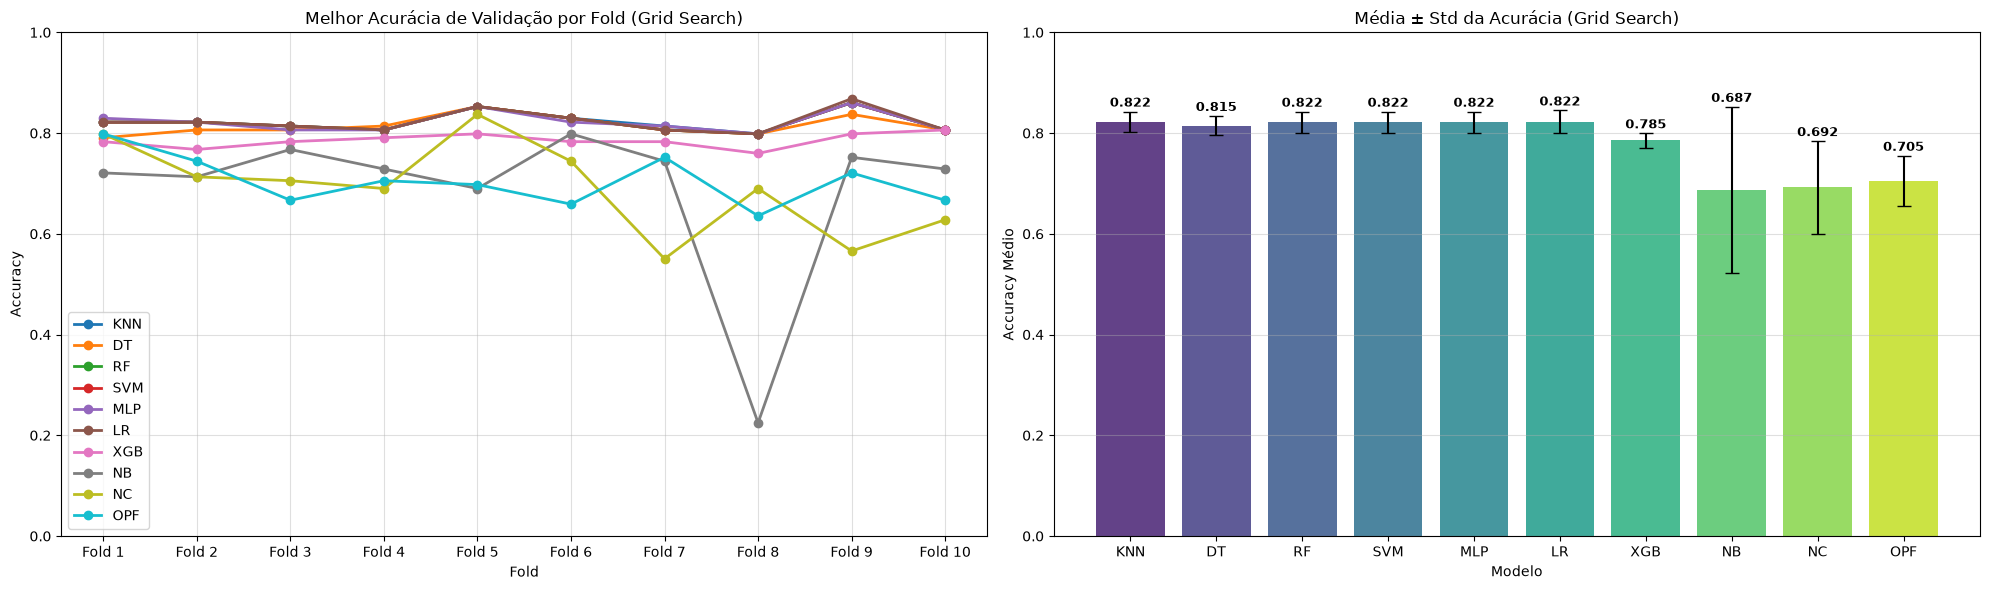

In [131]:
ranking_mdi = pd.concat(importancias_mdi_por_fold, axis=1).mean(axis=1)
ranking_mdi = ranking_mdi.sort_values(ascending=False)

frequencia_mdi = pd.Series(
    [feature for fold in features_mdi_por_fold for feature in fold]
).value_counts()

df_gs_acc = pd.DataFrame(gridsearch_results_acc, index=[f'Fold {i+1}' for i in range(len(gridsearch_results_acc['KNN']))])

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Linhas por fold
for model in df_gs_acc.columns:
    axes[0].plot(df_gs_acc.index, df_gs_acc[model], marker='o', label=model, linewidth=2)
axes[0].set_title('Melhor Acurácia de Validação por Fold (Grid Search)')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.4)
axes[0].set_ylim(0, 1)

# Barras com média ± std
means = df_gs_acc.mean()
stds = df_gs_acc.std()
bars = axes[1].bar(means.index, means.values, yerr=stds.values,
                   capsize=5, color=sns.color_palette("viridis", len(means)), alpha=0.85)
for bar, mean, std in zip(bars, means.values, stds.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01,
                 f'{mean:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Média ± Std da Acurácia (Grid Search)')
axes[1].set_xlabel('Modelo')
axes[1].set_ylabel('Accuracy Médio')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.show()


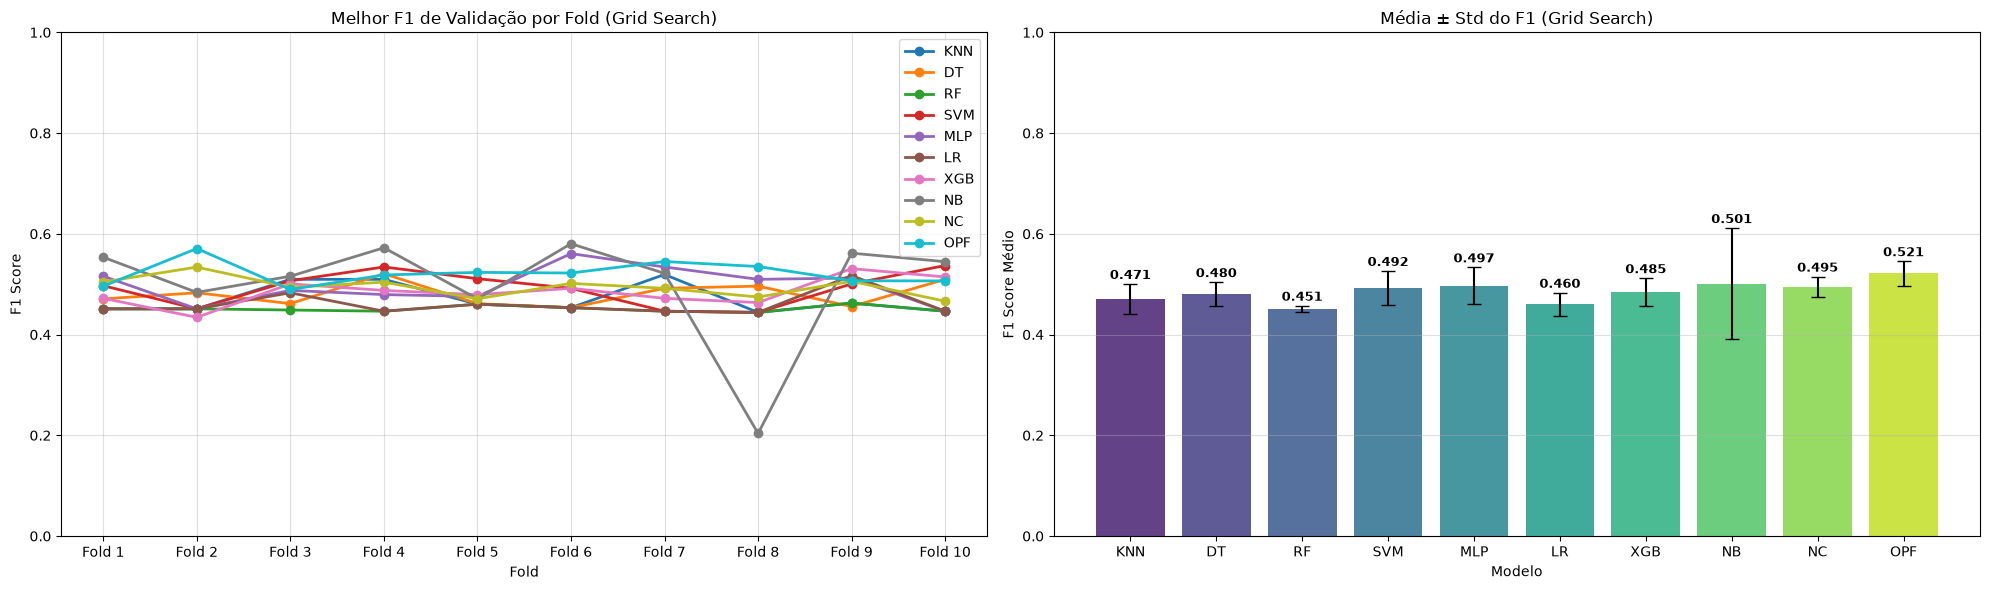

In [132]:
df_gs = pd.DataFrame(gridsearch_results_f1, index=[f'Fold {i+1}' for i in range(len(gridsearch_results_f1['KNN']))])

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Linhas por fold
for model in df_gs.columns:
    axes[0].plot(df_gs.index, df_gs[model], marker='o', label=model, linewidth=2)
axes[0].set_title('Melhor F1 de Validação por Fold (Grid Search)')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('F1 Score')
axes[0].legend()
axes[0].grid(True, alpha=0.4)
axes[0].set_ylim(0, 1)

# Barras com média ± std
means = df_gs.mean()
stds = df_gs.std()
bars = axes[1].bar(means.index, means.values, yerr=stds.values,
                   capsize=5, color=sns.color_palette("viridis", len(means)), alpha=0.85)
for bar, mean, std in zip(bars, means.values, stds.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01,
                 f'{mean:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Média ± Std do F1 (Grid Search)')
axes[1].set_xlabel('Modelo')
axes[1].set_ylabel('F1 Score Médio')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.show()


In [133]:
# for metric in ['f1', 'acc']:
#     df_gs = pd.DataFrame({m: gridsearch_results[m][metric] for m in gridsearch_results},
#                           index=[f'Fold {i+1}' for i in range(5)])

#     fig, axes = plt.subplots(1, 2, figsize=(20, 6))
#     title = 'F1 Score' if metric == 'f1' else 'Acurácia'

#     for model in df_gs.columns:
#         axes[0].plot(df_gs.index, df_gs[model], marker='o', label=model, linewidth=2)
#     axes[0].set_title(f'Melhor {title} de Validação por Fold (Grid Search)')
#     axes[0].set_xlabel('Fold')
#     axes[0].set_ylabel(title)
#     axes[0].legend()
#     axes[0].grid(True, alpha=0.4)
#     axes[0].set_ylim(0, 1)

#     means, stds = df_gs.mean(), df_gs.std()
#     bars = axes[1].bar(means.index, means.values, yerr=stds.values,
#                        capsize=5, color=sns.color_palette("viridis", len(means)), alpha=0.85)
#     for bar, mean, std in zip(bars, means.values, stds.values):
#         axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01,
#                      f'{mean:.3f}', ha='center', fontsize=9, fontweight='bold')
#     axes[1].set_title(f'Média ± Std da {title} (Grid Search)')
#     axes[1].set_xlabel('Modelo')
#     axes[1].set_ylabel(f'{title} Médio')
#     axes[1].set_ylim(0, 1)
#     axes[1].grid(True, alpha=0.4, axis='y')

#     plt.tight_layout()
#     plt.show()


In [134]:
# #Tabela vazia
# consenso_importancias = pd.DataFrame(index=X.columns)

# #Adiciona os valores do MDI
# #Computa final averages for MDI
# medias_finais_mdi = {}
# for modelo in resultados_mdi:
#     medias_finais_mdi[modelo] = np.mean(resultados_mdi[modelo], axis=0)

# #Tabela vazia
# consenso_importancias = pd.DataFrame(index=X.columns)

# #Adiciona os valores do MDI
# for nome_modelo, valores in medias_finais_mdi.items():
#     consenso_importancias[f'MDI_{nome_modelo}'] = valores

# tabela_de_ranks = consenso_importancias.rank()

# #Calcula a média global das posições
# consenso_importancias['Pontuação_Global'] = tabela_de_ranks.mean(axis=1)

# # Ordena da melhor para a pior
# consenso_ordenado = consenso_importancias.sort_values(by='Pontuação_Global', ascending=False)

# #Features ruins que devem ser deletadas
# qntd_lixo = 12 
# features_lixo = consenso_ordenado.index[-qntd_lixo:].tolist()

# print(f" AS {qntd_lixo} PIORES FEATURES")
# for i, f in enumerate(features_lixo):
#     print(f"{i+1}º pior: {f}")



In [135]:
# # 1. Pega as Top 15 posições do nosso Rank Global anterior
# top_15_features = consenso_ordenado.index[:15].tolist()

# # 2. Transforma o 'X' gigantesco em um 'X_fortalecido' que tem SÓ essas 15.
# X_fortalecido = X[top_15_features]

# print(f"Colunas ativas agora {X_fortalecido.shape}:")
# for feat in top_15_features:
#     print(f"- {feat}")

# # 3. Atualiza para a esteira do Loop pegar apenas desta nova base
# X = X_fortalecido.values
# y = y.values


In [136]:
# # 1. Recupera as informações
# importancias_rf = medias_finais_mdi['RF']

# # 2. Criação e Ordenação
# df_80 = pd.DataFrame({'Importância': importancias_rf}, index=X.columns)
# df_80 = df_80.sort_values(by='Importância', ascending=False)

# # 3. Fazendo a Soma em Cascata (Soma Cumulativa)
# df_80['Soma_Acumulada'] = df_80['Importância'].cumsum()

# # 4. Separando as campeãs (<= 80%)
# features_80_percent = df_80[df_80['Soma_Acumulada'] <= 0.80]

# #CRIAÇÃO DO GRÁFICO
# fig, ax1 = plt.subplots(figsize=(14, 6))

# # A. Desenha as Barras (Quanto de peso CADA feature tem)
# ax1.bar(
#     df_80.index, df_80['Importância'], 
#     color='royalblue', edgecolor='black', alpha=0.8
# )
# ax1.set_ylabel('Ganho de Importância Individual', color='navy')
# ax1.set_xticks(range(len(df_80.index)))
# ax1.set_xticklabels(df_80.index, rotation=90, fontsize=9)
# ax1.set_xlim(-0.5, len(df_80.index) - 0.5)

# ax2 = ax1.twinx()
# ax2.plot(
#     df_80.index, df_80['Soma_Acumulada'], 
#     color='red', marker='o', linewidth=2.5, markersize=5
# )
# ax2.set_ylabel('Soma Cumulativa (%)', color='darkred')
# ax2.set_ylim([0, 1.05]) # Vai de 0% até 105% no gráfico

# # C. Desenha as linhas guias do Corte de 80%
# ax2.axhline(y=0.80, color='green', linestyle=':', lw=3, label='Alvo: 80%')

# # D. Cortina vertical separando o "Joio do Trigo"
# index_corte = len(features_80_percent) - 1
# if index_corte >= 0:
#     ax1.axvline(x=index_corte + 0.5, color='gray', linestyle='--', lw=2)
#     ax1.text(index_corte + 0.8, ax1.get_ylim()[1]/2, '⬅ Zona dos 80% | Lixeira ➡', 
#              color='forestgreen', fontsize=12, fontweight='bold')

# plt.title('Análise de Corte das Features (Corte MDI de 80% - Random Forest)', fontsize=15)
# fig.tight_layout()
# plt.show()

# #  IMPRIME A LISTA DE OURO 
# print(" AS FEATURES DE OURO QUE COMPÕEM 80% DO SEU PROJETO ")
# for ft in features_80_percent.index:
#     print(f" -> {ft}")


In [137]:
print("\nRESULTADOS FINAIS - MÉDIA ± DESVIO PADRÃO")

algorithms = {
    'KNeighborsClassifier':  (acc_test_scores_KNN, f1_test_scores_KNN, precision_test_scores_KNN, recall_test_scores_KNN, auroc_test_scores_KNN),
    'DecisionTreeClassifier':(acc_test_scores_DT,  f1_test_scores_DT,  precision_test_scores_DT,  recall_test_scores_DT,  auroc_test_scores_DT),
    'RandomForestClassifier':(acc_test_scores_RF,  f1_test_scores_RF,  precision_test_scores_RF,  recall_test_scores_RF,  auroc_test_scores_RF),
    'SVM':                   (acc_test_scores_SVM, f1_test_scores_SVM, precision_test_scores_SVM, recall_test_scores_SVM, auroc_test_scores_SVM),
    'MLPClassifier':         (acc_test_scores_MLP, f1_test_scores_MLP, precision_test_scores_MLP, recall_test_scores_MLP, auroc_test_scores_MLP),
    'LogisticRegression':    (acc_test_scores_LR,  f1_test_scores_LR,  precision_test_scores_LR,  recall_test_scores_LR,  auroc_test_scores_LR),
    'XGBClassifier':         (acc_test_scores_XGB, f1_test_scores_XGB, precision_test_scores_XGB, recall_test_scores_XGB, auroc_test_scores_XGB),
    'GaussianNB':           (acc_test_scores_NB,  f1_test_scores_NB,  precision_test_scores_NB,  recall_test_scores_NB,  auroc_test_scores_NB),
    'NearestCentroid':      (acc_test_scores_NC,  f1_test_scores_NC,  precision_test_scores_NC,  recall_test_scores_NC,  auroc_test_scores_NC),
    'SupervisedOPF':        (acc_test_scores_OPF, f1_test_scores_OPF, precision_test_scores_OPF, recall_test_scores_OPF, auroc_test_scores_OPF)
}

for name, (acc, f1, precision, recall, auroc) in algorithms.items():
    print(f"\n{name}:")
    print(f"  Acurácia : {np.mean(acc):.4f} ± {np.std(acc):.4f}")
    print(f"  F1       : {np.mean(f1):.4f} ± {np.std(f1):.4f}")
    print(f"  Precision: {np.mean(precision):.4f} ± {np.std(precision):.4f}")
    print(f"  Recall   : {np.mean(recall):.4f} ± {np.std(recall):.4f}")
    print(f"  AUROC    : {np.mean(auroc):.4f} ± {np.std(auroc):.4f}")



RESULTADOS FINAIS - MÉDIA ± DESVIO PADRÃO

KNeighborsClassifier:
  Acurácia : 0.8152 ± 0.0398
  F1       : 0.7388 ± 0.0590
  Precision: 0.7022 ± 0.0837
  Recall   : 0.8152 ± 0.0398
  AUROC    : 0.5054 ± 0.0158

DecisionTreeClassifier:
  Acurácia : 0.7928 ± 0.0455
  F1       : 0.7430 ± 0.0564
  Precision: 0.7216 ± 0.0508
  Recall   : 0.7928 ± 0.0455
  AUROC    : 0.5187 ± 0.0199

RandomForestClassifier:
  Acurácia : 0.8166 ± 0.0447
  F1       : 0.7348 ± 0.0622
  Precision: 0.6688 ± 0.0726
  Recall   : 0.8166 ± 0.0447
  AUROC    : 0.5000 ± 0.0000

SVM:
  Acurácia : 0.7422 ± 0.0435
  F1       : 0.7173 ± 0.0572
  Precision: 0.6998 ± 0.0668
  Recall   : 0.7422 ± 0.0435
  AUROC    : 0.4934 ± 0.0551

MLPClassifier:
  Acurácia : 0.7856 ± 0.0666
  F1       : 0.7216 ± 0.0660
  Precision: 0.6746 ± 0.0848
  Recall   : 0.7856 ± 0.0666
  AUROC    : 0.4937 ± 0.0229

LogisticRegression:
  Acurácia : 0.8138 ± 0.0423
  F1       : 0.7334 ± 0.0609
  Precision: 0.6684 ± 0.0723
  Recall   : 0.8138 ± 0.0423


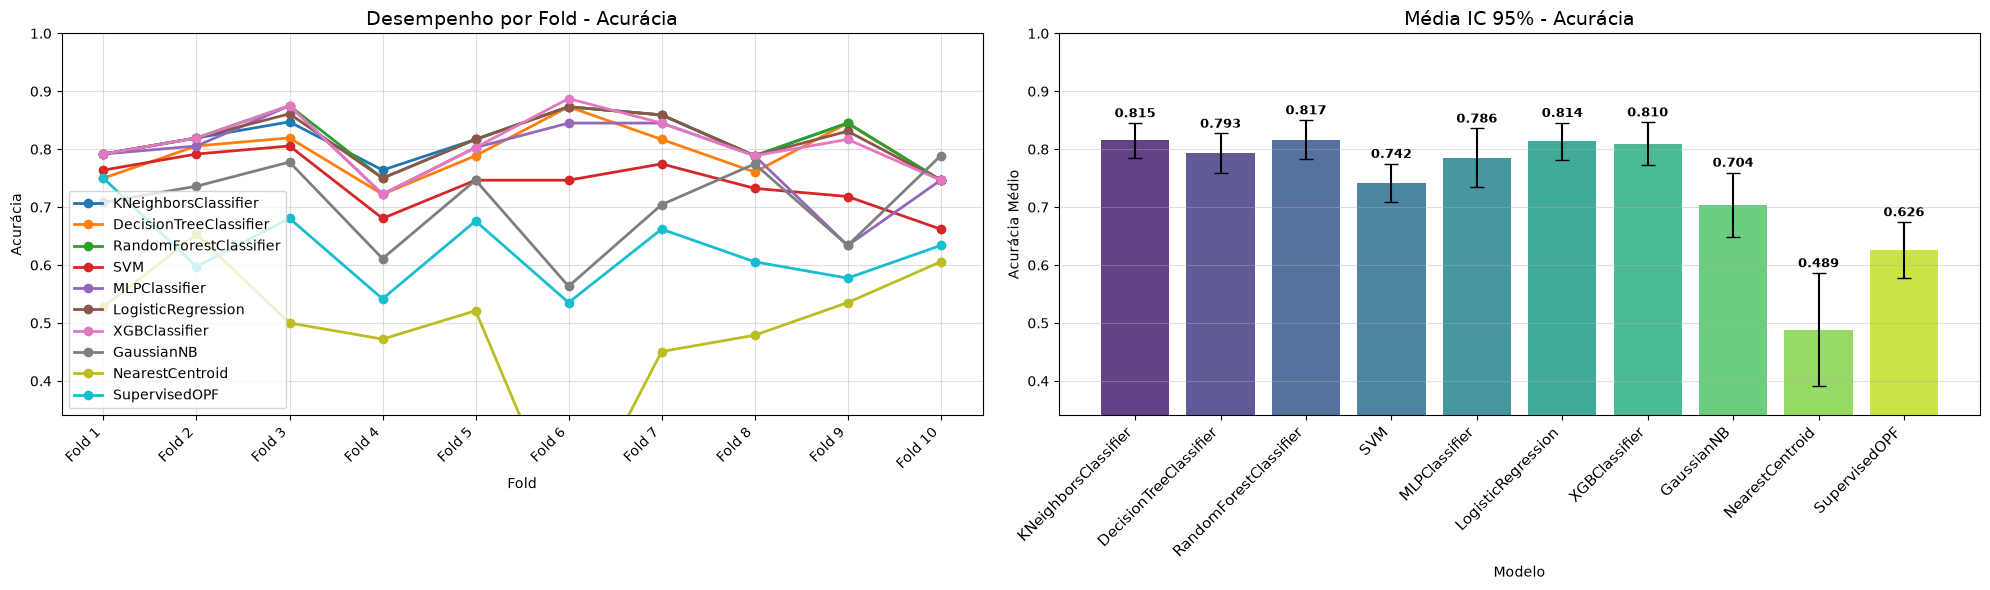

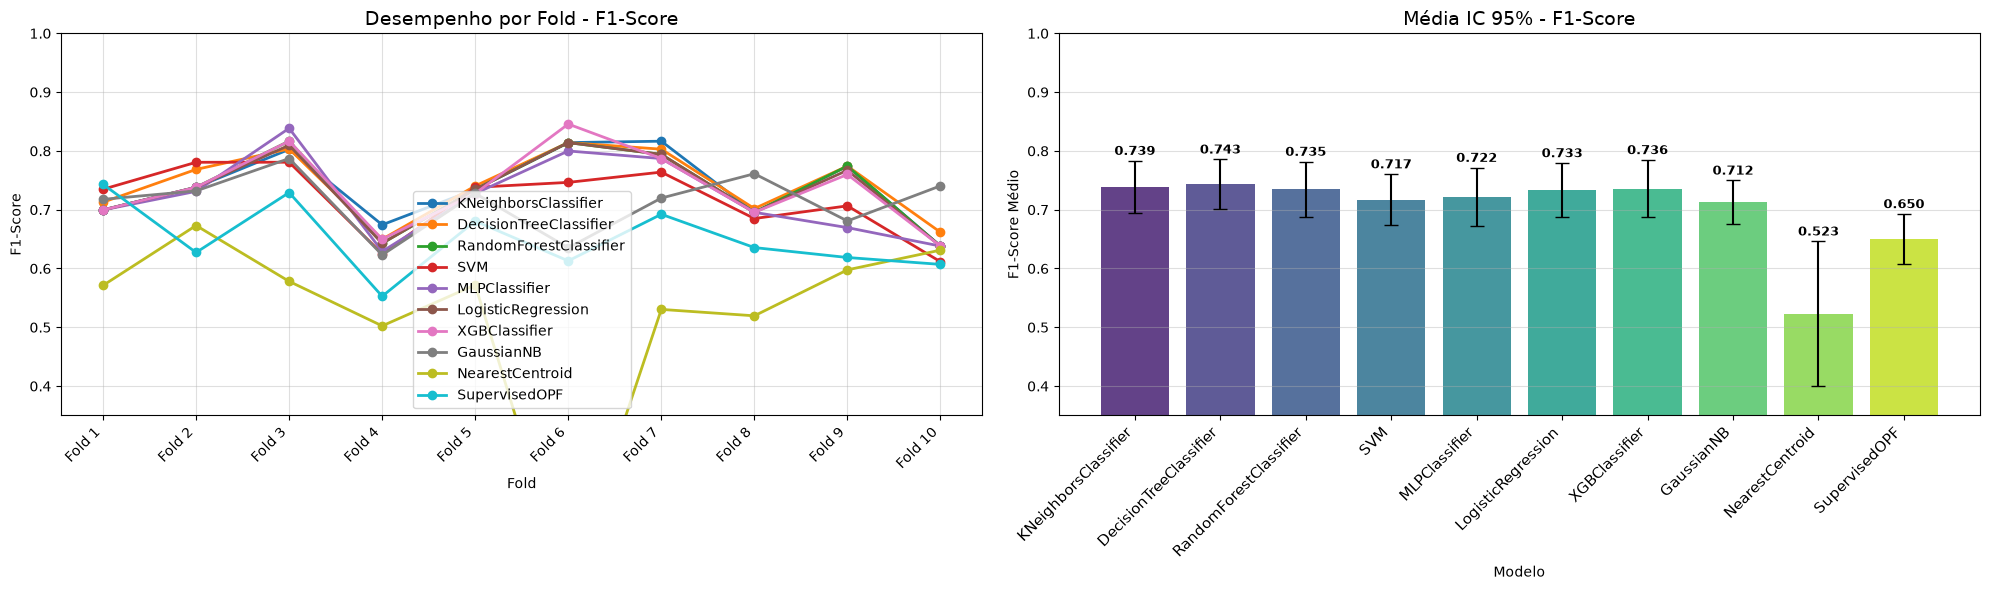

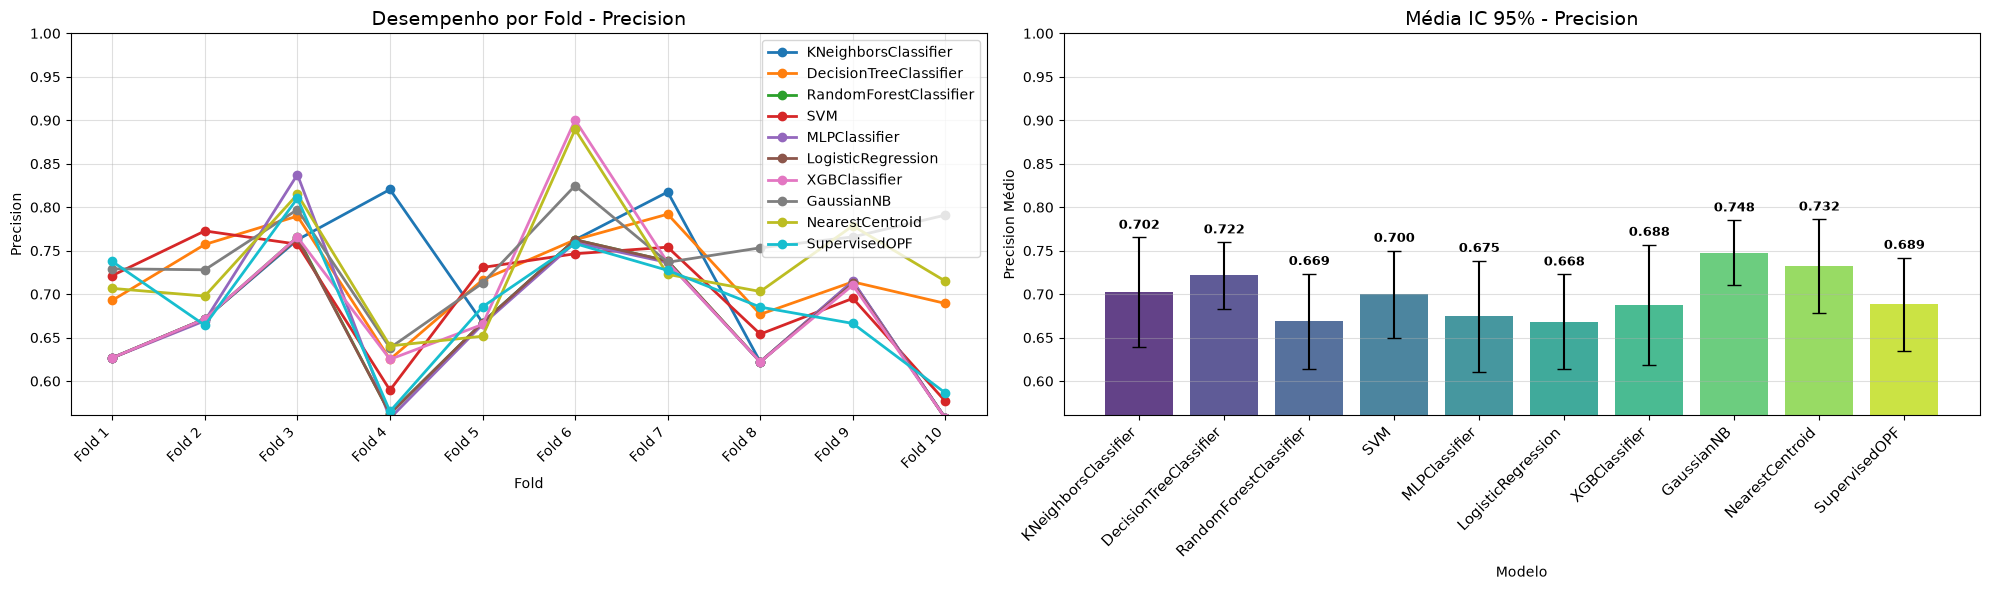

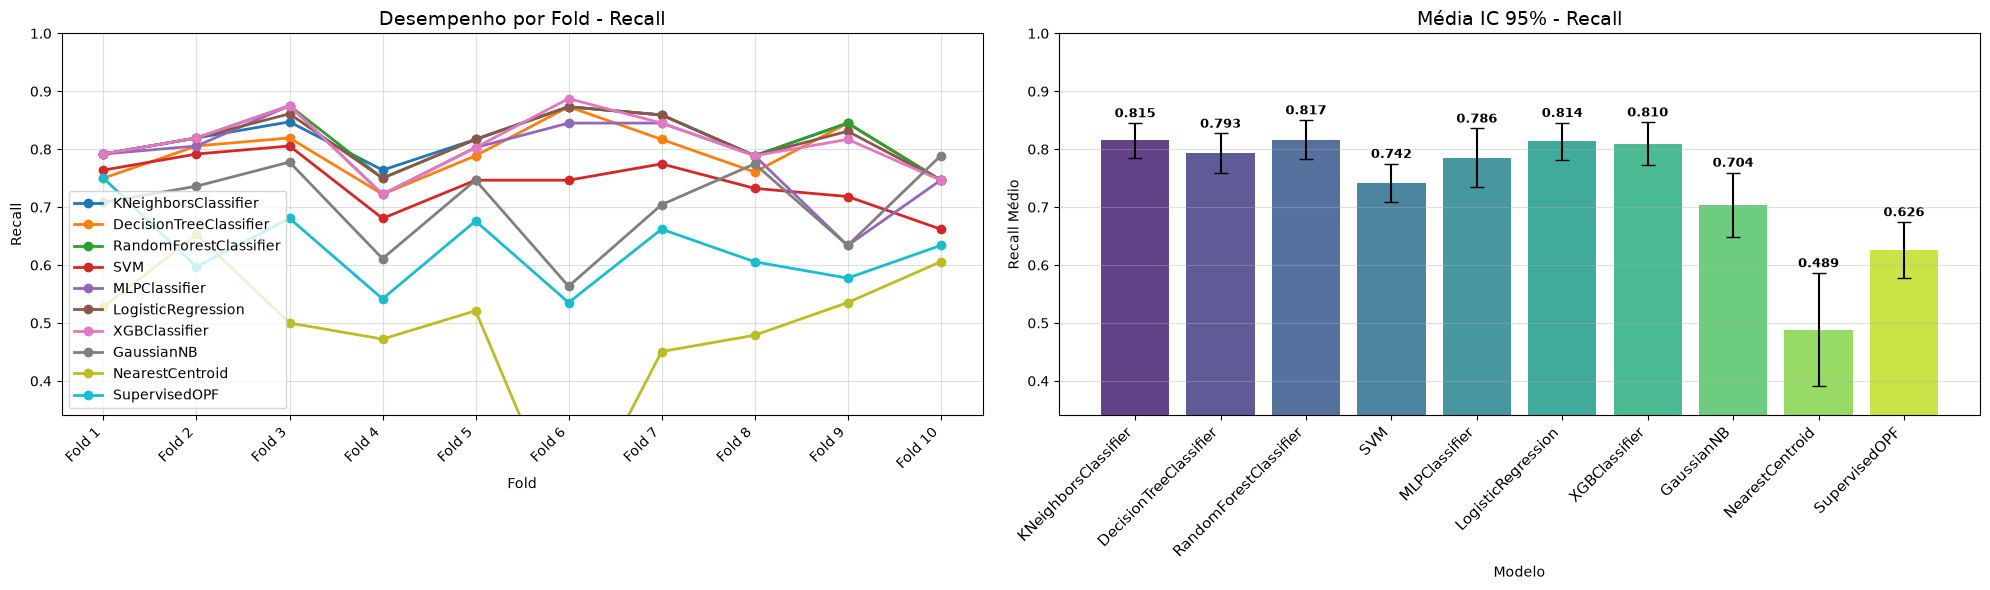

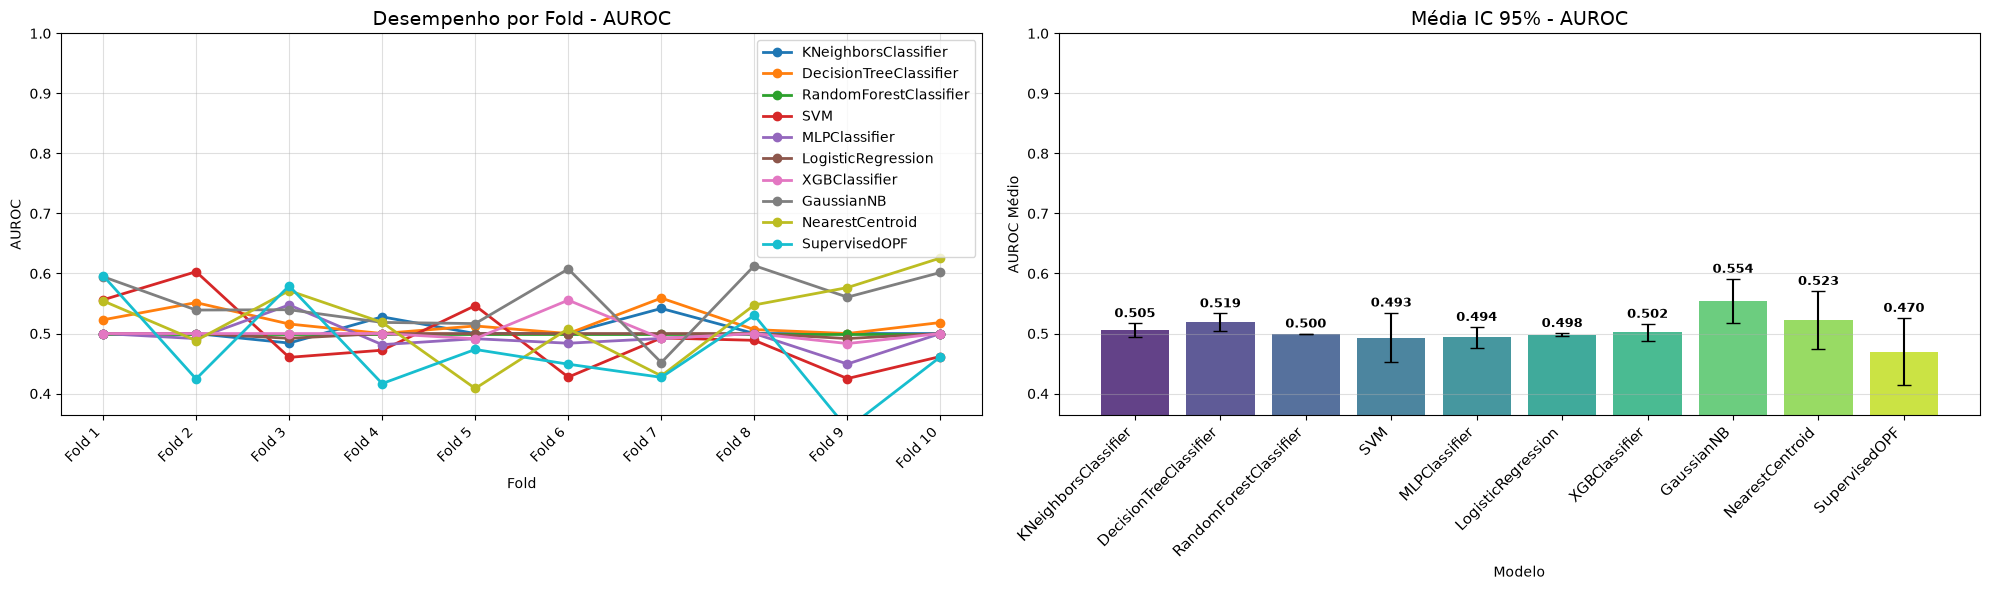

In [138]:
def get_confidence_interval(data, confidence=0.95):
    data = np.array(data)
    n = len(data)
    if n <= 1: return 0.0
    se = st.sem(data) 
    h = se * st.t.ppf((1 + confidence) / 2., n-1) 
    return h if not np.isnan(h) else 0.0
metric_names = ['Acurácia', 'F1-Score', 'Precision', 'Recall', 'AUROC']
model_names = list(algorithms.keys())
for i, metric in enumerate(metric_names):
    data_for_metric = {model: algorithms[model][i] for model in model_names}
    num_folds = len(list(data_for_metric.values())[0])
    df_metric = pd.DataFrame(data_for_metric, index=[f'Fold {j+1}' for j in range(num_folds)])
    
    limites_inferiores_ic = df_metric.mean() - df_metric.apply(lambda x: get_confidence_interval(x.dropna()))
    min_y_limit = limites_inferiores_ic.min() - 0.05
    min_y_limit = max(0, min_y_limit) 
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 6))
    
    for model in df_metric.columns:
        axes[0].plot(df_metric.index, df_metric[model], marker='o', label=model, linewidth=2)
        
    axes[0].set_title(f'Desempenho por Fold - {metric}', fontsize=14)
    axes[0].set_xlabel('Fold')
    axes[0].set_ylabel(metric)
    axes[0].legend()
    axes[0].grid(True, alpha=0.4)
    axes[0].set_ylim(min_y_limit, 1.0)
    
    axes[0].set_xticks(range(len(df_metric.index)))
    axes[0].set_xticklabels(df_metric.index, rotation=45, ha='right')
    
    means = df_metric.mean()
    cis = df_metric.apply(lambda x: get_confidence_interval(x.dropna()))
    
    bars = axes[1].bar(means.index, means.values, yerr=cis.values,
                       capsize=5, color=sns.color_palette("viridis", len(means)), alpha=0.85)
    
    for bar, mean, ci in zip(bars, means.values, cis.values):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + ci + 0.01,
                     f'{mean:.3f}', ha='center', fontsize=9, fontweight='bold')
        
    axes[1].set_title(f'Média IC 95% - {metric}', fontsize=14)
    axes[1].set_xlabel('Modelo')
    axes[1].set_ylabel(f'{metric} Médio')
    axes[1].grid(True, alpha=0.4, axis='y')
    axes[1].set_ylim(min_y_limit, 1.0)
    
    axes[1].set_xticks(range(len(means.index)))
    axes[1].set_xticklabels(means.index, rotation=45, ha='right', fontsize=11)
    
    plt.tight_layout()
    plt.show()

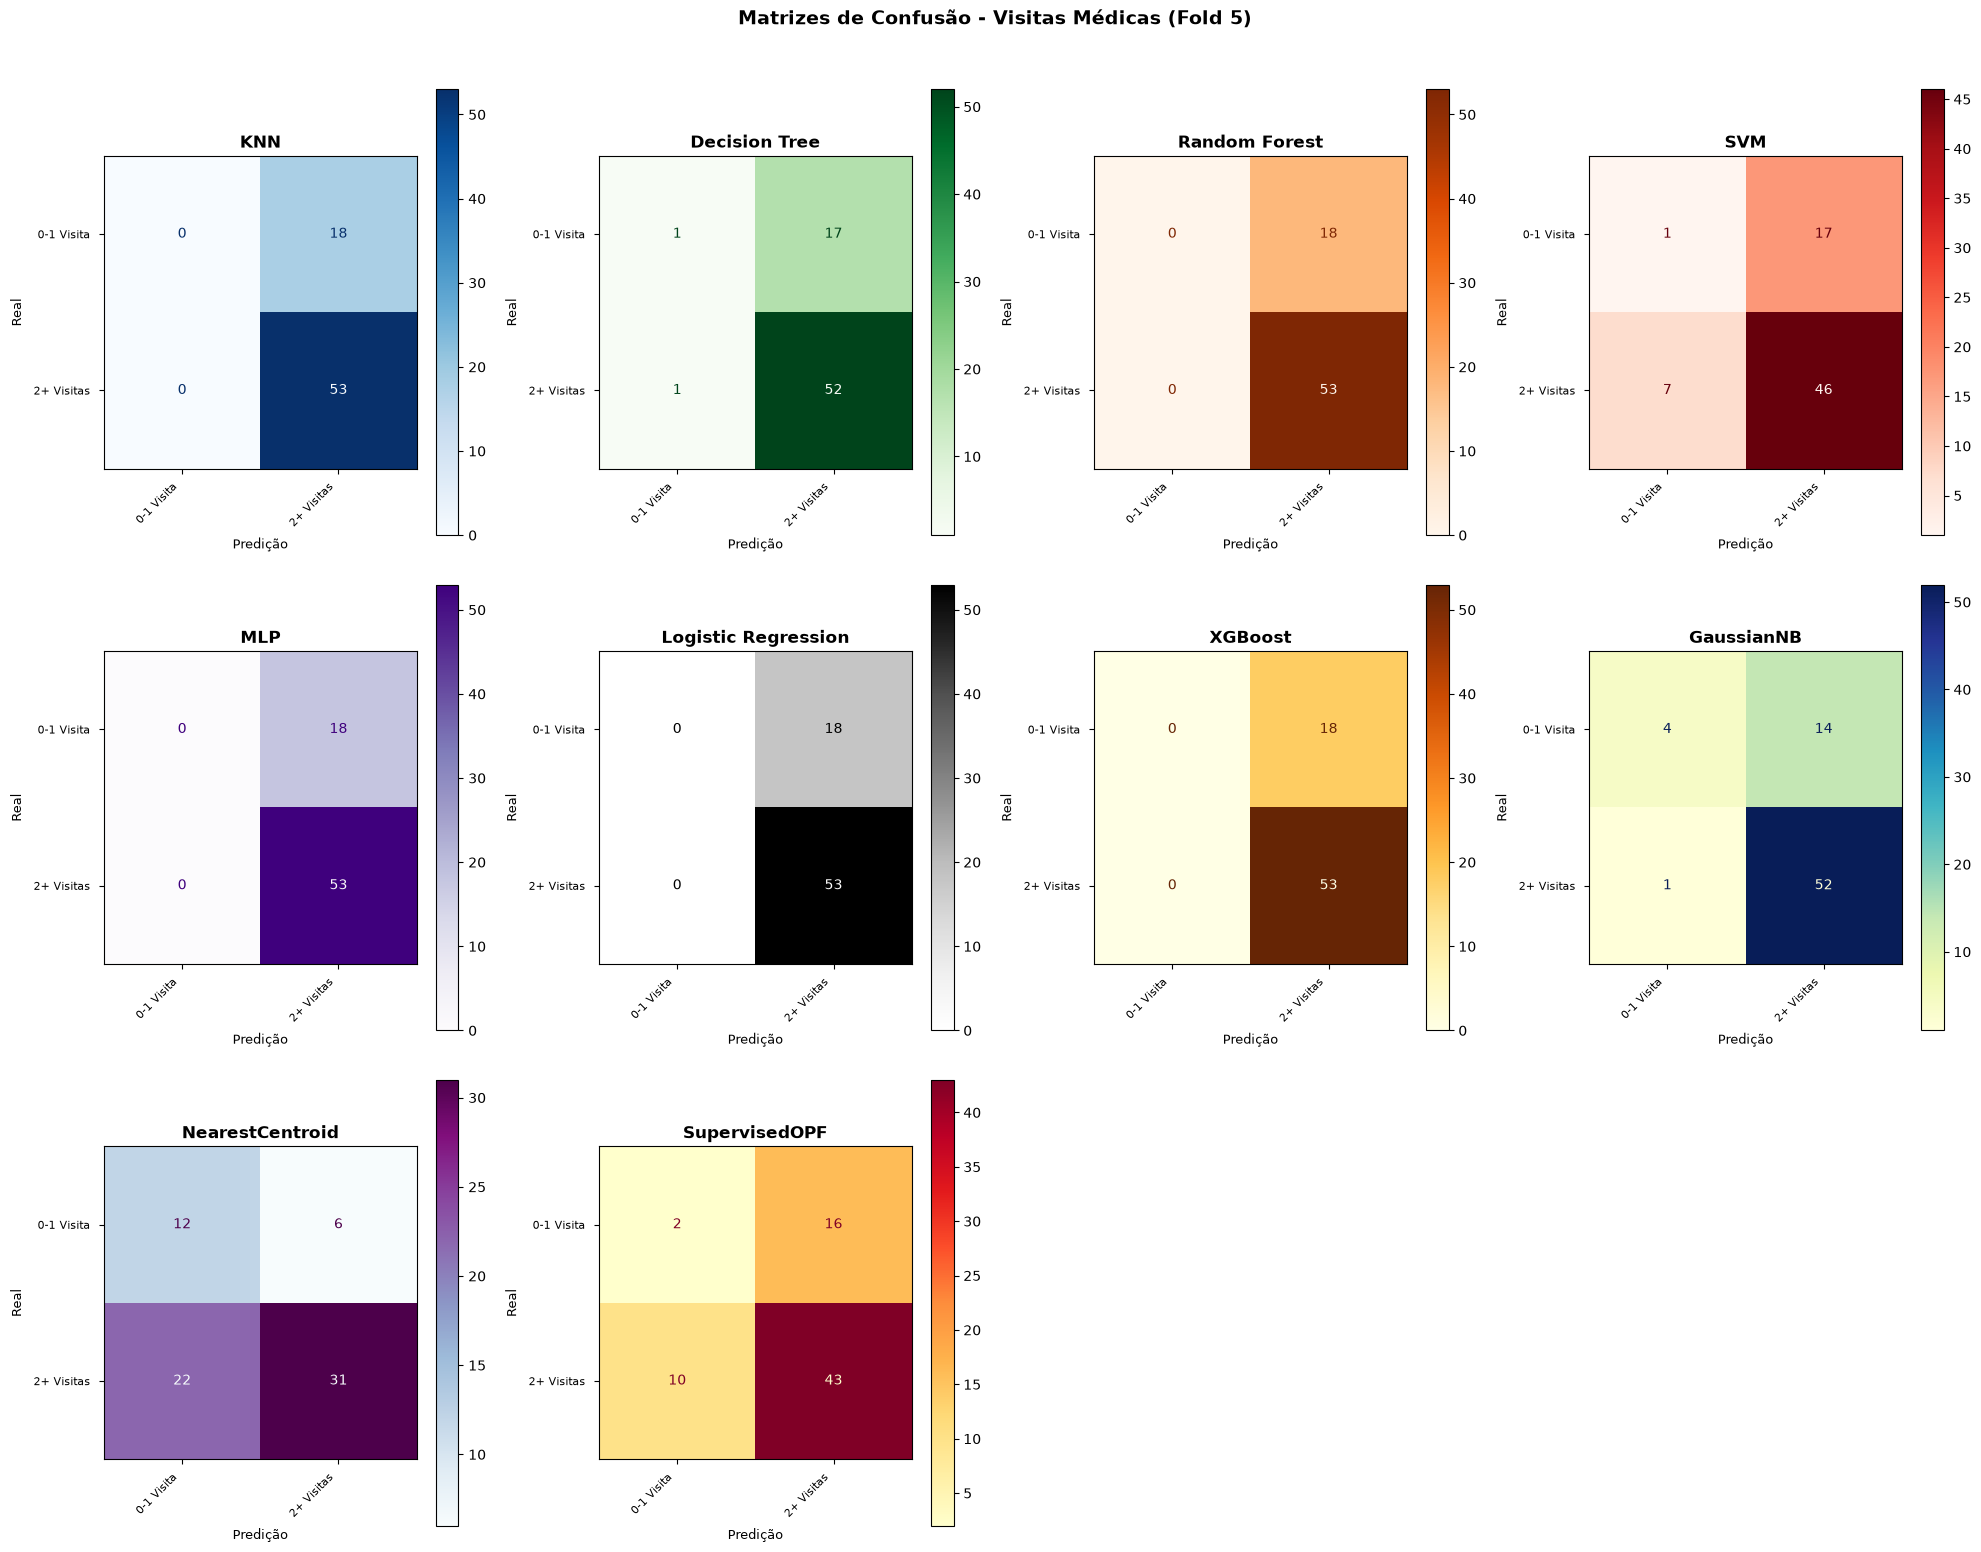

In [139]:
plt.figure(figsize=(20, 16))  # altura maior para 3 linhas
models = ['KNN', 'Decision Tree', 'Random Forest', 'SVM', 'MLP', 'Logistic Regression', 'XGBoost', 'GaussianNB', 'NearestCentroid', 'SupervisedOPF']
confusion_matrices = [cm_knn, cm_dt, cm_rf, cm_svm, cm_mlp, cm_lr, cm_xgb, cm_nb, cm_nc, cm_opf]
colors = ['Blues', 'Greens', 'Oranges', 'Reds', 'Purples', 'Greys', 'YlOrBr', 'YlGnBu', 'BuPu', 'YlOrRd']

class_labels = [' 0-1 Visita ', ' 2+ Visitas ']

for j, (model, cm, color) in enumerate(zip(models, confusion_matrices, colors)):
    plt.subplot(3, 4, j+1)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(cmap=color, ax=plt.gca(), values_format='d')

    plt.title(f'{model}', fontsize=12, fontweight='bold')
    plt.xlabel('Predição', fontsize=9)
    plt.ylabel('Real', fontsize=9)

    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(fontsize=8)

plt.suptitle(f'Matrizes de Confusão - Visitas Médicas (Fold {i+1})',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()


In [140]:
all_metrics_results = {
    'Acurácia': [
        ('KNeighborsClassifier', acc_test_scores_KNN),
        ('DecisionTreeClassifier', acc_test_scores_DT),
        ('RandomForestClassifier', acc_test_scores_RF),
        ('SVM', acc_test_scores_SVM),
        ('MLPClassifier', acc_test_scores_MLP),
        ('LogisticRegression', acc_test_scores_LR),
        ('XGBClassifier', acc_test_scores_XGB),
        ('GaussianNB', acc_test_scores_NB),
        ('NearestCentroid', acc_test_scores_NC),
        ('SupervisedOPF', acc_test_scores_OPF)
         
    ],
    'Precisão': [
        ('KNeighborsClassifier', precision_test_scores_KNN),
        ('DecisionTreeClassifier', precision_test_scores_DT),
        ('RandomForestClassifier', precision_test_scores_RF),
        ('SVM', precision_test_scores_SVM),
        ('MLPClassifier', precision_test_scores_MLP),
        ('LogisticRegression', precision_test_scores_LR),
        ('XGBClassifier', precision_test_scores_XGB),
        ('GaussianNB', precision_test_scores_NB),
        ('NearestCentroid', precision_test_scores_NC),
        ('SupervisedOPF', precision_test_scores_OPF)

    ],
    'Recall': [
        ('KNeighborsClassifier', recall_test_scores_KNN),
        ('DecisionTreeClassifier', recall_test_scores_DT),
        ('RandomForestClassifier', recall_test_scores_RF),
        ('SVM', recall_test_scores_SVM),
        ('MLPClassifier', recall_test_scores_MLP),
        ('LogisticRegression', recall_test_scores_LR),
        ('XGBClassifier', recall_test_scores_XGB),
        ('GaussianNB', recall_test_scores_NB),
        ('NearestCentroid', recall_test_scores_NC),
        ('SupervisedOPF', recall_test_scores_OPF)

    ],
    'F1-Score': [
        ('KNeighborsClassifier', f1_test_scores_KNN),
        ('DecisionTreeClassifier', f1_test_scores_DT),
        ('RandomForestClassifier', f1_test_scores_RF),
        ('SVM', f1_test_scores_SVM),
        ('MLPClassifier', f1_test_scores_MLP),
        ('LogisticRegression', f1_test_scores_LR),
        ('XGBClassifier', f1_test_scores_XGB),
        ('GaussianNB', f1_test_scores_NB),
        ('NearestCentroid', f1_test_scores_NC),
        ('SupervisedOPF', f1_test_scores_OPF)
    ],
    'AUROC': [
        ('KNeighborsClassifier', auroc_test_scores_KNN),
        ('DecisionTreeClassifier', auroc_test_scores_DT),
        ('RandomForestClassifier', auroc_test_scores_RF),
        ('SVM', auroc_test_scores_SVM),
        ('MLPClassifier', auroc_test_scores_MLP),
        ('LogisticRegression', auroc_test_scores_LR),
        ('XGBClassifier', auroc_test_scores_XGB),
        ('GaussianNB', auroc_test_scores_NB),
        ('NearestCentroid', auroc_test_scores_NC),
        ('SupervisedOPF', auroc_test_scores_OPF)
    ]
}

alpha = 0.05

for metric_name, model_scores_list in all_metrics_results.items():

    for i in range(len(model_scores_list)):
        for j in range(i + 1, len(model_scores_list)):
            model1_name, scores1 = model_scores_list[i]
            model2_name, scores2 = model_scores_list[j]

            print(f"\nComparando {model1_name} x {model2_name}:")

            if len(scores1) != len(scores2):
                print(f"\t- ERRO: Tamanhos das listas de scores são diferentes.")
                continue
            if len(scores1) < 2:
                print("\t- ERRO: Não há scores suficientes para o teste.")
                continue

            try:
                stat, p_val = wilcoxon(scores1, scores2, zero_method='zsplit', correction=False)
            except ValueError as e:
                print(f"\t- AVISO: Teste de Wilcoxon não pôde ser calculado. ({e})")
                mean1 = np.mean(scores1)
                mean2 = np.mean(scores2)
                print(f"\t- Média {model1_name}: {mean1:.4f}")
                print(f"\t- Média {model2_name}: {mean2:.4f}")
                print("\t-> Sem conclusão estatística.")
                print("----------------------------------------")
                continue

            mean1 = np.mean(scores1)
            mean2 = np.mean(scores2)

            print(f"\t- Amostras (n): {len(scores1)}")
            print(f"\t- Média {model1_name}: {mean1:.4f}")
            print(f"\t- Média {model2_name}: {mean2:.4f}")
            print(f"\t- Estatística Z: {stat:.4f}")
            print(f"\t- Valor-p (p-value): {p_val:.4f}")

            if p_val < alpha:
                print(f"\t-> Resultado: Diferença ESTATISTICAMENTE SIGNIFICATIVA (p < {alpha}).")
                best_model = model1_name if mean1 > mean2 else model2_name
                print(f"\t-> Melhor modelo (pela média): {best_model}")
            else:
                print(f"\t-> Resultado: Sem diferença estatisticamente significativa (p >= {alpha}).")

            print("----------------------------------------")


Comparando KNeighborsClassifier x DecisionTreeClassifier:
	- Amostras (n): 10
	- Média KNeighborsClassifier: 0.8152
	- Média DecisionTreeClassifier: 0.7928
	- Estatística Z: 3.0000
	- Valor-p (p-value): 0.0156
	-> Resultado: Diferença ESTATISTICAMENTE SIGNIFICATIVA (p < 0.05).
	-> Melhor modelo (pela média): KNeighborsClassifier
----------------------------------------

Comparando KNeighborsClassifier x RandomForestClassifier:
	- Amostras (n): 10
	- Média KNeighborsClassifier: 0.8152
	- Média RandomForestClassifier: 0.8166
	- Estatística Z: 27.0000
	- Valor-p (p-value): 1.0000
	-> Resultado: Sem diferença estatisticamente significativa (p >= 0.05).
----------------------------------------

Comparando KNeighborsClassifier x SVM:
	- Amostras (n): 10
	- Média KNeighborsClassifier: 0.8152
	- Média SVM: 0.7422
	- Estatística Z: 0.0000
	- Valor-p (p-value): 0.0020
	-> Resultado: Diferença ESTATISTICAMENTE SIGNIFICATIVA (p < 0.05).
	-> Melhor modelo (pela média): KNeighborsClassifier
-------